In [3]:
!pip install -q lpips
!pip install -q clean-fid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.4 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CocoCaptions
from torchvision import transforms
import torch.nn.functional as F

import tiktoken as tk
import matplotlib.pyplot as plt
import numpy as np
import time
import pprint
from tqdm import tqdm
from functools import partial
import random
import zipfile
import textwrap
import io
from PIL import Image

import lpips
import os
import shutil
from cleanfid import fid

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
def plot_training_results(train_losses, val_losses, eval_interval, title, y_title):
    plt.figure(figsize=(6, 4))

    # Map to real global steps
    steps = (np.arange(len(train_losses))) * eval_interval

    plt.plot(steps, train_losses, label='Train', alpha=0.5)
    plt.plot(steps, val_losses, label='Val')

    plt.title(title)
    plt.xlabel('Global Steps')
    plt.ylabel(y_title)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [7]:
def plot_generated_vs_original(model, loader, device, n=10):
    model.eval()
    originals = []
    reconstructed = []

    with torch.no_grad():
        for x, _ in loader:
            batch_needed = n - sum(t.shape[0] for t in originals)
            originals.append(x[:batch_needed])
            reconst, _, _, _ = model(x[:batch_needed].to(device))
            reconstructed.append(reconst.cpu())
            if sum(t.shape[0] for t in originals) >= n:
                break

    originals = torch.cat(originals, dim=0)
    reconstructed = torch.cat(reconstructed, dim=0)

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(torch.permute(originals[i], (1, 2, 0)))
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", loc="left", fontsize=10)

        axes[1, i].imshow(torch.permute(reconstructed[i], (1, 2, 0)))
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstructed", loc="left", fontsize=10)

    plt.tight_layout()
    plt.show()
    model.train()

# **COCO Dataset**

## **Dataset Loading**

In [ ]:
os.makedirs("dataset", exist_ok=True)

In [ ]:
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O /content/dataset/annotations_trainval2017.zip
!wget http://images.cocodataset.org/zips/val2017.zip -O /content/dataset/val2017.zip
!wget http://images.cocodataset.org/zips/train2017.zip -O /content/dataset/train2017.zip

--2026-05-08 06:16:26--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.232.169, 52.217.194.249, 16.15.253.213, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.232.169|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘/content/dataset/annotations_trainval2017.zip’

/content/dataset/an 100%[===================>] 241.19M  61.7MB/s    in 4.3s    

2026-05-08 06:16:31 (56.6 MB/s) - ‘/content/dataset/annotations_trainval2017.zip’ saved [252907541/252907541]

--2026-05-08 06:16:31--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.183.135, 16.15.252.73, 54.231.164.65, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.183.135|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [applica

In [ ]:
zip_path = "/content/dataset/annotations_trainval2017.zip"          # path to zip file
extract_path = "/content/dataset/annotations"    # folder to extract into

if not os.path.exists(extract_path):
  # create extraction folder if it doesn't exist
  os.makedirs(extract_path, exist_ok=True)

  # extract
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)

  print("Extraction completed!")
else:
  print(f"{extract_path} already exists!")

Extraction completed!


In [ ]:
zip_path = "/content/dataset/val2017.zip"          # path to zip file
extract_path = "/content/dataset/val2017"    # folder to extract into

if not os.path.exists(extract_path):
  # create extraction folder if it doesn't exist
  os.makedirs(extract_path, exist_ok=True)

  # extract
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)

  print("Extraction completed!")
else:
  print(f"{extract_path} already exists!")

Extraction completed!


In [ ]:
zip_path = "/content/dataset/train2017.zip"          # path to zip file
extract_path = "/content/dataset/train2017"    # folder to extract into

if not os.path.exists(extract_path):
  # create extraction folder if it doesn't exist
  os.makedirs(extract_path, exist_ok=True)

  # extract
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)

  print("Extraction completed!")
else:
  print(f"{extract_path} already exists!")

Extraction completed!


In [ ]:
transform = transforms.Compose([
    transforms.Resize(150),           # resize shorter edge to 150
    transforms.CenterCrop(128),       # crop to square
    transforms.ToTensor()
])

train_dataset_vqvae = CocoCaptions(
    root="/content/dataset/train2017/train2017",
    annFile="/content/dataset/annotations/annotations/captions_train2017.json",
    transform=transform
)

val_dataset_vqvae = CocoCaptions(
    root="/content/dataset/val2017/val2017",
    annFile="/content/dataset/annotations/annotations/captions_val2017.json",
    transform=transform
)

loading annotations into memory...
Done (t=0.96s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!


In [ ]:
print(f"Train size: {len(train_dataset_vqvae)}")
print(f"Validataion size: {len(val_dataset_vqvae)}")
print(f"Image shape: {val_dataset_vqvae[0][0].shape}")

Train size: 118287
Validataion size: 5000
Image shape: torch.Size([3, 128, 128])


In [ ]:
val_dataset_vqvae[0][0].max(), val_dataset_vqvae[0][0].min(), val_dataset_vqvae[0][0].unique().numel()

(tensor(0.7686), tensor(0.0902), 174)

In [ ]:
val_dataset_vqvae[0][1]

['A woman stands in the dining area at the table.',
 'A room with chairs, a table, and a woman in it.',
 'A woman standing in a kitchen by a window',
 'A person standing at a table in a room.',
 'A living area with a television and a table']

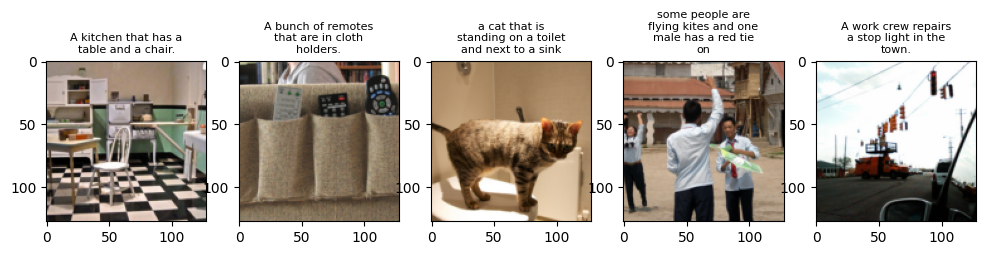

In [ ]:
np.random.seed(123)

random_indices = np.random.choice(len(val_dataset_vqvae), 5)

fig, axes = plt.subplots(1, 5, figsize=(12,6))

for i, ax in zip(random_indices, axes):
  img, caption = val_dataset_vqvae[int(i)]
  wrapped_caption = "\n".join(textwrap.wrap(caption[0], width=20))
  ax.imshow(img.permute(1,2,0))
  ax.set_title(f"{wrapped_caption}", fontsize=8)

plt.show()

In [ ]:
samples = torch.stack([val_dataset_vqvae[int(i)][0] for i in random_indices], dim=0)

## **Image Tokenizer (VQ-VAE)**

Following implementation downsamples and upsamples by factor of 4.

In [ ]:
class VQ(nn.Module):
  def __init__(self, latent_dim, k, normalize_codebook, decay=0.99): # k = number of discrete vectors or size of codebook
    super().__init__()
    self.k = k
    self.latent_dim = latent_dim
    self.normalize_codebook = normalize_codebook
    self.register_buffer("moving_sum", torch.zeros(k, latent_dim))
    self.register_buffer("moving_count", torch.zeros(k))
    self.register_buffer("codebook", torch.zeros(k, latent_dim))
    self.register_buffer("initialized", torch.tensor(False))
    self.register_buffer("decay", torch.tensor(decay))

  def forward(self, z_e, training):
    B, C, H, W = z_e.shape
    ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
    if not self.initialized:
      ze_flatten = ze_permute.reshape(-1, C)
      if ze_flatten.shape[0] < self.k:
        indices = torch.randint(0, ze_flatten.shape[0], (self.k,))
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)
      else:
        indices = torch.randperm(ze_flatten.shape[0])[:self.k]
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)

    if self.normalize_codebook:
      ze_norm = F.normalize(ze_permute, dim=-1)          # (B, H, W, C)
      codebook_norm = F.normalize(self.codebook, dim=-1) # (k, C)

      # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
      cross = ze_norm @ codebook_norm.T # (B, H, W, k)
      z_l2_sq = (ze_norm ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
      e_l2_sq = (codebook_norm ** 2).sum(dim=-1) # (k,)

      discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
      z_q = codebook_norm[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)
    else:
      # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
      cross = ze_permute @ self.codebook.T # (B, H, W, k)
      z_l2_sq = (ze_permute ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
      e_l2_sq = (self.codebook ** 2).sum(dim=-1) # (k,)

      discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
      z_q = self.codebook[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)

    # EMA codebook update
    if training:
      n_t = torch.zeros(self.k, device=z_e.device)
      codes_flatten = discrete_codes.reshape(-1)
      n_t.scatter_add_(0, codes_flatten, torch.ones(codes_flatten.shape, device=z_e.device)) # current code-wise utilization count
      self.moving_count.copy_(self.moving_count * self.decay + n_t * (1 - self.decay))
      ze_flatten = ze_permute.reshape(-1, C)
      current_code_sum = torch.zeros_like(self.moving_sum)
      # for i in range(self.k):
      #   assigned_indices = torch.where(codes_flatten == i)[0]
      #   if assigned_indices.shape[0] > 0:
      #     assigned_ze = ze_flatten[assigned_indices]
      #     m_i = assigned_ze.sum(0)
      #     current_code_sum[i] = m_i
      current_code_sum.scatter_add_(0, codes_flatten.unsqueeze(-1).expand(-1, C), ze_flatten)
      self.moving_sum.copy_(self.moving_sum * self.decay + current_code_sum * (1 - self.decay))
      safe_count = self.moving_count.unsqueeze(-1).clamp(min=1e-6)
      self.codebook.data.copy_(self.moving_sum / safe_count)
      if self.normalize_codebook:
        self.codebook.data.copy_(F.normalize(self.codebook.data, dim=-1))

    return z_q, discrete_codes

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 1),
        )

    def forward(self, x):
        return x + self.block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, hidden, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 4, stride=2, padding=1),
            nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),
            ResidualBlock(hidden),
            ResidualBlock(hidden),
            nn.Conv2d(hidden, latent_dim, 1),  # project to codebook dim
        )

    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_dim, hidden, 1),  # project back from codebook dim
            ResidualBlock(hidden),
            ResidualBlock(hidden),
            nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),
            nn.ConvTranspose2d(hidden, out_channels, 4, stride=2, padding=1),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class VQVAE(nn.Module):
  def __init__(self, in_channels, out_channels, latent_dim, hidden, k, normalize_codebook, decay=0.99):
    super().__init__()
    self.encoder = Encoder(in_channels, hidden, latent_dim)
    self.decoder = Decoder(latent_dim, hidden, out_channels)
    self.vq_layer = VQ(latent_dim, k, normalize_codebook, decay=decay)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x, training=False):
    z_e = self.encoder(x)
    z_q, discrete_codes = self.vq_layer(z_e, training)
    decoder_inp = z_e + (z_q - z_e).detach() # straight through estimator, the effective value for the forward pass is z_q only but the gradients flow to z_e
    reconst = self.sigmoid(self.decoder(decoder_inp))

    return reconst, z_e, z_q, discrete_codes

### Training

In [ ]:
def calc_batch_loss(model, x, device, training, percep_loss_fn, lambda_=0.1, beta=0.25):
  x = x.to(device)
  reconst, z_e, z_q, discrete_codes = model(x, training)
  x_scaled = x * 2 - 1
  reconst_scaled = reconst * 2 - 1
  percep_loss = lambda_ * percep_loss_fn(x_scaled, reconst_scaled).mean()
  l_1 = nn.functional.binary_cross_entropy(reconst, x)
  ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
  zq_permute = torch.permute(z_q, (0, 2, 3, 1)) # (B, H, W, C)
  l_3 = (beta * torch.norm(ze_permute - zq_permute.detach(), dim=-1) ** 2).mean()
  loss = l_1 + l_3 + percep_loss

  return loss, l_1, l_3, percep_loss, discrete_codes

In [ ]:
def evaluate(loader, model, device, percep_loss_fn, max_batch, k, lambda_=0.1):
  total_loss = 0
  total_l1_loss, total_l3_loss, total_percep_loss = 0, 0, 0
  all_codes = []
  if max_batch is None:
    max_batch = len(loader)
  elif max_batch <= 0:
    return float("nan")
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        loss, l_1, l_3, percep_loss, discrete_codes = calc_batch_loss(model, x, device, training=False, percep_loss_fn=percep_loss_fn, lambda_=lambda_)
      total_loss += loss.item()
      total_l1_loss += l_1.item()
      total_l3_loss += l_3.item()
      total_percep_loss += percep_loss.item()
      all_codes.append(discrete_codes.reshape(-1))
    else:
      break
  all_codes = torch.cat(all_codes, dim=0)

  return total_loss/max_batch, total_l1_loss/max_batch, total_l3_loss/max_batch, total_percep_loss/max_batch, all_codes.unique().numel() / k

In [ ]:
def reconstruct(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      reconst, _, _, _ = model(x, training=False)
    return reconst.cpu()

In [ ]:
def train_vqvae(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    percep_loss_fn,
    lambda_=0.1,
    epochs=20,
    eval_interval=500,
    k=512,
    samples=None
):
    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    global_step = -1

    # logs
    train_losses, val_losses = [], []
    train_l1_losses, val_l1_losses = [], []
    train_l3_losses, val_l3_losses = [], []
    train_percep_losses, val_percep_losses = [], []
    train_codebook, val_codebook = [], []

    t_start = time.time()
    model.train()

    for epoch in range(epochs):
        for x, _ in train_loader:
            optimizer.zero_grad()

            loss, _, _, _, _ = calc_batch_loss(
                model, x, device, training=True, percep_loss_fn=percep_loss_fn, lambda_=lambda_
            )
            loss.backward()
            optimizer.step()

            global_step += 1

            if global_step % eval_interval == 0:
                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done
                eta_minutes = (elapsed / steps_done) * steps_left / 60

                model.eval()

                train_loss, train_l1, train_l3, train_percep_loss, train_cu = evaluate(
                    train_loader, model, device, percep_loss_fn, max_batch=20, k=k, lambda_=lambda_
                )
                val_loss, val_l1, val_l3, val_percep_loss, val_cu = evaluate(
                    val_loader, model, device, percep_loss_fn, max_batch=None, k=k, lambda_=lambda_
                )

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3={train_l3:.4f}, percep_loss={train_percep_loss:.4f})")
                print(f"\tCodebook: {train_cu:.2f}")
                print(f"\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3={val_l3:.4f}, percep_loss={val_percep_loss:.4f})")
                print(f"\tCodebook: {val_cu:.2f}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

                # store logs
                train_losses.append(train_loss)
                val_losses.append(val_loss)

                train_l1_losses.append(train_l1)
                val_l1_losses.append(val_l1)

                train_l3_losses.append(train_l3)
                val_l3_losses.append(val_l3)

                train_percep_losses.append(train_percep_loss)
                val_percep_losses.append(val_percep_loss)

                train_codebook.append(train_cu)
                val_codebook.append(val_cu)

                # reconstruction viz
                if samples is not None:
                    reconst = reconstruct(model, samples, device)

                    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
                    for i in range(5):
                        axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                        axes[0, i].axis("off")

                        axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                        axes[1, i].axis("off")

                    plt.tight_layout()
                    plt.show()

                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_l1": train_l1_losses,
        "val_l1": val_l1_losses,
        "train_l3": train_l3_losses,
        "val_l3": val_l3_losses,
        "train_percep_loss": train_percep_losses,
        "val_percep_loss": val_percep_losses,
        "train_codebook": train_codebook,
        "val_codebook": val_codebook
    }

In [ ]:
def collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    captions = [random.choice(item[1]) for item in batch]  # just a list of strings
    return images, captions

In [ ]:
train_loader_vqvae = DataLoader(
    train_dataset_vqvae,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader_vqvae = DataLoader(
    val_dataset_vqvae,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
len(train_loader_vqvae), len(val_loader_vqvae)

(7393, 313)

In [ ]:
for imgs, caps in val_loader_vqvae:
  print(imgs.shape)
  print(caps)
  break

torch.Size([16, 3, 128, 128])
['A woman standing in a kitchen by a window', 'Closeup of a brown bear sitting in a grassy area.', 'a bed room with a neatly made bed a window and a book shelf', 'An upside down stop sign by the road.', 'Three stuffed animals are sitting on a bed. ', 'A woman in a red jacket skiing down a slope', 'A kitchen with a refrigerator, stove and oven with cabinets.', 'A couple of baseball player standing on a field.', 'a male tennis player in white shorts is playing tennis', 'A group of people that are standing near a tennis net.', 'A girl is taking a picture of people fishing.', 'The Asian girl is holding her Miss Kitty phone', 'Several children on a small  indoor kiddie train.', 'A sandwich with a bite taken on a plate.', 'A man with a wet suit on standing on a surfboard in the water.', 'A laptop and desktop computer on a white desk']


In [ ]:
torch.manual_seed(123)

lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()
model1 = VQVAE(in_channels=3, out_channels=3, latent_dim=8, hidden=128, k=512, normalize_codebook=False).to(device)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-4)

logs1 = train_vqvae(
    model=model1,
    train_loader=train_loader_vqvae,
    val_loader=val_loader_vqvae,
    optimizer=optimizer1,
    device=device,
    percep_loss_fn=lpips_model,
    lambda_=1,
    epochs=2,
    eval_interval=500,
    k=512,
    samples=samples
)

In [ ]:
torch.save(model1.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen.pt")

In [ ]:
plot_training_results(logs1["train_loss"], logs1["val_loss"], 500, title="Training Progress", y_title="Total Loss")

In [ ]:
plot_training_results(logs1["train_l1"], logs1["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

In [ ]:
plot_training_results(logs1["train_l3"], logs1["val_l3"], 500, title="Training Progress", y_title="Commitment Loss")

In [ ]:
plot_training_results(logs1["train_percep_loss"], logs1["val_percep_loss"], 500, title="Training Progress", y_title="Perceptual Loss")

In [ ]:
plot_training_results(logs1["train_codebook"], logs1["val_codebook"], 500, title="Training Progress", y_title="Codebook Utilization")

In [ ]:
vqvae = VQVAE(in_channels=3, out_channels=3, latent_dim=8, hidden=128, k=512, normalize_codebook=False)
vqvae.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen.pt"))
vqvae.to(device)

# plot_generated_vs_original(vqvae, val_loader_vqvae, device=device)

VQVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (2): ResidualBlock(
        (block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (3): ResidualBlock(
        (block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (4): Conv2d(128, 8, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Conv2d(8, 128, kernel_size=(1, 1), stride=(1, 1))
      (1): ResidualBlock(
        (block): Sequential(
          (0): ReLU()
    

## **Prior Training**

In [ ]:
enc = tk.get_encoding("gpt2")

tokenizer = tk.Encoding(
    name="gpt2_custom",
    pat_str=enc._pat_str,
    mergeable_ranks=enc._mergeable_ranks,
    special_tokens={
        **enc._special_tokens,
        "<|startoftext|>": enc.max_token_value + 1,  # new unique ID
        "<|pad|>": enc.max_token_value + 2,  # new unique ID
        "<|startofimage|>": enc.max_token_value + 3  # new unique ID
    }
)

In [ ]:
tokenizer.special_tokens_set

{'<|endoftext|>', '<|pad|>', '<|startofimage|>', '<|startoftext|>'}

In [ ]:
PAD_ID = tokenizer._special_tokens["<|pad|>"]
SOI_ID = tokenizer._special_tokens["<|startofimage|>"]
BOS_ID = tokenizer._special_tokens["<|startoftext|>"]

In [ ]:
class TokenizedTextImageDataset(Dataset):
  def __init__(self, model, tokenizer, loader, device):
    self.tokenized_images = []
    self.tokenized_text = []
    model.to(device)
    for x, y in tqdm(loader, desc="Generating codes"):
      x = x.to(device)
      B = x.shape[0]
      with torch.no_grad():
        z_e = model.encoder(x)
        z_q, discrete_codes = model.vq_layer(z_e, training=False)
      discrete_codes = discrete_codes.reshape(B, -1).cpu()
      self.tokenized_images.extend(discrete_codes.tolist())
      for caption in y:
        tokens = tokenizer.encode(caption.lower())
        self.tokenized_text.append(tokens)

  def __len__(self):
    return len(self.tokenized_images)

  def __getitem__(self, idx):
    return self.tokenized_images[idx], self.tokenized_text[idx]

In [ ]:
train_dataset_prior = TokenizedTextImageDataset(vqvae, tokenizer, train_loader_vqvae, device)
val_dataset_prior = TokenizedTextImageDataset(vqvae, tokenizer, val_loader_vqvae, device)

In [ ]:
torch.save({
    "tokenized_images": train_dataset_prior.tokenized_images,
    "tokenized_text": train_dataset_prior.tokenized_text
}, "/content/drive/My Drive/GenAI/Data/train_dataset_prior.pt")

torch.save({
    "tokenized_images": val_dataset_prior.tokenized_images,
    "tokenized_text": val_dataset_prior.tokenized_text
}, "/content/drive/My Drive/GenAI/Data/val_dataset_prior.pt")

In [ ]:
class LoadTokenizedTextImageDataset(Dataset):
    def __init__(self, tokenized_images, tokenized_text):
        self.tokenized_images = tokenized_images
        self.tokenized_text = tokenized_text

    def __len__(self):
        return len(self.tokenized_images)

    def __getitem__(self, idx):
        return self.tokenized_images[idx], self.tokenized_text[idx]

In [ ]:
train_data = torch.load("/content/drive/My Drive/GenAI/Data/train_dataset_prior.pt")

train_dataset_prior = LoadTokenizedTextImageDataset(
    train_data["tokenized_images"],
    train_data["tokenized_text"]
)

val_data = torch.load("/content/drive/My Drive/GenAI/Data/val_dataset_prior.pt")

val_dataset_prior = LoadTokenizedTextImageDataset(
    val_data["tokenized_images"],
    val_data["tokenized_text"]
)

In [ ]:
def collator(batch, text_vocab_size, max_text_tokens, sot_id=50257, pad_id=50258, soi_id=50259):
  input_text_tokens = []
  input_image_tokens = []
  target_text_tokens = []
  target_image_tokens = []
  for img_tokens, text_tokens in batch:
    text_tokens = [sot_id] + text_tokens
    if len(text_tokens) > max_text_tokens:
      new_text_tokens = text_tokens[:max_text_tokens]
    else:
      new_text_tokens = text_tokens + [pad_id] * (max_text_tokens - len(text_tokens))
    img_tokens = [text_vocab_size+img_code for img_code in img_tokens]
    new_image_tokens = [soi_id] + img_tokens

    input_text_tokens.append(new_text_tokens)
    input_image_tokens.append(new_image_tokens[:-1])

    target_text_tokens.append(new_text_tokens[1:] + [new_image_tokens[0]])
    target_image_tokens.append(new_image_tokens[1:])


  input_text_tokens = torch.tensor(input_text_tokens)
  input_image_tokens = torch.tensor(input_image_tokens)
  target_text_tokens = torch.tensor(target_text_tokens)
  target_image_tokens = torch.tensor(target_image_tokens)
  inputs = {"text_tokens": input_text_tokens, "image_tokens": input_image_tokens}
  targets = {"text_tokens": target_text_tokens, "image_tokens": target_image_tokens}

  return inputs, targets

### Transformer

In [ ]:
PRIOR_CONFIG = {
    'emb_size':768,
    'context_length':64, # trying context length of 64 instead of 256
    'text_vocab_size':tokenizer.n_vocab,
    "codebook_size": 512,
    'num_heads':12,
    'num_layers':12,
    'drop_rate':0.1,
    'grid_size': (32, 32),
    'row_extension': 33, # for 32 x 32 grid, the row extension of 33 will allow to attend the same column from prev row
    'kernel_size': 11,
    'cfg_drop': 0.1,
    'qkv_bias': False,
}

PRIOR_CONFIG["total_vocab_size"] = PRIOR_CONFIG["text_vocab_size"] + PRIOR_CONFIG["codebook_size"]

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, mask_type, grid_size, row_extension, kernel_size, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        self._create_mask(
            mask_type,
            context_length,
            grid_size=grid_size,
            row_extension=row_extension,
            kernel_size=kernel_size,
    ))

  def _create_mask(
      self,
      mask_type,
      text_len,
      grid_size=(32, 32),
      row_extension=33,
      kernel_size=11,
      use_soi=True,
  ):
      H, W = grid_size
      image_len = H * W
      soi_tokens = 1 if use_soi else 0
      total_len = text_len + soi_tokens + image_len
      mask = torch.zeros(
          (total_len, total_len),
          dtype=torch.bool
      )
      # =========================================================
      # TEXT TOKENS
      # Standard causal mask
      # =========================================================
      for i in range(text_len):
          mask[i, : i + 1] = True
      # =========================================================
      # SOI TOKEN
      # =========================================================
      if use_soi:
          soi_idx = text_len
          # SOI attends to all previous text tokens
          mask[soi_idx, : text_len + 1] = True
          image_offset = text_len + 1
      else:
          soi_idx = None
          image_offset = text_len
      # =========================================================
      # IMAGE TOKENS
      # =========================================================
      for img_idx in range(image_len):
          q = image_offset + img_idx
          # -----------------------------------------------------
          # image tokens attend to all text tokens
          # -----------------------------------------------------
          mask[q, :text_len] = True
          # -----------------------------------------------------
          # attend to SOI token
          # -----------------------------------------------------
          if use_soi:
              mask[q, soi_idx] = True
          row = img_idx // W
          col = img_idx % W
          # =====================================================
          # ROW ATTENTION
          # =====================================================
          if mask_type == "row":
              start = max(0, img_idx - row_extension)
              for prev in range(start, img_idx + 1):
                  mask[q, image_offset + prev] = True
          # =====================================================
          # COLUMN ATTENTION
          # =====================================================
          elif mask_type == "column":
              for prev in range(img_idx + 1):
                  prev_row = prev // W
                  prev_col = prev % W
                  same_col = (prev_col == col)
                  within_extent = (
                      row - prev_row
                  ) <= row_extension
                  if same_col and within_extent:
                      mask[q, image_offset + prev] = True
          # =====================================================
          # CONVOLUTION ATTENTION
          # WITH WRAPAROUND BEHAVIOR
          # =====================================================
          elif mask_type == "convolution":
              radius = kernel_size // 2
              for prev in range(img_idx + 1):
                  prev_row = prev // W
                  prev_col = prev % W
                  dr = row - prev_row
                  # horizontal wraparound distance
                  dc = min(
                      abs(col - prev_col),
                      W - abs(col - prev_col)
                  )
                  inside_kernel = (
                      abs(dr) <= radius
                      and dc <= radius
                  )
                  if inside_kernel:
                      mask[q, image_offset + prev] = True
          else:
              raise ValueError(
                  f"Unknown mask type: {mask_type}"
              )
      return ~mask

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    attention_scores = queries @ keys.transpose(2,3)
    attention_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self, emb_size):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_size))
    self.shift = nn.Parameter(torch.zeros(emb_size))

  def forward(self, x):
    mean = x.mean(keepdim=True, dim=-1)
    variance = x.var(keepdim=True, dim=-1, unbiased=False)
    norm_x = (x - mean)/torch.sqrt(variance + self.eps)
    return self.scale * norm_x + self.shift

In [ ]:
class GeLU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
    ))

In [ ]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_size'], 4 * cfg['emb_size']),
        GeLU(),
        nn.Linear(4 * cfg['emb_size'], cfg['emb_size'])
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg, mask_type):
    super().__init__()
    self.mha = MultiHeadAttention(cfg['emb_size'], cfg['emb_size'], cfg['context_length'], cfg['drop_rate'], cfg['num_heads'], mask_type, cfg['grid_size'], cfg['row_extension'], cfg['kernel_size'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.ffn = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [ ]:
class Prior(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['total_vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.null_emb_layer = nn.Embedding(1, cfg['emb_size'])
    self.row_emb_layer = nn.Embedding(cfg['grid_size'][0], cfg['emb_size'])
    self.col_emb_layer = nn.Embedding(cfg['grid_size'][1] + 1, cfg['emb_size']) # the 0th col_emb is for startofimage token only and not for any of the image tokens belonging to the zeroth column in 2d view
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg, self._mask_type(i, cfg['num_layers'])) for i in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['total_vocab_size'], bias=False)
    self.num_rows = cfg['grid_size'][0]
    self.num_cols = cfg['grid_size'][1]
    self.context_length = cfg['context_length']
    self.cfg_drop = cfg['cfg_drop']

  def _mask_type(self, i, num_layers):
    if i==num_layers-1:
      return 'convolution'
    elif (i-1)%4==0:
      return 'column'
    else:
      return 'row'

  def forward(self, input, training=False):
    text_tokens = input.get('text_tokens', None) # text_tokens will be None for unconditional inference
    image_tokens = input.get('image_tokens', None) # soi token belongs to image_tokens seq
    batch_size, num_img_tokens = image_tokens.shape
    null_emb = self.null_emb_layer(torch.tensor(0).to(image_tokens.device))
    if text_tokens is None: # during unconditional inference
      text_token_emb = null_emb.unsqueeze(0).unsqueeze(0).expand(batch_size, self.context_length, -1)
    else:
      text_token_emb = self.token_emb_layer(text_tokens)
    _, num_text_tokens, _ = text_token_emb.shape
    pos_emb = self.pos_emb_layer(
        torch.arange(num_text_tokens, device=image_tokens.device)
    )
    if training:
      drop_ind = torch.rand(batch_size) < self.cfg_drop
      text_token_emb[drop_ind] = null_emb.unsqueeze(0).expand(num_text_tokens, -1)
    text_emb = text_token_emb + pos_emb
    image_token_emb = self.token_emb_layer(image_tokens)
    # row_emb = self.row_emb_layer(
    #     torch.arange((num_img_tokens-1)//self.num_rows, device=image_tokens.device)
    # )
    # cols_to_use = min(num_img_tokens-1, self.num_cols) + 1 # for +1 for soi token
    # col_emb = self.col_emb_layer(
    #     torch.arange(cols_to_use, device=image_tokens.device)
    # )
    # image_token_emb[0] = image_token_emb[0] + row_emb[0] + col_emb[0] # soi separately
    # row_emb_repeat = torch.repeat_interleave(row_emb, self.num_cols, dim=0)[:num_img_tokens-1] # excluded soi since it is already done
    # col_emb_repeat = torch.tile(col_emb[1:], ((num_img_tokens-1) // (cols_to_use - 1) + 1,))[:num_img_tokens-1] # excluded soi since it is already done
    # image_token_emb[1:] = image_token_emb[1:] + row_emb_repeat + col_emb_repeat
    # for each image token (excluding SOI), compute which row it belongs to
    image_token_emb[:,0] = image_token_emb[:,0] + self.row_emb_layer(torch.tensor(0, device=image_tokens.device)) + self.col_emb_layer(torch.tensor(0, device=image_tokens.device)) # soi separately
    img_indices = torch.arange(num_img_tokens - 1, device=image_tokens.device)
    row_indices = img_indices // self.num_cols   # shape (num_img_tokens-1,)
    col_indices = img_indices % self.num_cols    # shape (num_img_tokens-1,)
    row_emb = self.row_emb_layer(row_indices)   # (num_img_tokens-1, emb_size)
    col_emb = self.col_emb_layer(col_indices + 1)  # +1 to skip the SOI col slot
    image_token_emb[:,1:] = image_token_emb[:,1:] + row_emb + col_emb
    x = torch.cat((text_emb, image_token_emb), dim=1)
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits

### Training

In [ ]:
def ce_batch_loss_calc(input_batch, target_batch, model, device, cfg, training=False):
  input_batch = {k:v.to(device) for k,v in input_batch.items()}
  target_batch = {k:v.to(device) for k,v in target_batch.items()}
  logits_batch = model(input_batch, training=training)
  # loss_text = torch.nn.functional.cross_entropy(logits_batch[:, :cfg['context_length'], :].flatten(0, 1), target_batch['text_tokens'].flatten()) / cfg['context_length'] # dividing to normalize wrt text token occurence
  # loss_image = torch.nn.functional.cross_entropy(logits_batch[:, cfg['context_length']:, :].flatten(0, 1), target_batch['image_tokens'].flatten()) / (cfg['grid_size'][0] * cfg['grid_size'][1]) # dividing to normalize wrt image token occurence
  # correct implementation
  loss_text = torch.nn.functional.cross_entropy(logits_batch[:, :cfg['context_length'], :].flatten(0, 1), target_batch['text_tokens'].flatten(), ignore_index=PAD_ID, reduction='mean')
  loss_image = torch.nn.functional.cross_entropy(logits_batch[:, cfg['context_length']:, :].flatten(0, 1), target_batch['image_tokens'].flatten(), reduction='mean')
  loss = 0.125 * loss_text + 0.875 * loss_image

  return loss

In [ ]:
def calc_loss_dataloader(loader, model, device, cfg, num_batches=None):
  total_loss = 0
  if len(loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(loader)
  elif num_batches < 0:
    num_batches = float('nan')
  else:
    num_batches = min(num_batches, len(loader))

  for i, (x, y) in enumerate(loader):
    if i < num_batches:
      loss = ce_batch_loss_calc(x, y, model, device, cfg, training=False)
      total_loss += loss.item()
    else:
      break

  return total_loss/num_batches

In [ ]:
def evaluate_prior(model, train_loader, val_loader, device, cfg, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_dataloader(train_loader, model, device, cfg, eval_iter)
    val_loss = calc_loss_dataloader(val_loader, model, device, cfg, eval_iter)
  model.train()

  return train_loss, val_loss

In [ ]:
def generate(model, tokenizer, inputs, max_gen_tokens, cfg_weight, temperature=0.0, top_k=None, eos_id=None): # cfg_weight -> classifier-free guidance
  B, N = inputs['text_tokens'].shape
  finished = torch.zeros(B, dtype=torch.bool, device=inputs['text_tokens'].device)
  for i in range(max_gen_tokens):
    with torch.no_grad():
      cond_inp = inputs
      logits_c = model(cond_inp, training=False)[:, -1, :]

      uncond_inp = {'text_tokens': None, 'image_tokens': inputs['image_tokens']}
      logits_u = model(uncond_inp, training=False)[:, -1, :]
    logits = logits_u + cfg_weight * (logits_c - logits_u) # classifier free guidance for boosting logits for tokens which are caption or condition relevant

    logits[:,:tokenizer.n_vocab] = torch.tensor(float('-inf'), device=logits.device) # +1 is for soi AND this line ensures that only image tokens are generated

    if top_k is not None:
      top_logits, top_idx = torch.topk(logits, top_k)
      logits = torch.where(
          condition=logits<top_logits[:,-1, None],
          input=torch.tensor(float('-inf'), device=logits.device),
          other=logits
      )

    if temperature > 0:
      scaled_logits = logits / temperature
      probs = torch.softmax(scaled_logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)

    if eos_id is not None:
        finished |= (idx_next.squeeze(-1) == eos_id)
        idx_next[finished] = eos_id

    inputs['image_tokens'] = torch.cat((inputs['image_tokens'], idx_next), dim=1)

    if finished.all():
        break

  return inputs['image_tokens']

In [ ]:
def reconstruct_from_prior(vqvae, img_tokens, device):
  vqvae.eval()
  with torch.no_grad():
    img_tokens = img_tokens.to(device) # (B, H, W)
    codebook_latents = vqvae.vq_layer.codebook[img_tokens].permute(0, 3, 1, 2) # (B, emb_dim, H, W)
    reconst = vqvae.sigmoid(vqvae.decoder(codebook_latents))
  return reconst

In [ ]:
def tokenize_text(text, tokenizer, max_text_tokens):
  tokens = tokenizer.encode(text.lower())
  tokens = [BOS_ID] + tokens
  if len(tokens) > max_text_tokens:
    new_tokens = tokens[:max_text_tokens]
  else:
    new_tokens = tokens + [PAD_ID] * (max_text_tokens - len(tokens))
  return new_tokens

In [ ]:
def generate_and_render_sample(model, vqvae, tokenizer, cfg, cfg_weight, text_prompts, device, temperature=0.7):
  model.eval()
  input_text_tokens = []
  for text in text_prompts:
    text_tokens = tokenize_text(text, tokenizer, cfg['context_length'])
    input_text_tokens.append(text_tokens)
  input_image_tokens = [[SOI_ID] for i in range(len(text_prompts))]
  inputs = {
      'text_tokens': torch.tensor(input_text_tokens, device=device),
      'image_tokens': torch.tensor(input_image_tokens, device=device)
  }
  with torch.no_grad():
    op_tokens = generate(
        model,
        inputs=inputs,
        tokenizer=tokenizer,
        max_gen_tokens=1024,
        cfg_weight=cfg_weight,
        temperature=temperature,
        top_k=25
    )
  img_tokens = op_tokens[:,1:].reshape(-1, cfg['grid_size'][0], cfg['grid_size'][1]) # remove soi token and reshape to 32 * 32 grid expected by vqvae decoder
  img_tokens = img_tokens - tokenizer.n_vocab # to get back original image codes
  reconst = reconstruct_from_prior(vqvae, img_tokens, device).cpu()

  fig, axes = plt.subplots(1, len(text_prompts), figsize=(16, 6))
  for i in range(len(text_prompts)):
    axes[i].imshow(torch.permute(reconst[i], (1, 2, 0)))
    axes[i].axis("off")
  plt.tight_layout()
  plt.show()

In [ ]:
import time

def train_model_simple(
    model,
    vqvae,
    cfg,
    train_loader,
    val_loader,
    device,
    optimizer,
    tokenizer,
    epochs,
    eval_freq,
    eval_iter,
    text_prompts,
    cfg_weight
):
    train_loss_arr, val_loss_arr, track_tokens_seen, grad_norms_arr = [], [], [], []
    global_step, tokens_seen = -1, 0

    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    t_start = time.time()

    for epoch in range(epochs):
        model.train()

        for x, y in train_loader:
            optimizer.zero_grad()

            train_loss = ce_batch_loss_calc(
                x, y, model, device, cfg, training=True
            )

            train_loss.backward()

            # global grad norm
            total_norm = 0.0

            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.detach().data.norm(2)
                    total_norm += param_norm.item() ** 2

            total_norm = total_norm ** 0.5
            grad_norms_arr.append(total_norm)

            optimizer.step()

            tokens_seen += (
                x['text_tokens'].numel()
                + x['image_tokens'].numel()
            )

            global_step += 1

            if global_step % eval_freq == 0:

                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done

                eta_minutes = (
                    (elapsed / steps_done) * steps_left
                ) / 60

                train_loss, val_loss = evaluate_prior(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    cfg,
                    eval_iter
                )

                train_loss_arr.append(train_loss)
                val_loss_arr.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f}")
                print(f"\tVal Loss:   {val_loss:.4f}")
                print(f"\tTokens Seen: {tokens_seen}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

            if global_step % (eval_freq * 50) == 0: # if eval_freq=100 then generation will happen every 5000 steps
                generate_and_render_sample(
                    model,
                    vqvae,
                    tokenizer,
                    cfg,
                    cfg_weight,
                    text_prompts,
                    device
                )
                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return train_loss_arr, val_loss_arr, track_tokens_seen, grad_norms_arr

In [ ]:
prior_collate_fn = partial(collator, text_vocab_size=tokenizer.n_vocab, max_text_tokens=PRIOR_CONFIG['context_length'])

train_loader_prior = DataLoader(train_dataset_prior, batch_size=4, shuffle=True, num_workers=0, collate_fn=prior_collate_fn)
val_loader_prior = DataLoader(val_dataset_prior, batch_size=4, shuffle=False, num_workers=0, collate_fn=prior_collate_fn)

In [ ]:
torch.manual_seed(123)
model2 = Prior(PRIOR_CONFIG)
model2.to(device)
optimizer2 = torch.optim.AdamW(model2.parameters(), lr=0.0004, weight_decay=0.1)
text_prompts = [
                  'A kitchen that has a table and a chair.',
                  'A bunch of remotes that are in cloth holders.'
                  # 'a cat that is standing on a toilet and next to a sink'
                  # 'some people are flying kites and one male has a red tie on',
                  # 'a work crew repairs a stop in the town.'
                ]
train_losses2, val_losses2, tokens_seen2, grad_norms_arr2 = train_model_simple(model2, vqvae, PRIOR_CONFIG, train_loader_prior, val_loader_prior, device, optimizer2, tokenizer, epochs=1, eval_freq=100, eval_iter=5, text_prompts=text_prompts, cfg_weight=4)

In [ ]:
torch.save(model2.state_dict(), '/content/drive/My Drive/GenAI/Data/text_to_image_prior_model.pt')

In [ ]:
plot_training_results(train_losses2, val_losses2, 100, title="Training Progress", y_title="Loss")

# **Flickr8k - EXP 1**

## **Dataset Loading**

In [ ]:
zip_path = "/content/drive/My Drive/Flickr8k.zip"          # path to zip file
extract_path = "/content/drive/My Drive/Flickr8k"    # folder to extract into

if not os.path.exists(extract_path):
  # create extraction folder if it doesn't exist
  os.makedirs(extract_path, exist_ok=True)

  # extract
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)

  print("Extraction completed!")
else:
  print(f"{extract_path} already exists!")

Extraction completed!


In [ ]:
class Flickr8kDataset(Dataset):
    def __init__(self, image_dir, captions_file, split=0.8, mode="train", transform=None):
        self.transform = transform
        self.image_caption_map = {}

        with open(captions_file, 'r') as f:
            for i, line in enumerate(f):
                if i == 0:
                    continue
                line = line.strip()
                img, caption = line.split(',', 1)
                caption = caption.strip().strip('"')
                if img not in self.image_caption_map:
                    self.image_caption_map[img] = caption

        image_files = list(self.image_caption_map.keys())

        np.random.seed(42)
        np.random.shuffle(image_files)

        split_idx = int(len(image_files) * split)
        if mode == "train":
            image_files = image_files[:split_idx]
        elif mode == "val":
            image_files = image_files[split_idx:]
        else:
            raise ValueError("mode must be 'train' or 'val'")

        # load all images into RAM at init time
        print(f"Caching {len(image_files)} images into RAM...")
        self.samples = []
        for img_name in tqdm(image_files):
            img_path = os.path.join(image_dir, img_name)
            with open(img_path, 'rb') as f:
                img_bytes = f.read()
            caption = self.image_caption_map[img_name]
            self.samples.append((img_bytes, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_bytes, caption = self.samples[idx]
        image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, caption

In [ ]:
transform = transforms.Compose([
    transforms.Resize(150),           # resize shorter edge to 150
    transforms.CenterCrop(128),       # crop to square
    transforms.ToTensor(),
])

train_dataset_vqvae_2 = Flickr8kDataset(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="train",
    transform=transform
)

val_dataset_vqvae_2 = Flickr8kDataset(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="val",
    transform=transform
)

Caching 6472 images into RAM...


100%|██████████| 6472/6472 [00:15<00:00, 426.73it/s]


Caching 1619 images into RAM...


100%|██████████| 1619/1619 [00:03<00:00, 480.80it/s]


In [ ]:
len(train_dataset_vqvae_2), len(val_dataset_vqvae_2)

(6472, 1619)

In [ ]:
train_dataset_vqvae_2[0][0].shape

torch.Size([3, 128, 128])

In [ ]:
train_dataset_vqvae_2[0][0].min(), train_dataset_vqvae_2[0][0].max(), train_dataset_vqvae_2[0][0].unique().numel()

(tensor(0.0039), tensor(0.9569), 244)

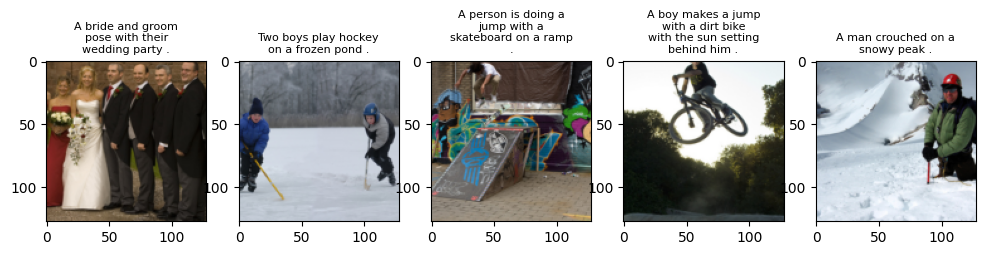

In [ ]:
np.random.seed(123)

random_indices = np.random.choice(len(val_dataset_vqvae_2), 5)

fig, axes = plt.subplots(1, 5, figsize=(12,6))

for i, ax in zip(random_indices, axes):
  img, caption = val_dataset_vqvae_2[i]
  wrapped_caption = "\n".join(textwrap.wrap(caption, width=20))
  ax.imshow(img.permute(1,2,0))
  ax.set_title(f"{wrapped_caption}", fontsize=8)

plt.show()

In [ ]:
samples = torch.stack([val_dataset_vqvae_2[int(i)][0] for i in random_indices], dim=0)

## **Image Tokenizer (VQ-VAE)**

Following implementation downsamples and upsamples by factor of 4.

In [ ]:
class VQ2(nn.Module):
  def __init__(self, latent_dim, k, normalize_codebook, decay=0.99): # k = number of discrete vectors or size of codebook
    super().__init__()
    self.k = k
    self.latent_dim = latent_dim
    self.normalize_codebook = normalize_codebook
    self.register_buffer("moving_sum", torch.zeros(k, latent_dim))
    self.register_buffer("moving_count", torch.zeros(k))
    self.register_buffer("codebook", torch.zeros(k, latent_dim))
    self.register_buffer("initialized", torch.tensor(False))
    self.register_buffer("decay", torch.tensor(decay))

  def forward(self, z_e, training):
    B, C, H, W = z_e.shape
    ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
    if not self.initialized:
      ze_flatten = ze_permute.reshape(-1, C)
      if ze_flatten.shape[0] < self.k:
        indices = torch.randint(0, ze_flatten.shape[0], (self.k,))
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)
      else:
        indices = torch.randperm(ze_flatten.shape[0])[:self.k]
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)

    if self.normalize_codebook:
      ze_norm = F.normalize(ze_permute, dim=-1)          # (B, H, W, C)
      codebook_norm = F.normalize(self.codebook, dim=-1) # (k, C)

      # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
      cross = ze_norm @ codebook_norm.T # (B, H, W, k)
      z_l2_sq = (ze_norm ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
      e_l2_sq = (codebook_norm ** 2).sum(dim=-1) # (k,)

      discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
      z_q = codebook_norm[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)
    else:
      # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
      cross = ze_permute @ self.codebook.T # (B, H, W, k)
      z_l2_sq = (ze_permute ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
      e_l2_sq = (self.codebook ** 2).sum(dim=-1) # (k,)

      discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
      z_q = self.codebook[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)

    # EMA codebook update
    if training:
      n_t = torch.zeros(self.k, device=z_e.device)
      codes_flatten = discrete_codes.reshape(-1)
      n_t.scatter_add_(0, codes_flatten, torch.ones(codes_flatten.shape, device=z_e.device)) # current code-wise utilization count
      self.moving_count.copy_(self.moving_count * self.decay + n_t * (1 - self.decay))
      ze_flatten = ze_permute.reshape(-1, C)
      current_code_sum = torch.zeros_like(self.moving_sum)
      # for i in range(self.k):
      #   assigned_indices = torch.where(codes_flatten == i)[0]
      #   if assigned_indices.shape[0] > 0:
      #     assigned_ze = ze_flatten[assigned_indices]
      #     m_i = assigned_ze.sum(0)
      #     current_code_sum[i] = m_i
      current_code_sum.scatter_add_(0, codes_flatten.unsqueeze(-1).expand(-1, C), ze_flatten)
      self.moving_sum.copy_(self.moving_sum * self.decay + current_code_sum * (1 - self.decay))
      safe_count = self.moving_count.unsqueeze(-1).clamp(min=1e-6)
      self.codebook.data.copy_(self.moving_sum / safe_count)
      if self.normalize_codebook:
        self.codebook.data.copy_(F.normalize(self.codebook.data, dim=-1))

    return z_q, discrete_codes

In [ ]:
class ResidualBlock2(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 1),
        )

    def forward(self, x):
        return x + self.block(x)

class Encoder2(nn.Module):
    def __init__(self, in_channels, hidden, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 4, stride=2, padding=1),
            nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),
            # nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),
            ResidualBlock2(hidden),
            ResidualBlock2(hidden),
            nn.Conv2d(hidden, latent_dim, 1),  # project to codebook dim
        )

    def forward(self, x):
        return self.net(x)

class Decoder2(nn.Module):
    def __init__(self, latent_dim, hidden, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_dim, hidden, 1),  # project back from codebook dim
            ResidualBlock2(hidden),
            ResidualBlock2(hidden),
            # nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),
            nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),
            nn.ConvTranspose2d(hidden, out_channels, 4, stride=2, padding=1),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# class ResidualBlock2(nn.Module):
#     def __init__(self, channels):
#         super().__init__()
#         self.block = nn.Sequential(
#             nn.ReLU(),
#             nn.Conv2d(channels, channels, 3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(channels, channels, 1),
#         )

#     def forward(self, x):
#         return x + self.block(x)

# class Encoder2(nn.Module):
#     def __init__(self, in_channels, hidden, latent_dim):
#         super().__init__()
#         self.net = nn.Sequential(
#             # in -> h/2 -> h -> h -> h/2 -> h -> l
#             # downsample by factor of 4
#             nn.Conv2d(in_channels, hidden//2, 4, stride=2, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(hidden//2, hidden, 4, stride=2, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(hidden, hidden, 3, padding=1),
#             # ResidualBlock(hidden),
#             # ResidualBlock(hidden),
#             nn.ReLU(inplace=True),
#             # now downsample by factor of 2
#             nn.Conv2d(hidden, hidden//2, 4, stride=2, padding=1),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(hidden//2, hidden, 3, padding=1),
#             ResidualBlock2(hidden),
#             ResidualBlock2(hidden),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(hidden, latent_dim, 1)
#         )

#     def forward(self, x):
#         return self.net(x)

# class Decoder2(nn.Module):
#     def __init__(self, latent_dim, hidden, out_channels):
#         super().__init__()
#         self.net = nn.Sequential(
#             # l -> h -> h/2 -> h -> h/2 -> out
#             nn.Conv2d(latent_dim, hidden, 3, padding=1),
#             ResidualBlock2(hidden),
#             ResidualBlock2(hidden),
#             nn.ReLU(inplace=True),
#             nn.ConvTranspose2d(hidden, hidden//2, 4, stride=2, padding=1),
#             nn.Conv2d(hidden//2, hidden, 3, padding=1),
#             nn.ReLU(inplace=True),
#             nn.ConvTranspose2d(hidden, hidden//2, 4, stride=2, padding=1),
#             nn.ConvTranspose2d(hidden//2, out_channels, 4, stride=2, padding=1)
#         )

#     def forward(self, x):
#         return self.net(x)

In [ ]:
class VQVAE2(nn.Module):
  def __init__(self, in_channels, out_channels, latent_dim, hidden, k, normalize_codebook, decay=0.99):
    super().__init__()
    self.encoder = Encoder2(in_channels, hidden, latent_dim)
    self.decoder = Decoder2(latent_dim, hidden, out_channels)
    self.vq_layer = VQ2(latent_dim, k, normalize_codebook, decay=decay)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x, training=False):
    z_e = self.encoder(x)
    z_q, discrete_codes = self.vq_layer(z_e, training)
    decoder_inp = z_e + (z_q - z_e).detach() # straight through estimator, the effective value for the forward pass is z_q only but the gradients flow to z_e
    reconst = self.sigmoid(self.decoder(decoder_inp))

    return reconst, z_e, z_q, discrete_codes

### Training

In [ ]:
def calc_batch_loss(model, x, device, training, percep_loss_fn, lambda_=0.1, beta=0.25):
  x = x.to(device)
  reconst, z_e, z_q, discrete_codes = model(x, training)
  x_scaled = x * 2 - 1
  reconst_scaled = reconst * 2 - 1
  percep_loss = lambda_ * percep_loss_fn(x_scaled, reconst_scaled).mean()
  l_1 = nn.functional.binary_cross_entropy(reconst, x)
  ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
  zq_permute = torch.permute(z_q, (0, 2, 3, 1)) # (B, H, W, C)
  l_3 = (beta * torch.norm(ze_permute - zq_permute.detach(), dim=-1) ** 2).mean()
  loss = l_1 + l_3 + percep_loss

  return loss, l_1, l_3, percep_loss, discrete_codes

In [ ]:
def evaluate(loader, model, device, percep_loss_fn, max_batch, k, lambda_=0.1):
  total_loss = 0
  total_l1_loss, total_l3_loss, total_percep_loss = 0, 0, 0
  all_codes = []
  if max_batch is None:
    max_batch = len(loader)
  elif max_batch <= 0:
    return float("nan")
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        loss, l_1, l_3, percep_loss, discrete_codes = calc_batch_loss(model, x, device, training=False, percep_loss_fn=percep_loss_fn, lambda_=lambda_)
      total_loss += loss.item()
      total_l1_loss += l_1.item()
      total_l3_loss += l_3.item()
      total_percep_loss += percep_loss.item()
      all_codes.append(discrete_codes.reshape(-1))
    else:
      break
  all_codes = torch.cat(all_codes, dim=0)

  return total_loss/max_batch, total_l1_loss/max_batch, total_l3_loss/max_batch, total_percep_loss/max_batch, all_codes.unique().numel() / k

In [ ]:
def reconstruct(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      reconst, _, _, _ = model(x, training=False)
    return reconst.cpu()

In [ ]:
def train_vqvae(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    percep_loss_fn,
    lambda_=0.1,
    epochs=20,
    eval_interval=500,
    k=512,
    samples=None
):
    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    global_step = -1

    # logs
    train_losses, val_losses = [], []
    train_l1_losses, val_l1_losses = [], []
    train_l3_losses, val_l3_losses = [], []
    train_percep_losses, val_percep_losses = [], []
    train_codebook, val_codebook = [], []

    t_start = time.time()
    model.train()

    for epoch in range(epochs):
        for x, _ in train_loader:
            optimizer.zero_grad()

            loss, _, _, _, _ = calc_batch_loss(
                model, x, device, training=True, percep_loss_fn=percep_loss_fn, lambda_=lambda_
            )
            loss.backward()
            optimizer.step()

            global_step += 1

            if global_step % eval_interval == 0:
                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done
                eta_minutes = (elapsed / steps_done) * steps_left / 60

                model.eval()

                train_loss, train_l1, train_l3, train_percep_loss, train_cu = evaluate(
                    train_loader, model, device, percep_loss_fn, max_batch=20, k=k, lambda_=lambda_
                )
                val_loss, val_l1, val_l3, val_percep_loss, val_cu = evaluate(
                    val_loader, model, device, percep_loss_fn, max_batch=None, k=k, lambda_=lambda_
                )

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3={train_l3:.4f}, percep_loss={train_percep_loss:.4f})")
                print(f"\tCodebook: {train_cu:.2f}")
                print(f"\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3={val_l3:.4f}, percep_loss={val_percep_loss:.4f})")
                print(f"\tCodebook: {val_cu:.2f}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

                # store logs
                train_losses.append(train_loss)
                val_losses.append(val_loss)

                train_l1_losses.append(train_l1)
                val_l1_losses.append(val_l1)

                train_l3_losses.append(train_l3)
                val_l3_losses.append(val_l3)

                train_percep_losses.append(train_percep_loss)
                val_percep_losses.append(val_percep_loss)

                train_codebook.append(train_cu)
                val_codebook.append(val_cu)

                # reconstruction viz
                if samples is not None:
                    reconst = reconstruct(model, samples, device)

                    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
                    for i in range(5):
                        axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                        axes[0, i].axis("off")

                        axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                        axes[1, i].axis("off")

                    plt.tight_layout()
                    plt.show()

                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_l1": train_l1_losses,
        "val_l1": val_l1_losses,
        "train_l3": train_l3_losses,
        "val_l3": val_l3_losses,
        "train_percep_loss": train_percep_losses,
        "val_percep_loss": val_percep_losses,
        "train_codebook": train_codebook,
        "val_codebook": val_codebook
    }

In [ ]:
def collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    captions = [item[1] for item in batch]  # just a list of strings
    return images, captions

In [ ]:
train_loader_vqvae_2 = DataLoader(
    train_dataset_vqvae_2,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader_vqvae_2 = DataLoader(
    val_dataset_vqvae_2,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
len(train_loader_vqvae_2), len(val_loader_vqvae_2)

(405, 102)

In [ ]:
for imgs, caps in val_loader_vqvae_2:
  print(imgs.shape)
  print(caps)
  break

torch.Size([16, 3, 128, 128])
['A brown , black and white dog is on a obstacle course .', 'A person in the distance hikes among hoodoos with stars visible in the sky .', 'A man holding the hand of another man who has a tattoo on his arm .', 'One very fat sumo wrestler wrestles with a thinner wrestler while an umpire dressed in green watches .', 'A black dog in the middle of running or leaping .', 'A boy in a shirt and tie jumps off a staircase .', 'A basketball player tries to aim for the goal while being blocked by other players .', 'Two dirt bike riders in midair .', 'A female softball player pitches the ball .', 'A girl flies through the air as a man stands with his arms outstretched .', 'A man and his dog in the mountains .', 'A bunch of football players in blue .', 'A white dog catching a soccer ball midair .', 'A big dog running through the water', 'Dogs in a race .', 'A bunch of children in white are doing a dance routine while another person jumps rope .']


In [ ]:
torch.manual_seed(123)

lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()
model3 = VQVAE2(in_channels=3, out_channels=3, latent_dim=128, hidden=128, k=512, normalize_codebook=False).to(device)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=1e-4)

logs3 = train_vqvae(
    model=model3,
    train_loader=train_loader_vqvae_2,
    val_loader=val_loader_vqvae_2,
    optimizer=optimizer3,
    device=device,
    percep_loss_fn=lpips_model,
    lambda_=1,
    epochs=5,
    eval_interval=500,
    k=512,
    samples=samples
)

finally, simple architecture (no matching architecture with vqvae-2), 128 x 128 img, downsampling by factor 4 -> 32 x 32, latent dim=128, perceptual loss weight=1

In [ ]:
torch.save(model3.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen_flickr8k.pt")

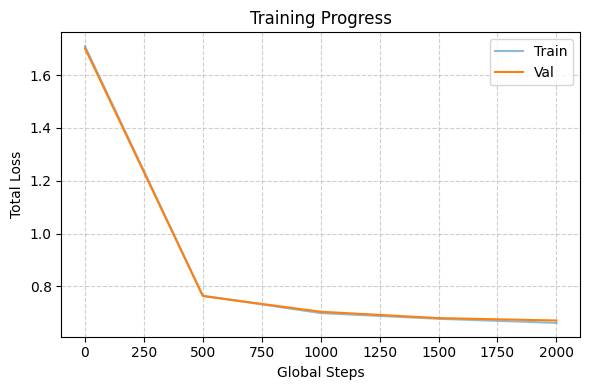

In [ ]:
plot_training_results(logs3["train_loss"], logs3["val_loss"], 500, title="Training Progress", y_title="Total Loss")

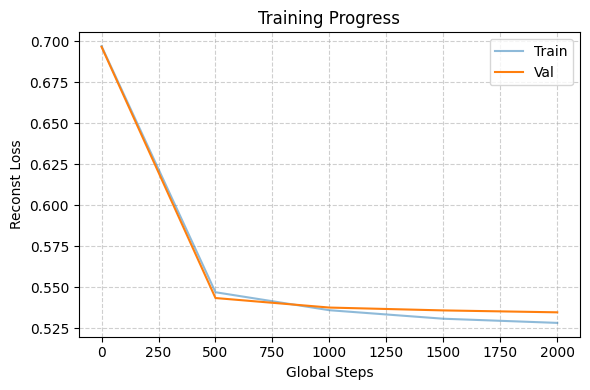

In [ ]:
plot_training_results(logs3["train_l1"], logs3["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

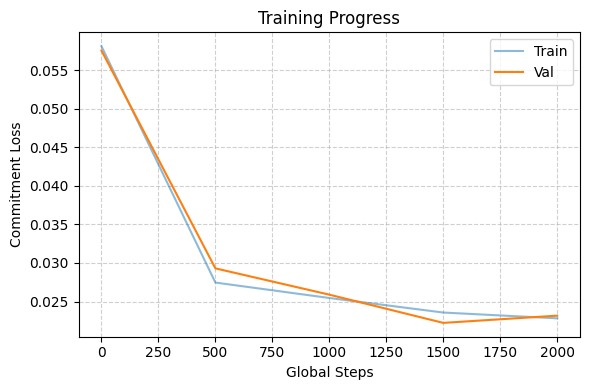

In [ ]:
plot_training_results(logs3["train_l3"], logs3["val_l3"], 500, title="Training Progress", y_title="Commitment Loss")

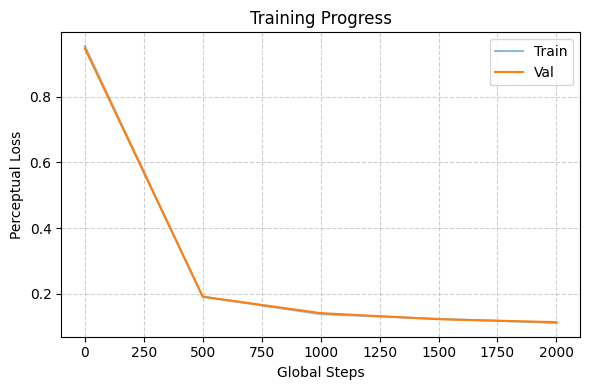

In [ ]:
plot_training_results(logs3["train_percep_loss"], logs3["val_percep_loss"], 500, title="Training Progress", y_title="Perceptual Loss")

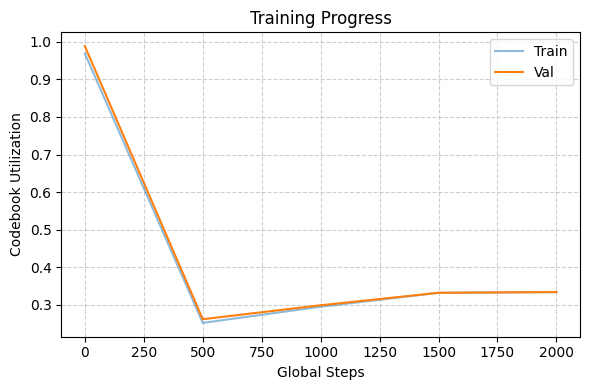

In [ ]:
plot_training_results(logs3["train_codebook"], logs3["val_codebook"], 500, title="Training Progress", y_title="Codebook Utilization")

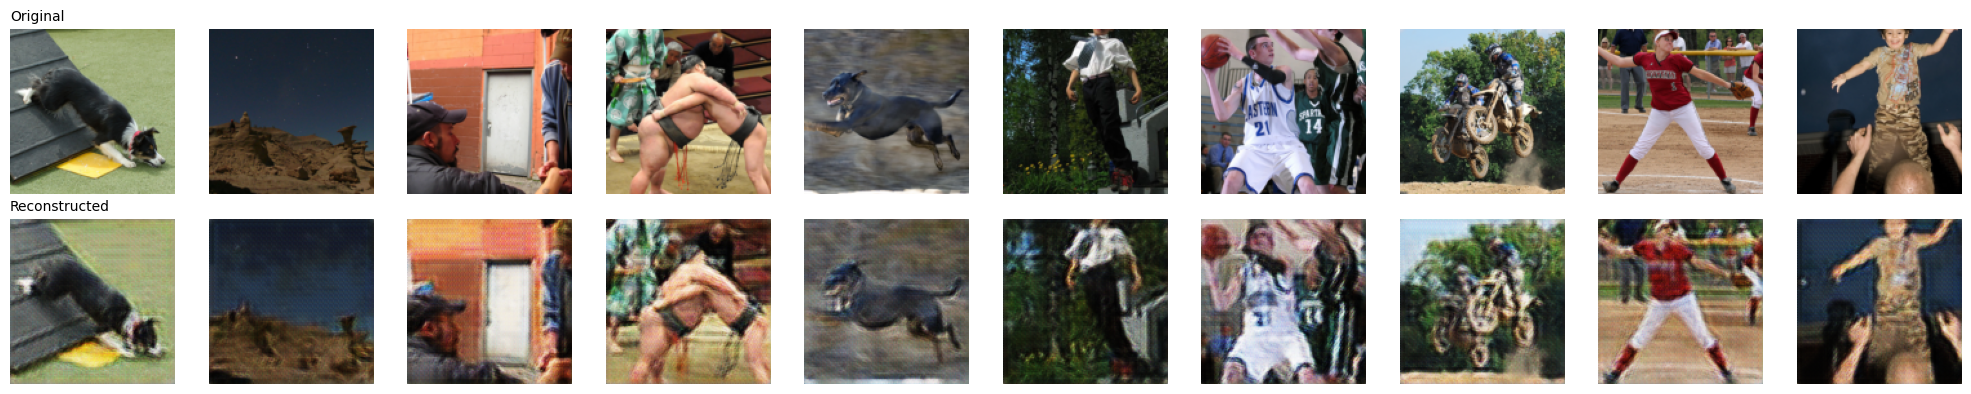

In [ ]:
vqvae = VQVAE2(in_channels=3, out_channels=3, latent_dim=128, hidden=128, k=512, normalize_codebook=False)
vqvae.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen_flickr8k.pt"))
vqvae.to(device)

plot_generated_vs_original(vqvae, val_loader_vqvae_2, device=device)

## **Prior Training**

In [ ]:
vqvae = VQVAE2(in_channels=3, out_channels=3, latent_dim=128, hidden=128, k=512, normalize_codebook=False)
vqvae.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen_flickr8k.pt", map_location="cpu"))
vqvae.to(device)

VQVAE2(
  (encoder): Encoder2(
    (net): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (2): ResidualBlock2(
        (block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (3): ResidualBlock2(
        (block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (4): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (decoder): Decoder2(
    (net): Sequential(
      (0): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
      (1): ResidualBlock2(
        (block): Sequential(
          (0): R

In [ ]:
enc = tk.get_encoding("gpt2")

tokenizer = tk.Encoding(
    name="gpt2_custom",
    pat_str=enc._pat_str,
    mergeable_ranks=enc._mergeable_ranks,
    special_tokens={
        **enc._special_tokens,
        "<|startoftext|>": enc.max_token_value + 1,  # new unique ID
        "<|pad|>": enc.max_token_value + 2,  # new unique ID
        "<|startofimage|>": enc.max_token_value + 3  # new unique ID
    }
)

In [ ]:
tokenizer.special_tokens_set

{'<|endoftext|>', '<|pad|>', '<|startofimage|>', '<|startoftext|>'}

In [ ]:
PAD_ID = tokenizer._special_tokens["<|pad|>"]
SOI_ID = tokenizer._special_tokens["<|startofimage|>"]
BOS_ID = tokenizer._special_tokens["<|startoftext|>"]

In [ ]:
tokenizer.n_vocab

50260

In [ ]:
class TokenizedTextImageDataset(Dataset):
  def __init__(self, model, tokenizer, loader, device):
    self.tokenized_images = []
    self.tokenized_text = []
    model.to(device)
    for x, y in tqdm(loader, desc="Generating codes"):
      x = x.to(device)
      B = x.shape[0]
      with torch.no_grad():
        z_e = model.encoder(x)
        z_q, discrete_codes = model.vq_layer(z_e, training=False)
      discrete_codes = discrete_codes.reshape(B, -1).cpu()
      self.tokenized_images.extend(discrete_codes.tolist())
      for caption in y:
        tokens = tokenizer.encode(caption.lower())
        self.tokenized_text.append(tokens)

  def __len__(self):
    return len(self.tokenized_images)

  def __getitem__(self, idx):
    return self.tokenized_images[idx], self.tokenized_text[idx]

In [ ]:
train_dataset_prior_2 = TokenizedTextImageDataset(vqvae, tokenizer, train_loader_vqvae_2, device)
val_dataset_prior_2 = TokenizedTextImageDataset(vqvae, tokenizer, val_loader_vqvae_2, device)

Generating codes: 100%|██████████| 102/102 [00:07<00:00, 13.38it/s]


In [ ]:
torch.save({
    "tokenized_images": train_dataset_prior_2.tokenized_images,
    "tokenized_text": train_dataset_prior_2.tokenized_text
}, "/content/drive/My Drive/GenAI/Data/train_dataset_prior_2.pt")

torch.save({
    "tokenized_images": val_dataset_prior_2.tokenized_images,
    "tokenized_text": val_dataset_prior_2.tokenized_text
}, "/content/drive/My Drive/GenAI/Data/val_dataset_prior_2.pt")

In [ ]:
class LoadTokenizedTextImageDataset(Dataset):
    def __init__(self, tokenized_images, tokenized_text):
        self.tokenized_images = tokenized_images
        self.tokenized_text = tokenized_text

    def __len__(self):
        return len(self.tokenized_images)

    def __getitem__(self, idx):
        return self.tokenized_images[idx], self.tokenized_text[idx]

In [ ]:
train_data = torch.load("/content/drive/My Drive/GenAI/Data/train_dataset_prior_2.pt")

train_dataset_prior_2 = LoadTokenizedTextImageDataset(
    train_data["tokenized_images"],
    train_data["tokenized_text"]
)

val_data = torch.load("/content/drive/My Drive/GenAI/Data/val_dataset_prior_2.pt")

val_dataset_prior_2 = LoadTokenizedTextImageDataset(
    val_data["tokenized_images"],
    val_data["tokenized_text"]
)

In [ ]:
max_len_1 = 0
for img, text in train_dataset_prior_2:
  max_len_1 = max(max_len_1, len(text))
print(f"Train dataset max text seq length: {max_len_1}")

max_len_2 = 0
for img, text in val_dataset_prior_2:
  max_len_2 = max(max_len_2, len(text))
print(f"Val dataset max text seq length: {max_len_2}")

Train dataset max text seq length: 38
Val dataset max text seq length: 32


In [ ]:
def collator(batch, text_vocab_size, max_text_tokens, sot_id=50257, pad_id=50258, soi_id=50259):
  input_text_tokens = []
  input_image_tokens = []
  target_text_tokens = []
  target_image_tokens = []
  for img_tokens, text_tokens in batch:
    text_tokens = [sot_id] + text_tokens
    if len(text_tokens) > max_text_tokens:
      new_text_tokens = text_tokens[:max_text_tokens]
    else:
      new_text_tokens = text_tokens + [pad_id] * (max_text_tokens - len(text_tokens))
    img_tokens = [text_vocab_size+img_code for img_code in img_tokens]
    new_image_tokens = [soi_id] + img_tokens

    input_text_tokens.append(new_text_tokens)
    input_image_tokens.append(new_image_tokens[:-1])

    target_text_tokens.append(new_text_tokens[1:] + [new_image_tokens[0]])
    target_image_tokens.append(new_image_tokens[1:])


  input_text_tokens = torch.tensor(input_text_tokens)
  input_image_tokens = torch.tensor(input_image_tokens)
  target_text_tokens = torch.tensor(target_text_tokens)
  target_image_tokens = torch.tensor(target_image_tokens)
  inputs = {"text_tokens": input_text_tokens, "image_tokens": input_image_tokens}
  targets = {"text_tokens": target_text_tokens, "image_tokens": target_image_tokens}

  return inputs, targets

### Transformer

In [ ]:
PRIOR_CONFIG_2 = {
    'emb_size':1024, # increased emb size to 1024 from 768 for this exp
    'context_length':32, # trying context length of 32 instead of 256
    'text_vocab_size':tokenizer.n_vocab,
    "codebook_size": 512,
    'num_heads':16, # from 12 to 16 for this exp
    'num_layers':6, # reduced layers from 12 to 6 for this exp
    'drop_rate':0.1,
    'grid_size': (32, 32),
    'row_extension': 33, # for 32 x 32 grid, the row extension of 33 will allow to attend the same column from prev row
    'kernel_size': 11, # kernel size of convolution attention mask
    'cfg_drop': 0.1,
    'qkv_bias': False,
}

PRIOR_CONFIG_2["total_vocab_size"] = PRIOR_CONFIG_2["text_vocab_size"] + PRIOR_CONFIG_2["codebook_size"]

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, mask_type, grid_size, row_extension, kernel_size, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        self._create_mask(
            mask_type,
            context_length,
            grid_size=grid_size,
            row_extension=row_extension,
            kernel_size=kernel_size,
    ))

  def _create_mask(
      self,
      mask_type,
      text_len,
      grid_size=(32, 32),
      row_extension=32,
      kernel_size=11,
      use_soi=True,
  ):
      H, W = grid_size
      image_len = H * W
      soi_tokens = 1 if use_soi else 0
      total_len = text_len + soi_tokens + image_len
      mask = torch.zeros(
          (total_len, total_len),
          dtype=torch.bool
      )
      # =========================================================
      # TEXT TOKENS
      # Standard causal mask
      # =========================================================
      for i in range(text_len):
          mask[i, : i + 1] = True
      # =========================================================
      # SOI TOKEN
      # =========================================================
      if use_soi:
          soi_idx = text_len
          # SOI attends to all previous text tokens
          mask[soi_idx, : text_len + 1] = True
          image_offset = text_len + 1
      else:
          soi_idx = None
          image_offset = text_len
      # =========================================================
      # IMAGE TOKENS
      # =========================================================
      for img_idx in range(image_len):
          q = image_offset + img_idx
          # -----------------------------------------------------
          # image tokens attend to all text tokens
          # -----------------------------------------------------
          mask[q, :text_len] = True
          # -----------------------------------------------------
          # attend to SOI token
          # -----------------------------------------------------
          if use_soi:
              mask[q, soi_idx] = True
          row = img_idx // W
          col = img_idx % W
          # =====================================================
          # ROW ATTENTION
          # =====================================================
          if mask_type == "row":
              start = max(0, img_idx - row_extension)
              for prev in range(start, img_idx + 1):
                  mask[q, image_offset + prev] = True
          # =====================================================
          # COLUMN ATTENTION
          # =====================================================
          elif mask_type == "column":
              for prev in range(img_idx + 1):
                  prev_row = prev // W
                  prev_col = prev % W
                  same_col = (prev_col == col)
                  within_extent = (
                      row - prev_row
                  ) <= row_extension
                  if same_col and within_extent:
                      mask[q, image_offset + prev] = True
          # =====================================================
          # CONVOLUTION ATTENTION
          # WITH WRAPAROUND BEHAVIOR
          # =====================================================
          elif mask_type == "convolution":
              radius = kernel_size // 2
              for prev in range(img_idx + 1):
                  prev_row = prev // W
                  prev_col = prev % W
                  dr = row - prev_row
                  # horizontal wraparound distance
                  dc = min(
                      abs(col - prev_col),
                      W - abs(col - prev_col)
                  )
                  inside_kernel = (
                      abs(dr) <= radius
                      and dc <= radius
                  )
                  if inside_kernel:
                      mask[q, image_offset + prev] = True
          else:
              raise ValueError(
                  f"Unknown mask type: {mask_type}"
              )
      return ~mask

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    attention_scores = queries @ keys.transpose(2,3)
    attention_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self, emb_size):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_size))
    self.shift = nn.Parameter(torch.zeros(emb_size))

  def forward(self, x):
    mean = x.mean(keepdim=True, dim=-1)
    variance = x.var(keepdim=True, dim=-1, unbiased=False)
    norm_x = (x - mean)/torch.sqrt(variance + self.eps)
    return self.scale * norm_x + self.shift

In [ ]:
class GeLU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
    ))

In [ ]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_size'], 4 * cfg['emb_size']),
        GeLU(),
        nn.Linear(4 * cfg['emb_size'], cfg['emb_size'])
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg, mask_type):
    super().__init__()
    self.mha = MultiHeadAttention(cfg['emb_size'], cfg['emb_size'], cfg['context_length'], cfg['drop_rate'], cfg['num_heads'], mask_type, cfg['grid_size'], cfg['row_extension'], cfg['kernel_size'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.ffn = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [ ]:
class Prior(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['total_vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.null_emb_layer = nn.Embedding(1, cfg['emb_size'])
    self.row_emb_layer = nn.Embedding(cfg['grid_size'][0], cfg['emb_size'])
    self.col_emb_layer = nn.Embedding(cfg['grid_size'][1] + 1, cfg['emb_size']) # the 0th col_emb is for startofimage token only and not for any of the image tokens belonging to the zeroth column in 2d view
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg, self._mask_type(i, cfg['num_layers'])) for i in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['total_vocab_size'], bias=False)
    self.num_rows = cfg['grid_size'][0]
    self.num_cols = cfg['grid_size'][1]
    self.context_length = cfg['context_length']
    self.cfg_drop = cfg['cfg_drop']

  def _mask_type(self, i, num_layers):
    if i==num_layers-1:
      return 'convolution'
    elif (i-1)%4==0:
      return 'column'
    else:
      return 'row'

  def forward(self, input, training=False):
    text_tokens = input.get('text_tokens', None) # text_tokens will be None for unconditional inference
    image_tokens = input.get('image_tokens', None) # soi token belongs to image_tokens seq
    batch_size, num_img_tokens = image_tokens.shape
    null_emb = self.null_emb_layer(torch.tensor(0).to(image_tokens.device))
    if text_tokens is None: # during unconditional inference
      text_token_emb = null_emb.unsqueeze(0).unsqueeze(0).expand(batch_size, self.context_length, -1)
    else:
      text_token_emb = self.token_emb_layer(text_tokens)
    _, num_text_tokens, _ = text_token_emb.shape
    pos_emb = self.pos_emb_layer(
        torch.arange(num_text_tokens, device=image_tokens.device)
    )
    if training:
      drop_ind = torch.rand(batch_size) < self.cfg_drop
      text_token_emb[drop_ind] = null_emb.unsqueeze(0).expand(num_text_tokens, -1)
    text_emb = text_token_emb + pos_emb
    image_token_emb = self.token_emb_layer(image_tokens)
    # row_emb = self.row_emb_layer(
    #     torch.arange((num_img_tokens-1)//self.num_rows, device=image_tokens.device)
    # )
    # cols_to_use = min(num_img_tokens-1, self.num_cols) + 1 # for +1 for soi token
    # col_emb = self.col_emb_layer(
    #     torch.arange(cols_to_use, device=image_tokens.device)
    # )
    # image_token_emb[0] = image_token_emb[0] + row_emb[0] + col_emb[0] # soi separately
    # row_emb_repeat = torch.repeat_interleave(row_emb, self.num_cols, dim=0)[:num_img_tokens-1] # excluded soi since it is already done
    # col_emb_repeat = torch.tile(col_emb[1:], ((num_img_tokens-1) // (cols_to_use - 1) + 1,))[:num_img_tokens-1] # excluded soi since it is already done
    # image_token_emb[1:] = image_token_emb[1:] + row_emb_repeat + col_emb_repeat
    # for each image token (excluding SOI), compute which row it belongs to
    image_token_emb[:,0] = image_token_emb[:,0] + self.row_emb_layer(torch.tensor(0, device=image_tokens.device)) + self.col_emb_layer(torch.tensor(0, device=image_tokens.device)) # soi separately
    img_indices = torch.arange(num_img_tokens - 1, device=image_tokens.device)
    row_indices = img_indices // self.num_cols   # shape (num_img_tokens-1,)
    col_indices = img_indices % self.num_cols    # shape (num_img_tokens-1,)
    row_emb = self.row_emb_layer(row_indices)   # (num_img_tokens-1, emb_size)
    col_emb = self.col_emb_layer(col_indices + 1)  # +1 to skip the SOI col slot
    image_token_emb[:,1:] = image_token_emb[:,1:] + row_emb + col_emb
    x = torch.cat((text_emb, image_token_emb), dim=1)
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits

### Training

In [ ]:
def ce_batch_loss_calc(input_batch, target_batch, model, device, cfg, training=False):
  input_batch = {k:v.to(device) for k,v in input_batch.items()}
  target_batch = {k:v.to(device) for k,v in target_batch.items()}
  logits_batch = model(input_batch, training=training)
  # loss_text = torch.nn.functional.cross_entropy(logits_batch[:, :cfg['context_length'], :].flatten(0, 1), target_batch['text_tokens'].flatten()) / cfg['context_length'] # dividing to normalize wrt text token occurence
  # loss_image = torch.nn.functional.cross_entropy(logits_batch[:, cfg['context_length']:, :].flatten(0, 1), target_batch['image_tokens'].flatten()) / (cfg['grid_size'][0] * cfg['grid_size'][1]) # dividing to normalize wrt image token occurence
  # correct implementation
  loss_text = torch.nn.functional.cross_entropy(logits_batch[:, :cfg['context_length'], :].flatten(0, 1), target_batch['text_tokens'].flatten(), ignore_index=PAD_ID, reduction='mean')
  loss_image = torch.nn.functional.cross_entropy(logits_batch[:, cfg['context_length']:, :].flatten(0, 1), target_batch['image_tokens'].flatten(), reduction='mean')
  loss = 0.125 * loss_text + 0.875 * loss_image

  return loss

In [ ]:
def calc_loss_dataloader(loader, model, device, cfg, num_batches=None):
  total_loss = 0
  if len(loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(loader)
  elif num_batches < 0:
    num_batches = float('nan')
  else:
    num_batches = min(num_batches, len(loader))

  for i, (x, y) in enumerate(loader):
    if i < num_batches:
      loss = ce_batch_loss_calc(x, y, model, device, cfg, training=False)
      total_loss += loss.item()
    else:
      break

  return total_loss/num_batches

In [ ]:
def evaluate_prior(model, train_loader, val_loader, device, cfg, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_dataloader(train_loader, model, device, cfg, eval_iter)
    val_loss = calc_loss_dataloader(val_loader, model, device, cfg, eval_iter)
  model.train()

  return train_loss, val_loss

In [ ]:
def generate(model, tokenizer, inputs, max_gen_tokens, cfg_weight, temperature=0.0, top_k=None, eos_id=None): # cfg_weight -> classifier-free guidance
  B, N = inputs['text_tokens'].shape
  finished = torch.zeros(B, dtype=torch.bool, device=inputs['text_tokens'].device)
  for i in range(max_gen_tokens):
    with torch.no_grad():
      cond_inp = inputs
      logits_c = model(cond_inp, training=False)[:, -1, :]

      uncond_inp = {'text_tokens': None, 'image_tokens': inputs['image_tokens']}
      logits_u = model(uncond_inp, training=False)[:, -1, :]
    logits = logits_u + cfg_weight * (logits_c - logits_u) # classifier free guidance for boosting logits for tokens which are caption or condition relevant

    print(torch.softmax(logits, dim=-1)[:, 50601])
    # logits[:,:tokenizer.n_vocab] = torch.tensor(float('-inf'), device=logits.device) # this line ensures that only image tokens are generated

    if top_k is not None:
      top_logits, top_idx = torch.topk(logits, top_k)
      logits = torch.where(
          condition=logits<top_logits[:,-1, None],
          input=torch.tensor(float('-inf'), device=logits.device),
          other=logits
      )

    if temperature > 0:
      scaled_logits = logits / temperature
      probs = torch.softmax(scaled_logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)

    if eos_id is not None:
        finished |= (idx_next.squeeze(-1) == eos_id)
        idx_next[finished] = eos_id

    inputs['image_tokens'] = torch.cat((inputs['image_tokens'], idx_next), dim=1)

    if finished.all():
        break

  return inputs['image_tokens']

In [ ]:
def reconstruct_from_prior(vqvae, img_tokens, device):
  vqvae.eval()
  with torch.no_grad():
    img_tokens = img_tokens.to(device) # (B, H, W)
    codebook_latents = vqvae.vq_layer.codebook[img_tokens].permute(0, 3, 1, 2) # (B, emb_dim, H, W)
    reconst = vqvae.sigmoid(vqvae.decoder(codebook_latents))
  return reconst

In [ ]:
def tokenize_text(text, tokenizer, max_text_tokens):
  tokens = tokenizer.encode(text.lower())
  tokens = [BOS_ID] + tokens
  if len(tokens) > max_text_tokens:
    new_tokens = tokens[:max_text_tokens]
  else:
    new_tokens = tokens + [PAD_ID] * (max_text_tokens - len(tokens))
  return new_tokens

In [ ]:
def generate_and_render_sample(model, vqvae, tokenizer, cfg, cfg_weight, text_prompts, device, temperature=0.7):
  model.eval()
  input_text_tokens = []
  for text in text_prompts:
    text_tokens = tokenize_text(text, tokenizer, cfg['context_length'])
    input_text_tokens.append(text_tokens)
  input_image_tokens = [[SOI_ID] for i in range(len(text_prompts))]
  inputs = {
      'text_tokens': torch.tensor(input_text_tokens, device=device),
      'image_tokens': torch.tensor(input_image_tokens, device=device)
  }
  with torch.no_grad():
    op_tokens = generate(
        model,
        inputs=inputs,
        tokenizer=tokenizer,
        max_gen_tokens=1024,
        cfg_weight=cfg_weight,
        temperature=temperature,
        top_k=25
    )
  print(op_tokens[:,:50])
  img_tokens = op_tokens[:,1:].reshape(-1, cfg['grid_size'][0], cfg['grid_size'][1]) # remove soi token and reshape to 32 * 32 grid expected by vqvae decoder
  img_tokens = img_tokens - tokenizer.n_vocab # to get back original image codes
  reconst = reconstruct_from_prior(vqvae, img_tokens, device).cpu()

  fig, axes = plt.subplots(1, len(text_prompts), figsize=(16, 6))
  for i in range(len(text_prompts)):
    axes[i].imshow(torch.permute(reconst[i], (1, 2, 0)))
    axes[i].axis("off")
  plt.tight_layout()
  plt.show()

In [ ]:
import time

def train_model_simple(
    model,
    vqvae,
    cfg,
    train_loader,
    val_loader,
    device,
    optimizer,
    tokenizer,
    epochs,
    eval_freq,
    eval_iter,
    text_prompts,
    cfg_weight
):
    train_loss_arr, val_loss_arr, track_tokens_seen, grad_norms_arr = [], [], [], []
    global_step, tokens_seen = -1, 0

    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    t_start = time.time()

    for epoch in range(epochs):
        model.train()

        for x, y in train_loader:
            optimizer.zero_grad()

            train_loss = ce_batch_loss_calc(
                x, y, model, device, cfg, training=True
            )

            train_loss.backward()

            # global grad norm
            total_norm = 0.0

            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.detach().data.norm(2)
                    total_norm += param_norm.item() ** 2

            total_norm = total_norm ** 0.5
            grad_norms_arr.append(total_norm)

            optimizer.step()

            tokens_seen += (
                x['text_tokens'].numel()
                + x['image_tokens'].numel()
            )

            global_step += 1

            if global_step % eval_freq == 0:

                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done

                eta_minutes = (
                    (elapsed / steps_done) * steps_left
                ) / 60

                train_loss, val_loss = evaluate_prior(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    cfg,
                    eval_iter
                )

                train_loss_arr.append(train_loss)
                val_loss_arr.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f}")
                print(f"\tVal Loss:   {val_loss:.4f}")
                print(f"\tTokens Seen: {tokens_seen}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

            if global_step % (eval_freq * 5) == 0: # if eval_freq=100 then generation will happen every 5000 steps
                generate_and_render_sample(
                    model,
                    vqvae,
                    tokenizer,
                    cfg,
                    cfg_weight,
                    text_prompts,
                    device
                )
                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return train_loss_arr, val_loss_arr, track_tokens_seen, grad_norms_arr

In [ ]:
prior_collate_fn = partial(collator, text_vocab_size=tokenizer.n_vocab, max_text_tokens=PRIOR_CONFIG_2['context_length'])

train_loader_prior_2 = DataLoader(train_dataset_prior_2, batch_size=8, shuffle=True, num_workers=0, collate_fn=prior_collate_fn)
val_loader_prior_2 = DataLoader(val_dataset_prior_2, batch_size=8, shuffle=False, num_workers=0, collate_fn=prior_collate_fn)

In [ ]:
torch.manual_seed(123)
model4 = Prior(PRIOR_CONFIG_2)
model4.to(device)
optimizer4 = torch.optim.AdamW(model4.parameters(), lr=0.0004, weight_decay=0.1)
text_prompts = [
                  'a black dog in the middle of running or leaping .',
                  'two dirt bike riders in midair .'
                  # 'a cat that is standing on a toilet and next to a sink'
                  # 'some people are flying kites and one male has a red tie on',
                  # 'a work crew repairs a stop in the town.'
                ]
train_losses4, val_losses4, tokens_seen4, grad_norms_arr4 = train_model_simple(model4, vqvae, PRIOR_CONFIG_2, train_loader_prior_2, val_loader_prior_2, device, optimizer4, tokenizer, epochs=15, eval_freq=100, eval_iter=5, text_prompts=text_prompts, cfg_weight=4)

In [ ]:
# torch.manual_seed(123)
# model4 = Prior(PRIOR_CONFIG_2)
# model4.to(device)
# optimizer4 = torch.optim.AdamW(model4.parameters(), lr=0.0004, weight_decay=0.1)
# text_prompts = [
#                   'A bride and groom pose with their wedding party.',
#                   'A man crouched on a snowy peak.'
#                   # 'a cat that is standing on a toilet and next to a sink'
#                   # 'some people are flying kites and one male has a red tie on',
#                   # 'a work crew repairs a stop in the town.'
#                 ]
# train_losses4, val_losses4, tokens_seen4, grad_norms_arr4 = train_model_simple(model4, vqvae, PRIOR_CONFIG_2, train_loader_prior_2, val_loader_prior_2, device, optimizer4, tokenizer, epochs=1, eval_freq=100, eval_iter=5, text_prompts=text_prompts, cfg_weight=4)

In [ ]:
torch.save(model4.state_dict(), '/content/drive/My Drive/GenAI/Data/text_to_image_prior_model_flickr8k.pt')

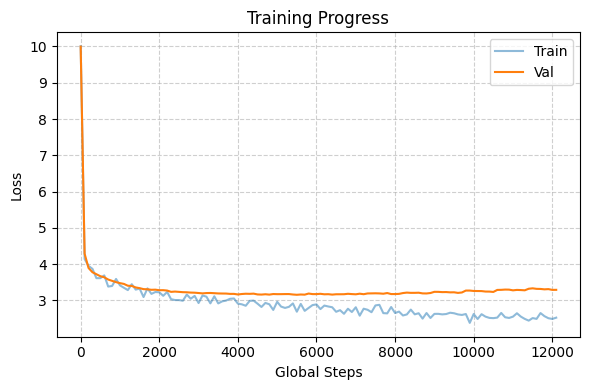

In [ ]:
plot_training_results(train_losses4, val_losses4, 100, title="Training Progress", y_title="Loss")

In [ ]:
# Save checkpoint
checkpoint = {
    "model_state_dict": model4.state_dict(),
    "optimizer_state_dict": optimizer4.state_dict()
}

torch.save(checkpoint, "text_to_image_prior_2_checkpoint_1.pt")

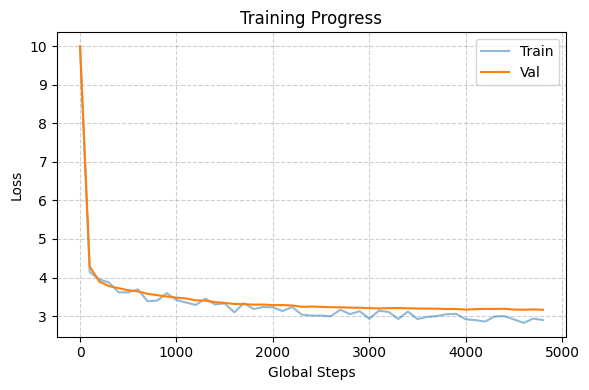

In [ ]:
# plot_training_results(train_losses4, val_losses4, 100, title="Training Progress", y_title="Loss")

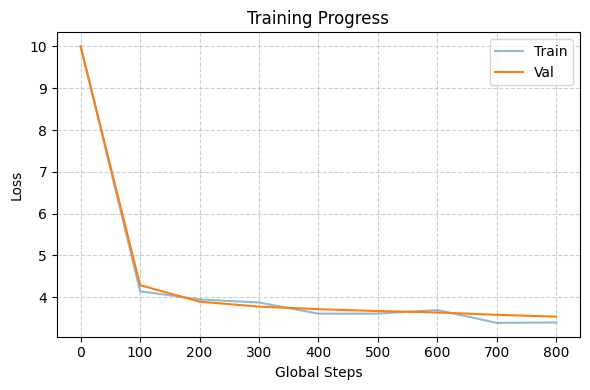

In [ ]:
# plot_training_results(train_losses4, val_losses4, 100, title="Training Progress", y_title="Loss")

In [ ]:
all_codes = torch.cat([torch.tensor(train_dataset_prior_2[i][0]) for i in range(len(train_dataset_prior_2))])
counts = torch.bincount(all_codes.flatten().long(), minlength=512)

for code_id, count in enumerate(counts):
    print(f"code {code_id}: {count.item()}")

code 0: 47415
code 1: 0
code 2: 0
code 3: 38571
code 4: 0
code 5: 0
code 6: 0
code 7: 28727
code 8: 0
code 9: 32342
code 10: 0
code 11: 52430
code 12: 0
code 13: 72371
code 14: 0
code 15: 12953
code 16: 0
code 17: 18940
code 18: 29862
code 19: 0
code 20: 0
code 21: 39373
code 22: 0
code 23: 43160
code 24: 17691
code 25: 36828
code 26: 0
code 27: 18315
code 28: 0
code 29: 0
code 30: 42629
code 31: 40288
code 32: 0
code 33: 0
code 34: 0
code 35: 0
code 36: 0
code 37: 0
code 38: 0
code 39: 44280
code 40: 0
code 41: 23959
code 42: 0
code 43: 53653
code 44: 41703
code 45: 0
code 46: 0
code 47: 0
code 48: 0
code 49: 35454
code 50: 0
code 51: 0
code 52: 49357
code 53: 0
code 54: 0
code 55: 0
code 56: 0
code 57: 0
code 58: 0
code 59: 58006
code 60: 31333
code 61: 0
code 62: 59475
code 63: 0
code 64: 0
code 65: 0
code 66: 0
code 67: 0
code 68: 0
code 69: 14671
code 70: 57188
code 71: 38896
code 72: 45492
code 73: 0
code 74: 0
code 75: 9739
code 76: 13815
code 77: 32680
code 78: 38741
code 79: 0

In [ ]:
print(f"codes used: {(counts > 0).sum().item()} / {512}")
print(f"most common: code {counts.argmax().item()} ({counts.max().item()} times)")

print(f"least used (nonzero): code {counts[counts > 0].argmin().item()} {counts[counts > 0].min().item()} times")

codes used: 172 / 512
most common: code 287 (137471 times)
least used (nonzero): code 67 8 times


In [ ]:
prior_model = Prior(PRIOR_CONFIG_2)
prior_model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/text_to_image_prior_model_flickr8k.pt", map_location="cpu"))
prior_model.to(device)

Prior(
  (token_emb_layer): Embedding(50772, 1024)
  (pos_emb_layer): Embedding(32, 1024)
  (null_emb_layer): Embedding(1, 1024)
  (row_emb_layer): Embedding(32, 1024)
  (col_emb_layer): Embedding(33, 1024)
  (dropout_layer): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (mha): MultiHeadAttention(
        (w_query): Linear(in_features=1024, out_features=1024, bias=False)
        (w_key): Linear(in_features=1024, out_features=1024, bias=False)
        (w_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GeLU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )

0 sequence
Input Text Seq: tensor([50257,    64,  7586,   837,  2042,   290,  2330,  3290,   318,   319,
          257, 22007,  1781,   764, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258], device='cuda:0')
Target Text Seq: tensor([   64,  7586,   837,  2042,   290,  2330,  3290,   318,   319,   257,
        22007,  1781,   764, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50259], device='cuda:0')
Predicted Text Seq: tensor([   64,   582,  3290,  2042,   837,  2330,  3290,   351,  2712,   257,
         4171,   764,   764,   764,   764,   764,   257,   764,   764,   764,
          764,   764,   764,   764,   257,   764,   764,   257,   764,   764,
          257, 50259], device='cuda:0')
Input Image Seq: tensor([50259, 50630, 50348, 50320, 50404, 50524, 50562, 50397, 50346, 50309,
        50309, 5026

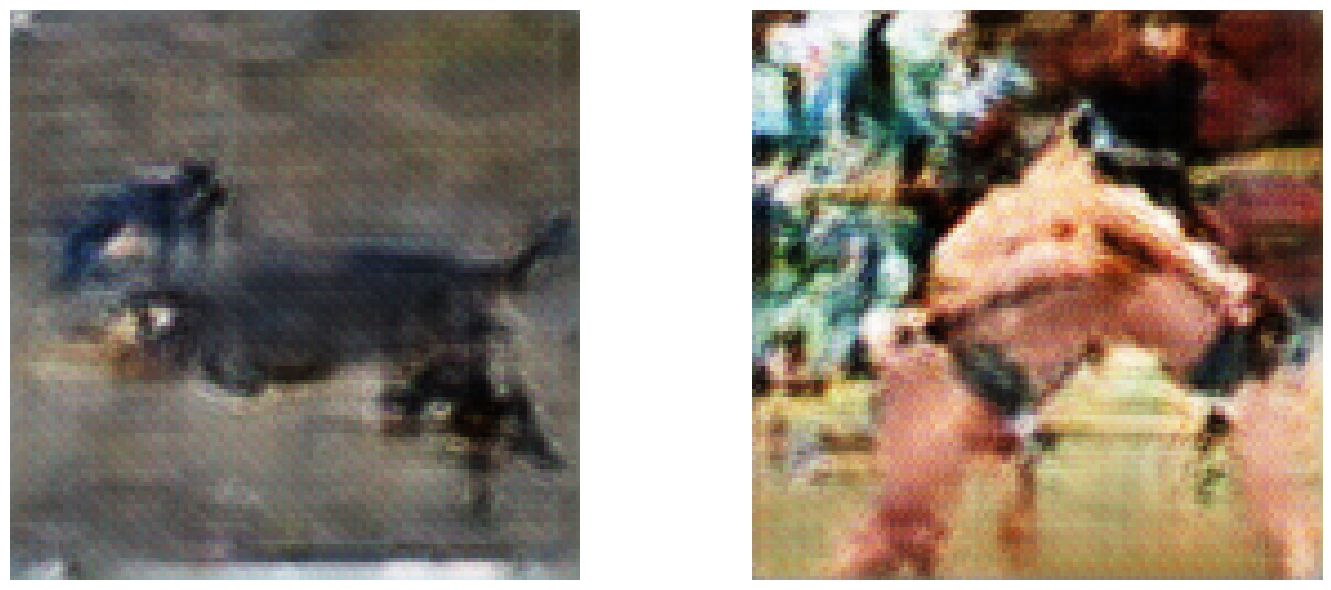

In [ ]:
cfg_weight = 1
with torch.no_grad():
  for x, y in val_loader_prior_2:
    x = {k:v.to(device) for k,v in x.items()}
    y = {k:v.to(device) for k,v in y.items()}
    cond_inp = x
    logits_c = prior_model(cond_inp, training=False)

    uncond_inp = {'text_tokens': None, 'image_tokens': x['image_tokens']}
    logits_u = prior_model(uncond_inp, training=False)
    logits_batch = logits_u + cfg_weight * (logits_c - logits_u)
    logits_batch[:,PRIOR_CONFIG_2['context_length']:,:tokenizer.n_vocab] = torch.tensor(float('-inf'), device=logits_batch.device) # this line ensures that only image tokens are generated

    pred_seq = torch.argmax(logits_batch, dim=-1)
    for i in range(pred_seq.shape[0]):
      print(f"{i} sequence")
      print(f"Input Text Seq: {x['text_tokens'][i]}")
      print(f"Target Text Seq: {y['text_tokens'][i]}")
      # print(f"Predicted Text Seq: {pred_seq[:, :PRIOR_CONFIG_2['context_length']][i]}")
      print(f"Predicted Text Seq: {torch.argmax(logits_c, dim=-1)[:, :PRIOR_CONFIG_2['context_length']][i]}")
      print(f"Input Image Seq: {x['image_tokens'][i][:50]}")
      print(f"Target Image Seq: {y['image_tokens'][i][:50]}")
      print(f"Predicted Image Seq: {pred_seq[:,PRIOR_CONFIG_2['context_length']:][i][:50]}")
      print()
    break

# image reconstruction from autoregressively generated image codes
img_tokens = pred_seq[[4,3],PRIOR_CONFIG_2['context_length']:].reshape(-1, PRIOR_CONFIG_2['grid_size'][0], PRIOR_CONFIG_2['grid_size'][1]) # remove soi token and reshape to 32 * 32 grid expected by vqvae decoder
img_tokens = img_tokens - tokenizer.n_vocab # to get back original image codes
reconst = reconstruct_from_prior(vqvae, img_tokens, device).cpu()

fig, axes = plt.subplots(1, img_tokens.shape[0], figsize=(16, 6))
for i in range(img_tokens.shape[0]):
  axes[i].imshow(torch.permute(reconst[i], (1, 2, 0)))
  axes[i].axis("off")
plt.tight_layout()
plt.show()

above images are not generated by predicting next tokens autoregressively. For each image token, instead of appending predicted token and passing it as input, the original input sequence was fed to the model.

2 cells below is the autoregressive image token prediction and image generation.

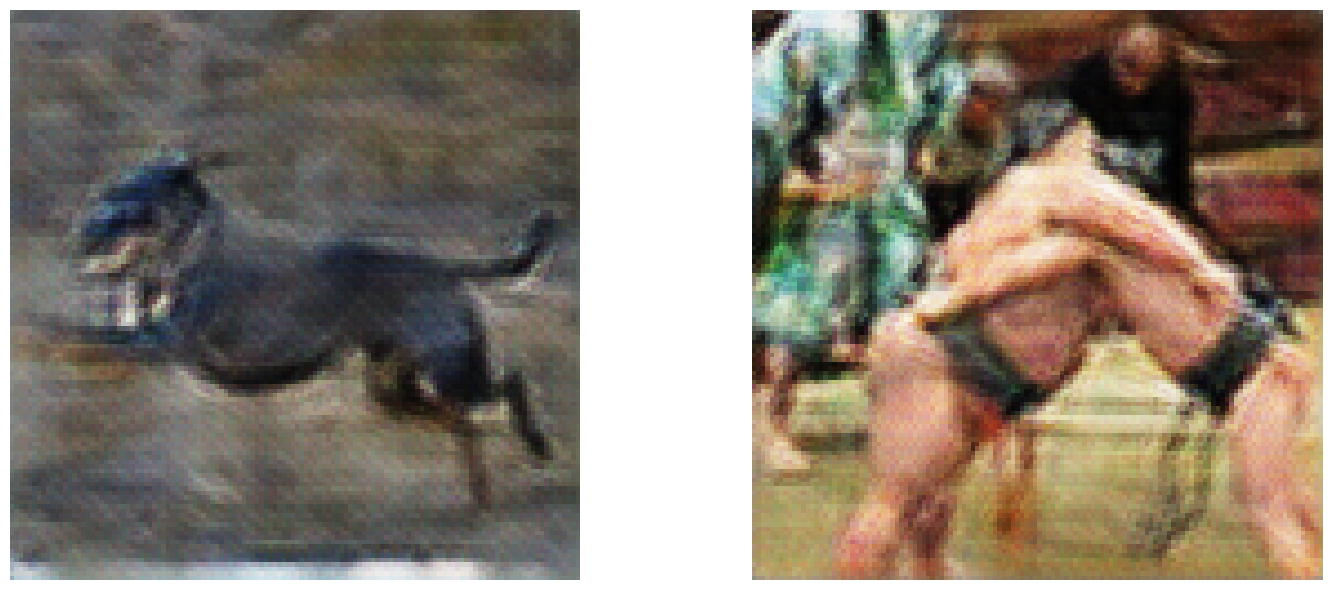

In [ ]:
# image reconstruction from original image codes
orig_img_tokens = torch.cat([x['image_tokens'][[4,3],1:], x['image_tokens'][[4,3],-1].unsqueeze(-1)], dim=-1).reshape(-1, PRIOR_CONFIG_2['grid_size'][0], PRIOR_CONFIG_2['grid_size'][1])
orig_img_tokens = orig_img_tokens - tokenizer.n_vocab # to get back original image codes
reconst_from_orig = reconstruct_from_prior(vqvae, orig_img_tokens, device).cpu()

fig, axes = plt.subplots(1, orig_img_tokens.shape[0], figsize=(16, 6))
for i in range(img_tokens.shape[0]):
  axes[i].imshow(torch.permute(reconst_from_orig[i], (1, 2, 0)))
  axes[i].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
for x, y in val_loader_prior_2:
  for i in range(x['text_tokens'].shape[0]):
    print(tokenizer.decode(x['text_tokens'][i].tolist()))
    print(tokenizer.decode(y['text_tokens'][i].tolist()))
    print()
  break

<|startoftext|>a brown , black and white dog is on a obstacle course .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>
a brown , black and white dog is on a obstacle course .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|startofimage|>

<|startoftext|>a person in the distance hikes among hoodoos with stars visible in the sky .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>
a person in the distance hikes among hoodoos with stars visible in the sky .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|startofimage|>

<|startoftext|>a man holding the hand of another man who has a tattoo on his arm .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>
a man holding the ha

tensor([0.0505, 0.0460], device='cuda:0')
tensor([0.4029, 0.3593], device='cuda:0')
tensor([0.7256, 0.6762], device='cuda:0')
tensor([0.8077, 0.7569], device='cuda:0')
tensor([0.8364, 0.8071], device='cuda:0')
tensor([0.8250, 0.7785], device='cuda:0')
tensor([0.8844, 0.8572], device='cuda:0')
tensor([0.9080, 0.8798], device='cuda:0')
tensor([0.9030, 0.8554], device='cuda:0')
tensor([0.9347, 0.9099], device='cuda:0')
tensor([0.9193, 0.8944], device='cuda:0')
tensor([0.9115, 0.8815], device='cuda:0')
tensor([0.9199, 0.8884], device='cuda:0')
tensor([0.9146, 0.9005], device='cuda:0')
tensor([0.9088, 0.8760], device='cuda:0')
tensor([0.9322, 0.9180], device='cuda:0')
tensor([0.9258, 0.8911], device='cuda:0')
tensor([0.9281, 0.8958], device='cuda:0')
tensor([0.9351, 0.9022], device='cuda:0')
tensor([0.9374, 0.9169], device='cuda:0')
tensor([0.9306, 0.9168], device='cuda:0')
tensor([0.9315, 0.9007], device='cuda:0')
tensor([0.9467, 0.9203], device='cuda:0')
tensor([0.9300, 0.9027], device='c

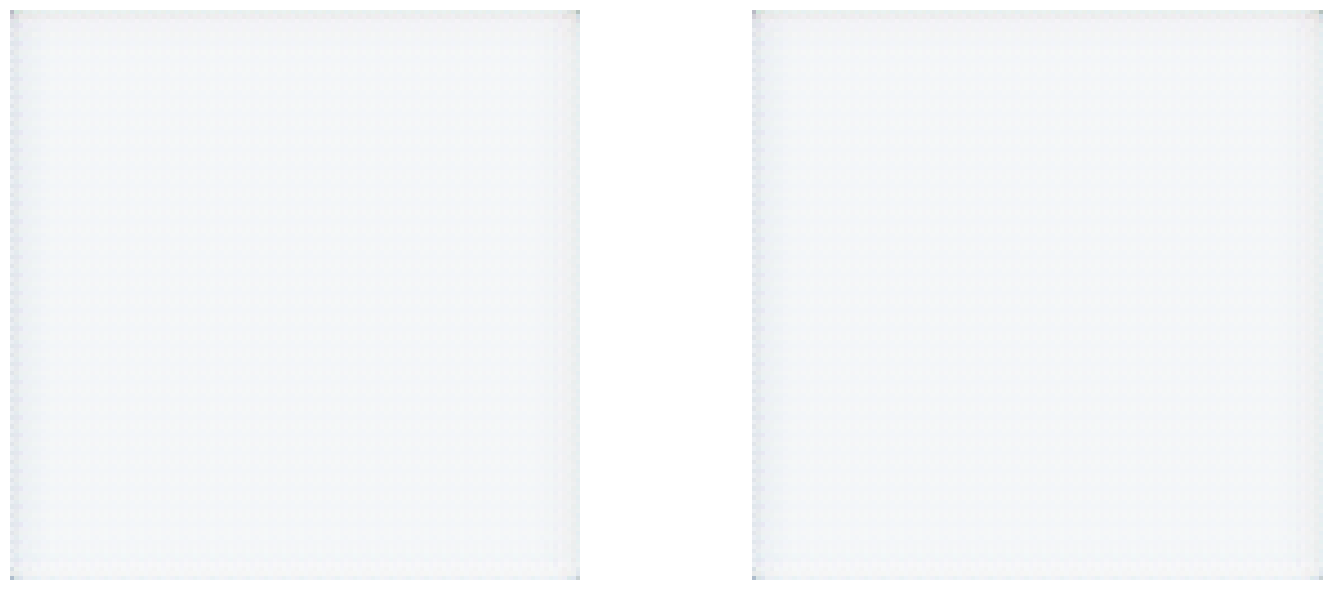

In [ ]:
samples_prompts = [
    'a black dog in the middle of running or leaping .',
    'one very fat sumo wrestler wrestles with a thinner wrestler while an umpire dressed in green watches .'
]

generate_and_render_sample(
                    prior_model,
                    vqvae,
                    tokenizer,
                    PRIOR_CONFIG_2,
                    cfg_weight=1,
                    text_prompts=samples_prompts,
                    device=device,
                    temperature=0
                )

In [ ]:
# with torch.no_grad():
#   for x, y in val_loader_prior_2:
#     x = {k:v.to(device) for k,v in x.items()}
#     y = {k:v.to(device) for k,v in y.items()}
#     logits_batch = prior_model(x, training=False)

#     pred_seq = torch.argmax(logits_batch, dim=-1)
#     for i in range(pred_seq.shape[0]):
#       print(f"{i} sequence")
#       print(f"Input Text Seq: {x['text_tokens'][i]}")
#       print(f"Target Text Seq: {y['text_tokens'][i]}")
#       print(f"Predicted Text Seq: {pred_seq[:, :PRIOR_CONFIG_2['context_length']][i]}")
#       print(f"Input Image Seq: {x['image_tokens'][i][:50]}")
#       print(f"Target Image Seq: {y['image_tokens'][i][:50]}")
#       print(f"Predicted Image Seq: {pred_seq[:,PRIOR_CONFIG_2['context_length']:][i][:50]}")
#       print()
#     break

0 sequence
Input Text Seq: tensor([50257,    64,  7586,   837,  2042,   290,  2330,  3290,   318,   319,
          257, 22007,  1781,   764, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258], device='cuda:0')
Target Text Seq: tensor([   64,  7586,   837,  2042,   290,  2330,  3290,   318,   319,   257,
        22007,  1781,   764, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50259], device='cuda:0')
Predicted Text Seq: tensor([   64,   582,  3290,  2330,  3290,  2330,  3290,   318,  2491,   257,
         1588,   257,   257,   764, 50259, 50259, 50259, 50259, 50259, 50259,
        50259, 50259, 50259, 50259, 50259, 50259, 50259, 50259, 50259, 50259,
        50259, 50259], device='cuda:0')
Input Image Seq: tensor([50259, 50630, 50348, 50320, 50404, 50524, 50562, 50397, 50346, 50309,
        50309, 5026

- train for more number of epochs
- need to fix this codebook utilization. EDITED: codebook utilization has nothing to do with image code sequence modeling and the need for fixing codebook utilization would only arise in the case when vqvae decoder reconstructed garbage image in the situation of low codebook utilization, however, in this case, even with low codebook utilization vqvae decoder is generating good images. So, codebook utilization has nothing to do with text-to-image generation, just need to train prior for more number of epochs.

# **Flickr8k - EXP 2**

## **Dataset Loading**

In [ ]:
zip_path = "/content/drive/My Drive/Flickr8k.zip"          # path to zip file
extract_path = "/content/drive/My Drive/Flickr8k"    # folder to extract into

if not os.path.exists(extract_path):
  # create extraction folder if it doesn't exist
  os.makedirs(extract_path, exist_ok=True)

  # extract
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)

  print("Extraction completed!")
else:
  print(f"{extract_path} already exists!")

Extraction completed!


In [ ]:
class Flickr8kDataset(Dataset):
    def __init__(self, image_dir, captions_file, split=0.8, mode="train", transform=None):
        self.transform = transform
        self.image_caption_map = {}

        with open(captions_file, 'r') as f:
            for i, line in enumerate(f):
                if i == 0:
                    continue
                line = line.strip()
                img, caption = line.split(',', 1)
                caption = caption.strip().strip('"')
                if img not in self.image_caption_map:
                    self.image_caption_map[img] = caption

        image_files = list(self.image_caption_map.keys())

        np.random.seed(42)
        np.random.shuffle(image_files)

        split_idx = int(len(image_files) * split)
        if mode == "train":
            image_files = image_files[:split_idx]
        elif mode == "val":
            image_files = image_files[split_idx:]
        else:
            raise ValueError("mode must be 'train' or 'val'")

        # load all images into RAM at init time
        print(f"Caching {len(image_files)} images into RAM...")
        self.samples = []
        for img_name in tqdm(image_files):
            img_path = os.path.join(image_dir, img_name)
            with open(img_path, 'rb') as f:
                img_bytes = f.read()
            caption = self.image_caption_map[img_name]
            self.samples.append((img_bytes, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_bytes, caption = self.samples[idx]
        image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, caption

In [ ]:
transform = transforms.Compose([
    transforms.Resize(150),           # resize shorter edge to 150
    transforms.CenterCrop(128),       # crop to square
    transforms.ToTensor(),
])

train_dataset_vqvae_3 = Flickr8kDataset(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="train",
    transform=transform
)

val_dataset_vqvae_3 = Flickr8kDataset(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="val",
    transform=transform
)

Caching 6472 images into RAM...


100%|██████████| 6472/6472 [00:15<00:00, 430.60it/s]


Caching 1619 images into RAM...


100%|██████████| 1619/1619 [00:03<00:00, 432.55it/s]


In [ ]:
len(train_dataset_vqvae_3), len(val_dataset_vqvae_3)

(6472, 1619)

In [ ]:
train_dataset_vqvae_3[0][0].shape

torch.Size([3, 128, 128])

In [ ]:
train_dataset_vqvae_3[0][0].min(), train_dataset_vqvae_3[0][0].max(), train_dataset_vqvae_3[0][0].unique().numel()

(tensor(0.0039), tensor(0.9569), 244)

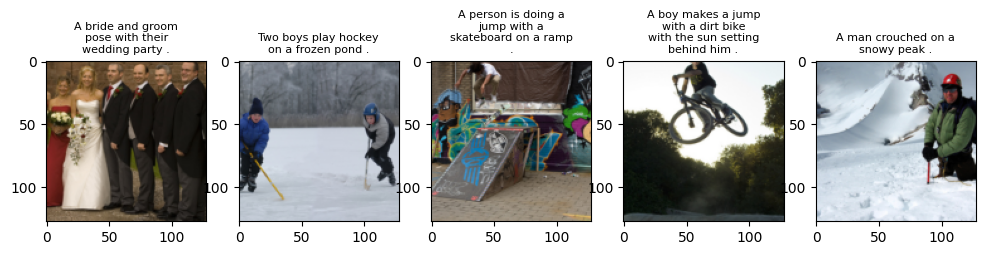

In [ ]:
np.random.seed(123)

random_indices = np.random.choice(len(val_dataset_vqvae_3), 5)

fig, axes = plt.subplots(1, 5, figsize=(12,6))

for i, ax in zip(random_indices, axes):
  img, caption = val_dataset_vqvae_3[i]
  wrapped_caption = "\n".join(textwrap.wrap(caption, width=20))
  ax.imshow(img.permute(1,2,0))
  ax.set_title(f"{wrapped_caption}", fontsize=8)

plt.show()

In [ ]:
samples = torch.stack([val_dataset_vqvae_3[int(i)][0] for i in random_indices], dim=0)

## **Image Tokenizer (VQ-VAE)**

Following implementation downsamples and upsamples by factor of 4.

In [ ]:
class VQ3(nn.Module):
  def __init__(self, latent_dim, k, normalize_codebook, decay=0.99): # k = number of discrete vectors or size of codebook
    super().__init__()
    self.k = k
    self.latent_dim = latent_dim
    self.normalize_codebook = normalize_codebook
    self.register_buffer("moving_sum", torch.zeros(k, latent_dim))
    self.register_buffer("moving_count", torch.zeros(k))
    self.register_buffer("codebook", torch.zeros(k, latent_dim))
    self.register_buffer("initialized", torch.tensor(False))
    self.register_buffer("decay", torch.tensor(decay))

  def forward(self, z_e, training):
    B, C, H, W = z_e.shape
    ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
    if not self.initialized:
      ze_flatten = ze_permute.reshape(-1, C)
      if ze_flatten.shape[0] < self.k:
        indices = torch.randint(0, ze_flatten.shape[0], (self.k,))
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)
      else:
        indices = torch.randperm(ze_flatten.shape[0])[:self.k]
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)

    if self.normalize_codebook:
      ze_norm = F.normalize(ze_permute, dim=-1)          # (B, H, W, C)
      codebook_norm = F.normalize(self.codebook, dim=-1) # (k, C)

      # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
      cross = ze_norm @ codebook_norm.T # (B, H, W, k)
      z_l2_sq = (ze_norm ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
      e_l2_sq = (codebook_norm ** 2).sum(dim=-1) # (k,)

      discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
      z_q = codebook_norm[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)
    else:
      # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
      cross = ze_permute @ self.codebook.T # (B, H, W, k)
      z_l2_sq = (ze_permute ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
      e_l2_sq = (self.codebook ** 2).sum(dim=-1) # (k,)

      discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
      z_q = self.codebook[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)

    # EMA codebook update
    if training:
      n_t = torch.zeros(self.k, device=z_e.device)
      codes_flatten = discrete_codes.reshape(-1)
      n_t.scatter_add_(0, codes_flatten, torch.ones(codes_flatten.shape, device=z_e.device)) # current code-wise utilization count
      self.moving_count.copy_(self.moving_count * self.decay + n_t * (1 - self.decay))
      ze_flatten = ze_permute.reshape(-1, C)
      current_code_sum = torch.zeros_like(self.moving_sum)
      # for i in range(self.k):
      #   assigned_indices = torch.where(codes_flatten == i)[0]
      #   if assigned_indices.shape[0] > 0:
      #     assigned_ze = ze_flatten[assigned_indices]
      #     m_i = assigned_ze.sum(0)
      #     current_code_sum[i] = m_i
      current_code_sum.scatter_add_(0, codes_flatten.unsqueeze(-1).expand(-1, C), ze_flatten)
      self.moving_sum.copy_(self.moving_sum * self.decay + current_code_sum * (1 - self.decay))
      safe_count = self.moving_count.unsqueeze(-1).clamp(min=1e-6)
      self.codebook.data.copy_(self.moving_sum / safe_count)
      if self.normalize_codebook:
        self.codebook.data.copy_(F.normalize(self.codebook.data, dim=-1))

    return z_q, discrete_codes

In [ ]:
class ResidualBlock3(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 1),
        )

    def forward(self, x):
        return x + self.block(x)

class Encoder3(nn.Module):
    def __init__(self, in_channels, hidden, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 4, stride=2, padding=1),
            nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),
            # nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),
            ResidualBlock3(hidden),
            ResidualBlock3(hidden),
            nn.Conv2d(hidden, latent_dim, 1),  # project to codebook dim
        )

    def forward(self, x):
        return self.net(x)

class Decoder3(nn.Module):
    def __init__(self, latent_dim, hidden, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_dim, hidden, 1),  # project back from codebook dim
            ResidualBlock3(hidden),
            ResidualBlock3(hidden),
            # nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),
            nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),
            nn.ConvTranspose2d(hidden, out_channels, 4, stride=2, padding=1),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class VQVAE3(nn.Module):
  def __init__(self, in_channels, out_channels, latent_dim, hidden, k, normalize_codebook, decay=0.99):
    super().__init__()
    self.encoder = Encoder3(in_channels, hidden, latent_dim)
    self.decoder = Decoder3(latent_dim, hidden, out_channels)
    self.vq_layer = VQ3(latent_dim, k, normalize_codebook, decay=decay)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x, training=False):
    z_e = self.encoder(x)
    z_q, discrete_codes = self.vq_layer(z_e, training)
    decoder_inp = z_e + (z_q - z_e).detach() # straight through estimator, the effective value for the forward pass is z_q only but the gradients flow to z_e
    reconst = self.sigmoid(self.decoder(decoder_inp))

    return reconst, z_e, z_q, discrete_codes

### Training

In [ ]:
def calc_batch_loss(model, x, device, training, percep_loss_fn, lambda_=0.1, beta=0.25):
  x = x.to(device)
  reconst, z_e, z_q, discrete_codes = model(x, training)
  x_scaled = x * 2 - 1
  reconst_scaled = reconst * 2 - 1
  percep_loss = lambda_ * percep_loss_fn(x_scaled, reconst_scaled).mean()
  l_1 = nn.functional.binary_cross_entropy(reconst, x)
  ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
  zq_permute = torch.permute(z_q, (0, 2, 3, 1)) # (B, H, W, C)
  l_3 = (beta * torch.norm(ze_permute - zq_permute.detach(), dim=-1) ** 2).mean()
  loss = l_1 + l_3 + percep_loss

  return loss, l_1, l_3, percep_loss, discrete_codes

In [ ]:
def evaluate(loader, model, device, percep_loss_fn, max_batch, k, lambda_=0.1):
  total_loss = 0
  total_l1_loss, total_l3_loss, total_percep_loss = 0, 0, 0
  all_codes = []
  if max_batch is None:
    max_batch = len(loader)
  elif max_batch <= 0:
    return float("nan")
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        loss, l_1, l_3, percep_loss, discrete_codes = calc_batch_loss(model, x, device, training=False, percep_loss_fn=percep_loss_fn, lambda_=lambda_)
      total_loss += loss.item()
      total_l1_loss += l_1.item()
      total_l3_loss += l_3.item()
      total_percep_loss += percep_loss.item()
      all_codes.append(discrete_codes.reshape(-1))
    else:
      break
  all_codes = torch.cat(all_codes, dim=0)

  return total_loss/max_batch, total_l1_loss/max_batch, total_l3_loss/max_batch, total_percep_loss/max_batch, all_codes.unique().numel() / k

In [ ]:
def reconstruct(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      reconst, _, _, _ = model(x, training=False)
    return reconst.cpu()

In [ ]:
def train_vqvae(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    percep_loss_fn,
    lambda_=0.1,
    epochs=20,
    eval_interval=500,
    k=512,
    samples=None
):
    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    global_step = -1

    # logs
    train_losses, val_losses = [], []
    train_l1_losses, val_l1_losses = [], []
    train_l3_losses, val_l3_losses = [], []
    train_percep_losses, val_percep_losses = [], []
    train_codebook, val_codebook = [], []

    t_start = time.time()
    model.train()

    for epoch in range(epochs):
        for x, _ in train_loader:
            optimizer.zero_grad()

            loss, _, _, _, _ = calc_batch_loss(
                model, x, device, training=True, percep_loss_fn=percep_loss_fn, lambda_=lambda_
            )
            loss.backward()
            optimizer.step()

            global_step += 1

            if global_step % eval_interval == 0:
                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done
                eta_minutes = (elapsed / steps_done) * steps_left / 60

                model.eval()

                train_loss, train_l1, train_l3, train_percep_loss, train_cu = evaluate(
                    train_loader, model, device, percep_loss_fn, max_batch=20, k=k, lambda_=lambda_
                )
                val_loss, val_l1, val_l3, val_percep_loss, val_cu = evaluate(
                    val_loader, model, device, percep_loss_fn, max_batch=None, k=k, lambda_=lambda_
                )

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3={train_l3:.4f}, percep_loss={train_percep_loss:.4f})")
                print(f"\tCodebook: {train_cu:.2f}")
                print(f"\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3={val_l3:.4f}, percep_loss={val_percep_loss:.4f})")
                print(f"\tCodebook: {val_cu:.2f}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

                # store logs
                train_losses.append(train_loss)
                val_losses.append(val_loss)

                train_l1_losses.append(train_l1)
                val_l1_losses.append(val_l1)

                train_l3_losses.append(train_l3)
                val_l3_losses.append(val_l3)

                train_percep_losses.append(train_percep_loss)
                val_percep_losses.append(val_percep_loss)

                train_codebook.append(train_cu)
                val_codebook.append(val_cu)

                # reconstruction viz
                if samples is not None:
                    reconst = reconstruct(model, samples, device)

                    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
                    for i in range(5):
                        axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                        axes[0, i].axis("off")

                        axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                        axes[1, i].axis("off")

                    plt.tight_layout()
                    plt.show()

                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_l1": train_l1_losses,
        "val_l1": val_l1_losses,
        "train_l3": train_l3_losses,
        "val_l3": val_l3_losses,
        "train_percep_loss": train_percep_losses,
        "val_percep_loss": val_percep_losses,
        "train_codebook": train_codebook,
        "val_codebook": val_codebook
    }

In [ ]:
def collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    captions = [item[1] for item in batch]  # just a list of strings
    return images, captions

In [ ]:
train_loader_vqvae_3 = DataLoader(
    train_dataset_vqvae_3,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader_vqvae_3 = DataLoader(
    val_dataset_vqvae_3,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
len(train_loader_vqvae_3), len(val_loader_vqvae_3)

(405, 102)

In [ ]:
for imgs, caps in val_loader_vqvae_3:
  print(imgs.shape)
  print(caps)
  break

torch.Size([16, 3, 128, 128])
['A brown , black and white dog is on a obstacle course .', 'A person in the distance hikes among hoodoos with stars visible in the sky .', 'A man holding the hand of another man who has a tattoo on his arm .', 'One very fat sumo wrestler wrestles with a thinner wrestler while an umpire dressed in green watches .', 'A black dog in the middle of running or leaping .', 'A boy in a shirt and tie jumps off a staircase .', 'A basketball player tries to aim for the goal while being blocked by other players .', 'Two dirt bike riders in midair .', 'A female softball player pitches the ball .', 'A girl flies through the air as a man stands with his arms outstretched .', 'A man and his dog in the mountains .', 'A bunch of football players in blue .', 'A white dog catching a soccer ball midair .', 'A big dog running through the water', 'Dogs in a race .', 'A bunch of children in white are doing a dance routine while another person jumps rope .']


In [ ]:
torch.manual_seed(123)

lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()
model5 = VQVAE3(in_channels=3, out_channels=3, latent_dim=8, hidden=128, k=512, normalize_codebook=False).to(device)
optimizer5 = torch.optim.Adam(model5.parameters(), lr=1e-4)

logs5 = train_vqvae(
    model=model5,
    train_loader=train_loader_vqvae_3,
    val_loader=val_loader_vqvae_3,
    optimizer=optimizer5,
    device=device,
    percep_loss_fn=lpips_model,
    lambda_=1,
    epochs=8,
    eval_interval=500,
    k=512,
    samples=samples
)

In [ ]:
torch.save(model5.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen_flickr8k_2.pt")

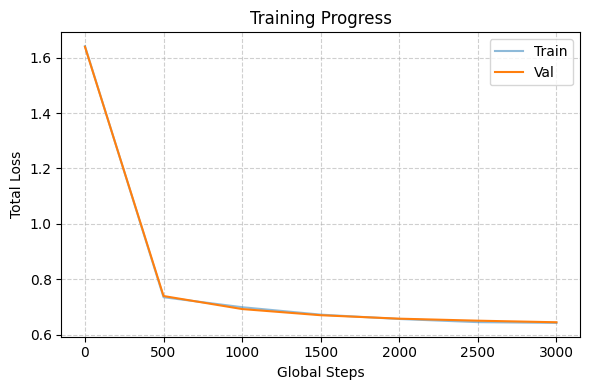

In [ ]:
plot_training_results(logs5["train_loss"], logs5["val_loss"], 500, title="Training Progress", y_title="Total Loss")

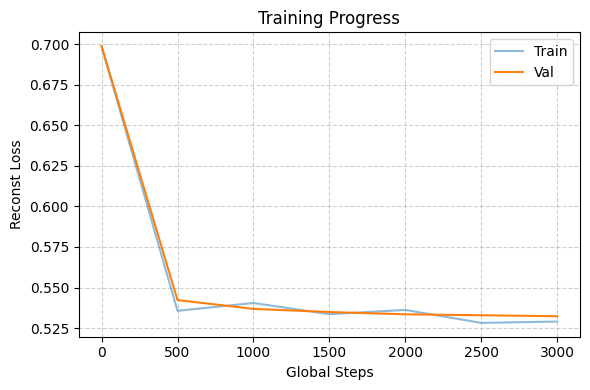

In [ ]:
plot_training_results(logs5["train_l1"], logs5["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

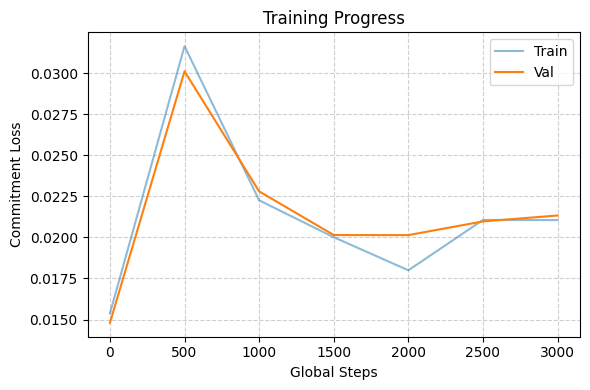

In [ ]:
plot_training_results(logs5["train_l3"], logs5["val_l3"], 500, title="Training Progress", y_title="Commitment Loss")

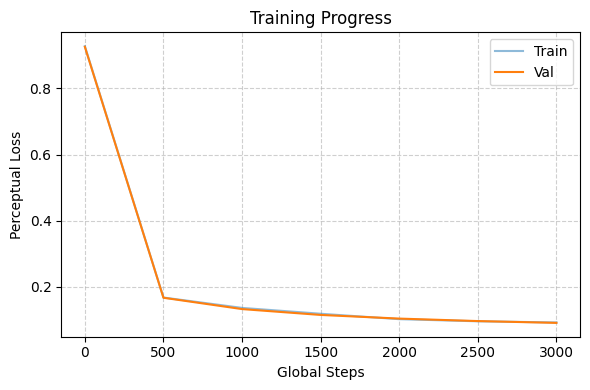

In [ ]:
plot_training_results(logs5["train_percep_loss"], logs5["val_percep_loss"], 500, title="Training Progress", y_title="Perceptual Loss")

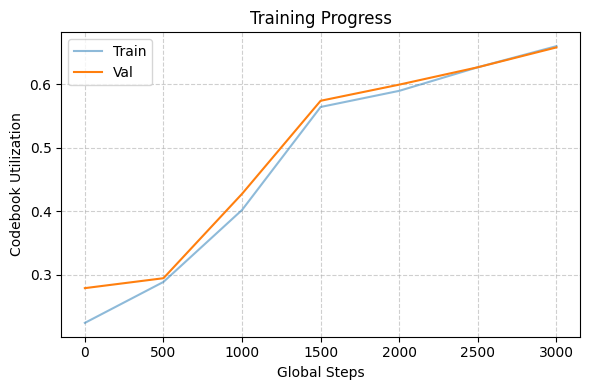

In [ ]:
plot_training_results(logs5["train_codebook"], logs5["val_codebook"], 500, title="Training Progress", y_title="Codebook Utilization")

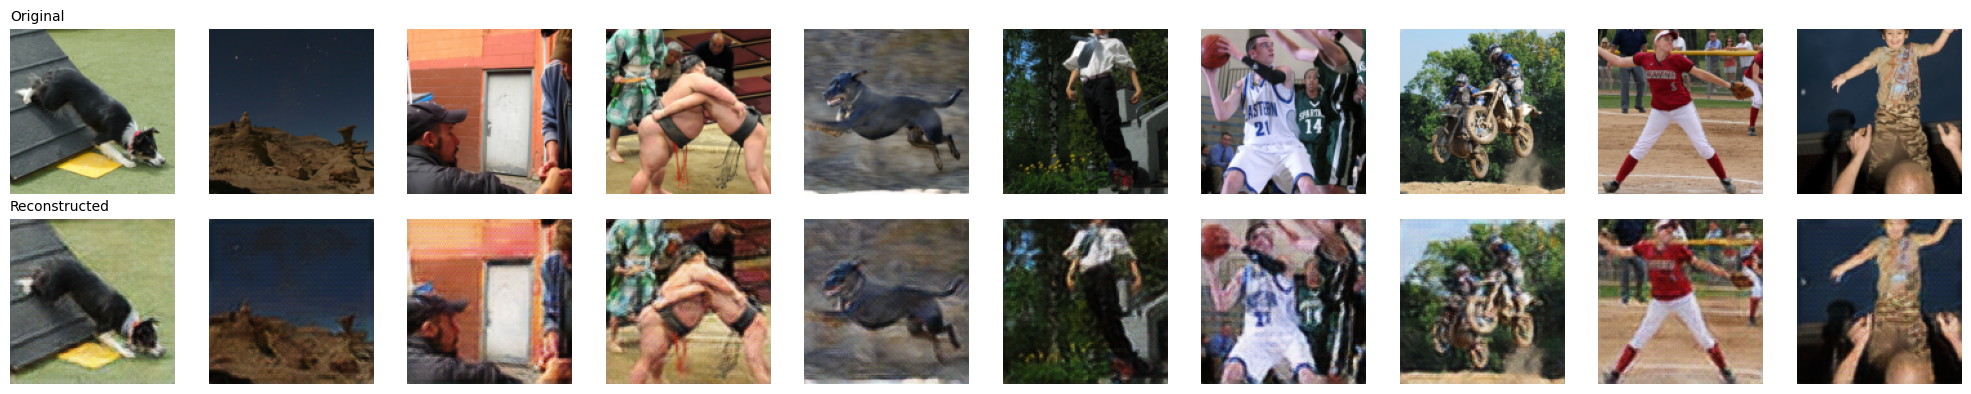

In [ ]:
vqvae = VQVAE3(in_channels=3, out_channels=3, latent_dim=8, hidden=128, k=512, normalize_codebook=False)
vqvae.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen_flickr8k_2.pt"))
vqvae.to(device)

plot_generated_vs_original(vqvae, val_loader_vqvae_3, device=device)

## **Prior Training**

In [ ]:
vqvae = VQVAE3(in_channels=3, out_channels=3, latent_dim=8, hidden=128, k=512, normalize_codebook=False)
vqvae.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen_flickr8k_2.pt", map_location="cpu"))
vqvae.to(device)

VQVAE3(
  (encoder): Encoder3(
    (net): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (2): ResidualBlock3(
        (block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (3): ResidualBlock3(
        (block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (4): Conv2d(128, 8, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (decoder): Decoder3(
    (net): Sequential(
      (0): Conv2d(8, 128, kernel_size=(1, 1), stride=(1, 1))
      (1): ResidualBlock3(
        (block): Sequential(
          (0): ReLU(

In [ ]:
enc = tk.get_encoding("gpt2")

tokenizer = tk.Encoding(
    name="gpt2_custom",
    pat_str=enc._pat_str,
    mergeable_ranks=enc._mergeable_ranks,
    special_tokens={
        **enc._special_tokens,
        "<|startoftext|>": enc.max_token_value + 1,  # new unique ID
        "<|pad|>": enc.max_token_value + 2,  # new unique ID
        "<|startofimage|>": enc.max_token_value + 3  # new unique ID
    }
)

In [ ]:
tokenizer.special_tokens_set

{'<|endoftext|>', '<|pad|>', '<|startofimage|>', '<|startoftext|>'}

In [ ]:
PAD_ID = tokenizer._special_tokens["<|pad|>"]
SOI_ID = tokenizer._special_tokens["<|startofimage|>"]
BOS_ID = tokenizer._special_tokens["<|startoftext|>"]

In [ ]:
tokenizer.n_vocab

50260

In [ ]:
class TokenizedTextImageDataset(Dataset):
  def __init__(self, model, tokenizer, loader, device):
    self.tokenized_images = []
    self.tokenized_text = []
    model.to(device)
    for x, y in tqdm(loader, desc="Generating codes"):
      x = x.to(device)
      B = x.shape[0]
      with torch.no_grad():
        z_e = model.encoder(x)
        z_q, discrete_codes = model.vq_layer(z_e, training=False)
      discrete_codes = discrete_codes.reshape(B, -1).cpu()
      self.tokenized_images.extend(discrete_codes.tolist())
      for caption in y:
        tokens = tokenizer.encode(caption.lower())
        self.tokenized_text.append(tokens)

  def __len__(self):
    return len(self.tokenized_images)

  def __getitem__(self, idx):
    return self.tokenized_images[idx], self.tokenized_text[idx]

In [ ]:
train_dataset_prior_3 = TokenizedTextImageDataset(vqvae, tokenizer, train_loader_vqvae_3, device)
val_dataset_prior_3 = TokenizedTextImageDataset(vqvae, tokenizer, val_loader_vqvae_3, device)

Generating codes: 100%|██████████| 102/102 [00:07<00:00, 13.33it/s]


In [ ]:
torch.save({
    "tokenized_images": train_dataset_prior_3.tokenized_images,
    "tokenized_text": train_dataset_prior_3.tokenized_text
}, "/content/drive/My Drive/GenAI/Data/train_dataset_prior_3.pt")

torch.save({
    "tokenized_images": val_dataset_prior_3.tokenized_images,
    "tokenized_text": val_dataset_prior_3.tokenized_text
}, "/content/drive/My Drive/GenAI/Data/val_dataset_prior_3.pt")

In [ ]:
class LoadTokenizedTextImageDataset(Dataset):
    def __init__(self, tokenized_images, tokenized_text):
        self.tokenized_images = tokenized_images
        self.tokenized_text = tokenized_text

    def __len__(self):
        return len(self.tokenized_images)

    def __getitem__(self, idx):
        return self.tokenized_images[idx], self.tokenized_text[idx]

In [ ]:
train_data = torch.load("/content/drive/My Drive/GenAI/Data/train_dataset_prior_3.pt")

train_dataset_prior_3 = LoadTokenizedTextImageDataset(
    train_data["tokenized_images"],
    train_data["tokenized_text"]
)

val_data = torch.load("/content/drive/My Drive/GenAI/Data/val_dataset_prior_3.pt")

val_dataset_prior_3 = LoadTokenizedTextImageDataset(
    val_data["tokenized_images"],
    val_data["tokenized_text"]
)

In [ ]:
len(train_dataset_prior_3), len(val_dataset_prior_3)

(6472, 1619)

In [ ]:
max_len_1 = 0
for img, text in train_dataset_prior_3:
  max_len_1 = max(max_len_1, len(text))
print(f"Train dataset max text seq length: {max_len_1}")

max_len_2 = 0
for img, text in val_dataset_prior_3:
  max_len_2 = max(max_len_2, len(text))
print(f"Val dataset max text seq length: {max_len_2}")

Train dataset max text seq length: 38
Val dataset max text seq length: 32


In [ ]:
def collator(batch, text_vocab_size, max_text_tokens, sot_id=50257, pad_id=50258, soi_id=50259):
  input_text_tokens = []
  input_image_tokens = []
  target_text_tokens = []
  target_image_tokens = []
  for img_tokens, text_tokens in batch:
    text_tokens = [sot_id] + text_tokens
    if len(text_tokens) > max_text_tokens:
      new_text_tokens = text_tokens[:max_text_tokens]
    else:
      new_text_tokens = text_tokens + [pad_id] * (max_text_tokens - len(text_tokens))
    img_tokens = [text_vocab_size+img_code for img_code in img_tokens]
    new_image_tokens = [soi_id] + img_tokens

    input_text_tokens.append(new_text_tokens)
    input_image_tokens.append(new_image_tokens[:-1])

    target_text_tokens.append(new_text_tokens[1:] + [new_image_tokens[0]])
    target_image_tokens.append(new_image_tokens[1:])


  input_text_tokens = torch.tensor(input_text_tokens)
  input_image_tokens = torch.tensor(input_image_tokens)
  target_text_tokens = torch.tensor(target_text_tokens)
  target_image_tokens = torch.tensor(target_image_tokens)
  inputs = {"text_tokens": input_text_tokens, "image_tokens": input_image_tokens}
  targets = {"text_tokens": target_text_tokens, "image_tokens": target_image_tokens}

  return inputs, targets

### Transformer

In [ ]:
PRIOR_CONFIG_3 = {
    'emb_size':1024, # increased emb size to 1024 from 768 for this exp
    'context_length':32, # trying context length of 32 instead of 256
    'text_vocab_size':tokenizer.n_vocab,
    "codebook_size": 512,
    'num_heads':16, # from 12 to 16 for this exp
    'num_layers':6, # reduced layers from 12 to 6 for this exp
    'drop_rate':0.1,
    'grid_size': (32, 32),
    'row_extension': 33, # for 32 x 32 grid, the row extension of 33 will allow to attend the same column from prev row
    'kernel_size': 11, # kernel size of convolution attention mask
    'cfg_drop': 0.1,
    'qkv_bias': False,
}

PRIOR_CONFIG_3["total_vocab_size"] = PRIOR_CONFIG_3["text_vocab_size"] + PRIOR_CONFIG_3["codebook_size"]

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, mask_type, grid_size, row_extension, kernel_size, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        self._create_mask(
            mask_type,
            context_length,
            grid_size=grid_size,
            row_extension=row_extension,
            kernel_size=kernel_size,
    ))

  def _create_mask(
      self,
      mask_type,
      text_len,
      grid_size=(32, 32),
      row_extension=32,
      kernel_size=11,
      use_soi=True,
  ):
      H, W = grid_size
      image_len = H * W
      soi_tokens = 1 if use_soi else 0
      total_len = text_len + soi_tokens + image_len
      mask = torch.zeros(
          (total_len, total_len),
          dtype=torch.bool
      )
      # =========================================================
      # TEXT TOKENS
      # Standard causal mask
      # =========================================================
      for i in range(text_len):
          mask[i, : i + 1] = True
      # =========================================================
      # SOI TOKEN
      # =========================================================
      if use_soi:
          soi_idx = text_len
          # SOI attends to all previous text tokens
          mask[soi_idx, : text_len + 1] = True
          image_offset = text_len + 1
      else:
          soi_idx = None
          image_offset = text_len
      # =========================================================
      # IMAGE TOKENS
      # =========================================================
      for img_idx in range(image_len):
          q = image_offset + img_idx
          # -----------------------------------------------------
          # image tokens attend to all text tokens
          # -----------------------------------------------------
          mask[q, :text_len] = True
          # -----------------------------------------------------
          # attend to SOI token
          # -----------------------------------------------------
          if use_soi:
              mask[q, soi_idx] = True
          row = img_idx // W
          col = img_idx % W
          # =====================================================
          # ROW ATTENTION
          # =====================================================
          if mask_type == "row":
              start = max(0, img_idx - row_extension)
              for prev in range(start, img_idx + 1):
                  mask[q, image_offset + prev] = True
          # =====================================================
          # COLUMN ATTENTION
          # =====================================================
          elif mask_type == "column":
              for prev in range(img_idx + 1):
                  prev_row = prev // W
                  prev_col = prev % W
                  same_col = (prev_col == col)
                  within_extent = (
                      row - prev_row
                  ) <= row_extension
                  if same_col and within_extent:
                      mask[q, image_offset + prev] = True
          # =====================================================
          # CONVOLUTION ATTENTION
          # WITH WRAPAROUND BEHAVIOR
          # =====================================================
          elif mask_type == "convolution":
              radius = kernel_size // 2
              for prev in range(img_idx + 1):
                  prev_row = prev // W
                  prev_col = prev % W
                  dr = row - prev_row
                  # horizontal wraparound distance
                  dc = min(
                      abs(col - prev_col),
                      W - abs(col - prev_col)
                  )
                  inside_kernel = (
                      abs(dr) <= radius
                      and dc <= radius
                  )
                  if inside_kernel:
                      mask[q, image_offset + prev] = True
          else:
              raise ValueError(
                  f"Unknown mask type: {mask_type}"
              )
      return ~mask

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    attention_scores = queries @ keys.transpose(2,3)
    attention_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self, emb_size):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_size))
    self.shift = nn.Parameter(torch.zeros(emb_size))

  def forward(self, x):
    mean = x.mean(keepdim=True, dim=-1)
    variance = x.var(keepdim=True, dim=-1, unbiased=False)
    norm_x = (x - mean)/torch.sqrt(variance + self.eps)
    return self.scale * norm_x + self.shift

In [ ]:
class GeLU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
    ))

In [ ]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_size'], 4 * cfg['emb_size']),
        GeLU(),
        nn.Linear(4 * cfg['emb_size'], cfg['emb_size'])
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg, mask_type):
    super().__init__()
    self.mha = MultiHeadAttention(cfg['emb_size'], cfg['emb_size'], cfg['context_length'], cfg['drop_rate'], cfg['num_heads'], mask_type, cfg['grid_size'], cfg['row_extension'], cfg['kernel_size'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.ffn = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [ ]:
class Prior(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['total_vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.null_emb_layer = nn.Embedding(1, cfg['emb_size'])
    self.row_emb_layer = nn.Embedding(cfg['grid_size'][0], cfg['emb_size'])
    self.col_emb_layer = nn.Embedding(cfg['grid_size'][1] + 1, cfg['emb_size']) # the 0th col_emb is for startofimage token only and not for any of the image tokens belonging to the zeroth column in 2d view
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg, self._mask_type(i, cfg['num_layers'])) for i in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['total_vocab_size'], bias=False)
    self.num_rows = cfg['grid_size'][0]
    self.num_cols = cfg['grid_size'][1]
    self.context_length = cfg['context_length']
    self.cfg_drop = cfg['cfg_drop']

  def _mask_type(self, i, num_layers):
    if i==num_layers-1:
      return 'convolution'
    elif (i-1)%4==0:
      return 'column'
    else:
      return 'row'

  def forward(self, input, training=False):
    text_tokens = input.get('text_tokens', None) # text_tokens will be None for unconditional inference
    image_tokens = input.get('image_tokens', None) # soi token belongs to image_tokens seq
    batch_size, num_img_tokens = image_tokens.shape
    null_emb = self.null_emb_layer(torch.tensor(0).to(image_tokens.device))
    if text_tokens is None: # during unconditional inference
      text_token_emb = null_emb.unsqueeze(0).unsqueeze(0).expand(batch_size, self.context_length, -1)
    else:
      text_token_emb = self.token_emb_layer(text_tokens)
    _, num_text_tokens, _ = text_token_emb.shape
    pos_emb = self.pos_emb_layer(
        torch.arange(num_text_tokens, device=image_tokens.device)
    )
    if training:
      drop_ind = torch.rand(batch_size) < self.cfg_drop
      text_token_emb[drop_ind] = null_emb.unsqueeze(0).expand(num_text_tokens, -1)
    text_emb = text_token_emb + pos_emb
    image_token_emb = self.token_emb_layer(image_tokens)
    # row_emb = self.row_emb_layer(
    #     torch.arange((num_img_tokens-1)//self.num_rows, device=image_tokens.device)
    # )
    # cols_to_use = min(num_img_tokens-1, self.num_cols) + 1 # for +1 for soi token
    # col_emb = self.col_emb_layer(
    #     torch.arange(cols_to_use, device=image_tokens.device)
    # )
    # image_token_emb[0] = image_token_emb[0] + row_emb[0] + col_emb[0] # soi separately
    # row_emb_repeat = torch.repeat_interleave(row_emb, self.num_cols, dim=0)[:num_img_tokens-1] # excluded soi since it is already done
    # col_emb_repeat = torch.tile(col_emb[1:], ((num_img_tokens-1) // (cols_to_use - 1) + 1,))[:num_img_tokens-1] # excluded soi since it is already done
    # image_token_emb[1:] = image_token_emb[1:] + row_emb_repeat + col_emb_repeat
    # for each image token (excluding SOI), compute which row it belongs to
    image_token_emb[:,0] = image_token_emb[:,0] + self.row_emb_layer(torch.tensor(0, device=image_tokens.device)) + self.col_emb_layer(torch.tensor(0, device=image_tokens.device)) # soi separately
    img_indices = torch.arange(num_img_tokens - 1, device=image_tokens.device)
    row_indices = img_indices // self.num_cols   # shape (num_img_tokens-1,)
    col_indices = img_indices % self.num_cols    # shape (num_img_tokens-1,)
    row_emb = self.row_emb_layer(row_indices)   # (num_img_tokens-1, emb_size)
    col_emb = self.col_emb_layer(col_indices + 1)  # +1 to skip the SOI col slot
    image_token_emb[:,1:] = image_token_emb[:,1:] + row_emb + col_emb
    x = torch.cat((text_emb, image_token_emb), dim=1)
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits

### Training

In [ ]:
def ce_batch_loss_calc(input_batch, target_batch, model, device, cfg, training=False):
  input_batch = {k:v.to(device) for k,v in input_batch.items()}
  target_batch = {k:v.to(device) for k,v in target_batch.items()}
  logits_batch = model(input_batch, training=training)
  # loss_text = torch.nn.functional.cross_entropy(logits_batch[:, :cfg['context_length'], :].flatten(0, 1), target_batch['text_tokens'].flatten()) / cfg['context_length'] # dividing to normalize wrt text token occurence
  # loss_image = torch.nn.functional.cross_entropy(logits_batch[:, cfg['context_length']:, :].flatten(0, 1), target_batch['image_tokens'].flatten()) / (cfg['grid_size'][0] * cfg['grid_size'][1]) # dividing to normalize wrt image token occurence
  # correct implementation
  loss_text = torch.nn.functional.cross_entropy(logits_batch[:, :cfg['context_length'], :].flatten(0, 1), target_batch['text_tokens'].flatten(), ignore_index=PAD_ID, reduction='mean')
  loss_image = torch.nn.functional.cross_entropy(logits_batch[:, cfg['context_length']:, :].flatten(0, 1), target_batch['image_tokens'].flatten(), reduction='mean')
  loss = 0.125 * loss_text + 0.875 * loss_image

  return loss

In [ ]:
def calc_loss_dataloader(loader, model, device, cfg, num_batches=None):
  total_loss = 0
  if len(loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(loader)
  elif num_batches < 0:
    num_batches = float('nan')
  else:
    num_batches = min(num_batches, len(loader))

  for i, (x, y) in enumerate(loader):
    if i < num_batches:
      loss = ce_batch_loss_calc(x, y, model, device, cfg, training=False)
      total_loss += loss.item()
    else:
      break

  return total_loss/num_batches

In [ ]:
def evaluate_prior(model, train_loader, val_loader, device, cfg, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_dataloader(train_loader, model, device, cfg, eval_iter)
    val_loss = calc_loss_dataloader(val_loader, model, device, cfg, eval_iter)
  model.train()

  return train_loss, val_loss

In [ ]:
def generate(model, tokenizer, inputs, max_gen_tokens, cfg_weight, temperature=0.0, top_k=None, eos_id=None): # cfg_weight -> classifier-free guidance
  B, N = inputs['text_tokens'].shape
  finished = torch.zeros(B, dtype=torch.bool, device=inputs['text_tokens'].device)
  for i in range(max_gen_tokens):
    with torch.no_grad():
      cond_inp = inputs
      logits_c = model(cond_inp, training=False)[:, -1, :]

      uncond_inp = {'text_tokens': None, 'image_tokens': inputs['image_tokens']}
      logits_u = model(uncond_inp, training=False)[:, -1, :]
    logits = logits_u + cfg_weight * (logits_c - logits_u) # classifier free guidance for boosting logits for tokens which are caption or condition relevant

    logits[:,:tokenizer.n_vocab] = torch.tensor(float('-inf'), device=logits.device) # this line ensures that only image tokens are generated

    if top_k is not None:
      top_logits, top_idx = torch.topk(logits, top_k)
      logits = torch.where(
          condition=logits<top_logits[:,-1, None],
          input=torch.tensor(float('-inf'), device=logits.device),
          other=logits
      )

    if temperature > 0:
      scaled_logits = logits / temperature
      probs = torch.softmax(scaled_logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)

    if eos_id is not None:
        finished |= (idx_next.squeeze(-1) == eos_id)
        idx_next[finished] = eos_id

    inputs['image_tokens'] = torch.cat((inputs['image_tokens'], idx_next), dim=1)

    if finished.all():
        break

  return inputs['image_tokens']

In [ ]:
def reconstruct_from_prior(vqvae, img_tokens, device):
  vqvae.eval()
  with torch.no_grad():
    img_tokens = img_tokens.to(device) # (B, H, W)
    codebook_latents = vqvae.vq_layer.codebook[img_tokens].permute(0, 3, 1, 2) # (B, emb_dim, H, W)
    reconst = vqvae.sigmoid(vqvae.decoder(codebook_latents))
  return reconst

In [ ]:
def tokenize_text(text, tokenizer, max_text_tokens):
  tokens = tokenizer.encode(text.lower())
  tokens = [BOS_ID] + tokens
  if len(tokens) > max_text_tokens:
    new_tokens = tokens[:max_text_tokens]
  else:
    new_tokens = tokens + [PAD_ID] * (max_text_tokens - len(tokens))
  return new_tokens

In [ ]:
def generate_and_render_sample(model, vqvae, tokenizer, cfg, cfg_weight, text_prompts, device, temperature=0.7):
  model.eval()
  input_text_tokens = []
  for text in text_prompts:
    text_tokens = tokenize_text(text, tokenizer, cfg['context_length'])
    input_text_tokens.append(text_tokens)
  input_image_tokens = [[SOI_ID] for i in range(len(text_prompts))]
  inputs = {
      'text_tokens': torch.tensor(input_text_tokens, device=device),
      'image_tokens': torch.tensor(input_image_tokens, device=device)
  }
  with torch.no_grad():
    op_tokens = generate(
        model,
        inputs=inputs,
        tokenizer=tokenizer,
        max_gen_tokens=1024,
        cfg_weight=cfg_weight,
        temperature=temperature,
        top_k=25
    )
  print(op_tokens[:,:50])
  print(op_tokens.unique().numel())
  img_tokens = op_tokens[:,1:].reshape(-1, cfg['grid_size'][0], cfg['grid_size'][1]) # remove soi token and reshape to 32 * 32 grid expected by vqvae decoder
  img_tokens = img_tokens - tokenizer.n_vocab # to get back original image codes
  reconst = reconstruct_from_prior(vqvae, img_tokens, device).cpu()

  fig, axes = plt.subplots(1, len(text_prompts), figsize=(16, 6))
  for i in range(len(text_prompts)):
    axes[i].imshow(torch.permute(reconst[i], (1, 2, 0)))
    axes[i].axis("off")
  plt.tight_layout()
  plt.show()

In [ ]:
import time

def train_model_simple(
    model,
    vqvae,
    cfg,
    train_loader,
    val_loader,
    device,
    optimizer,
    tokenizer,
    epochs,
    eval_freq,
    eval_iter,
    text_prompts,
    cfg_weight
):
    train_loss_arr, val_loss_arr, track_tokens_seen, grad_norms_arr = [], [], [], []
    global_step, tokens_seen = -1, 0

    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    t_start = time.time()

    for epoch in range(epochs):
        model.train()

        for x, y in train_loader:
            optimizer.zero_grad()

            train_loss = ce_batch_loss_calc(
                x, y, model, device, cfg, training=True
            )

            train_loss.backward()

            # global grad norm
            total_norm = 0.0

            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.detach().data.norm(2)
                    total_norm += param_norm.item() ** 2

            total_norm = total_norm ** 0.5
            grad_norms_arr.append(total_norm)

            optimizer.step()

            tokens_seen += (
                x['text_tokens'].numel()
                + x['image_tokens'].numel()
            )

            global_step += 1

            if global_step % eval_freq == 0:

                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done

                eta_minutes = (
                    (elapsed / steps_done) * steps_left
                ) / 60

                train_loss, val_loss = evaluate_prior(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    cfg,
                    eval_iter
                )

                train_loss_arr.append(train_loss)
                val_loss_arr.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f}")
                print(f"\tVal Loss:   {val_loss:.4f}")
                print(f"\tTokens Seen: {tokens_seen}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

            if global_step % (eval_freq * 5) == 0: # if eval_freq=100 then generation will happen every 5000 steps
                generate_and_render_sample(
                    model,
                    vqvae,
                    tokenizer,
                    cfg,
                    cfg_weight,
                    text_prompts,
                    device
                )
                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return train_loss_arr, val_loss_arr, track_tokens_seen, grad_norms_arr

In [ ]:
prior_collate_fn = partial(collator, text_vocab_size=tokenizer.n_vocab, max_text_tokens=PRIOR_CONFIG_3['context_length'])

train_loader_prior_3 = DataLoader(train_dataset_prior_3, batch_size=8, shuffle=True, num_workers=0, collate_fn=prior_collate_fn)
val_loader_prior_3 = DataLoader(val_dataset_prior_3, batch_size=8, shuffle=False, num_workers=0, collate_fn=prior_collate_fn)

In [ ]:
torch.manual_seed(123)
model6 = Prior(PRIOR_CONFIG_3)
model6.to(device)
optimizer6 = torch.optim.AdamW(model6.parameters(), lr=0.0004, weight_decay=0.1)
text_prompts = [
                  'a black dog in the middle of running or leaping .',
                  'two dirt bike riders in midair .'
                  # 'a cat that is standing on a toilet and next to a sink'
                  # 'some people are flying kites and one male has a red tie on',
                  # 'a work crew repairs a stop in the town.'
                ]
train_losses6, val_losses6, tokens_seen6, grad_norms_arr6 = train_model_simple(model6, vqvae, PRIOR_CONFIG_3, train_loader_prior_3, val_loader_prior_3, device, optimizer6, tokenizer, epochs=15, eval_freq=100, eval_iter=5, text_prompts=text_prompts, cfg_weight=4)

In [ ]:
torch.save(model6.state_dict(), '/content/drive/My Drive/GenAI/Data/text_to_image_prior_model_flickr8k_2.pt')

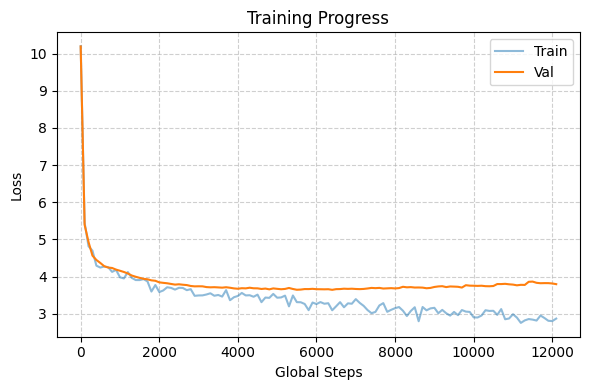

In [ ]:
plot_training_results(train_losses6, val_losses6, 100, title="Training Progress", y_title="Loss")

In [ ]:
all_codes = torch.cat([torch.tensor(train_dataset_prior_3[i][0]) for i in range(len(train_dataset_prior_3))])
counts = torch.bincount(all_codes.flatten().long(), minlength=512)

for code_id, count in enumerate(counts):
    print(f"code {code_id}: {count.item()}")

code 0: 14072
code 1: 20209
code 2: 8085
code 3: 13375
code 4: 8922
code 5: 9201
code 6: 6683
code 7: 8318
code 8: 8473
code 9: 12106
code 10: 38525
code 11: 19605
code 12: 19729
code 13: 10564
code 14: 45518
code 15: 5028
code 16: 22299
code 17: 3935
code 18: 9302
code 19: 29135
code 20: 8875
code 21: 17045
code 22: 12682
code 23: 21855
code 24: 3149
code 25: 14530
code 26: 22320
code 27: 26382
code 28: 4992
code 29: 7286
code 30: 37149
code 31: 32555
code 32: 12466
code 33: 6400
code 34: 8453
code 35: 15309
code 36: 7792
code 37: 15392
code 38: 48228
code 39: 17307
code 40: 38587
code 41: 30667
code 42: 12588
code 43: 20919
code 44: 12129
code 45: 23012
code 46: 15258
code 47: 10012
code 48: 24185
code 49: 11840
code 50: 26
code 51: 0
code 52: 12843
code 53: 0
code 54: 0
code 55: 0
code 56: 0
code 57: 0
code 58: 0
code 59: 0
code 60: 0
code 61: 0
code 62: 18480
code 63: 8057
code 64: 4653
code 65: 0
code 66: 0
code 67: 21004
code 68: 33862
code 69: 0
code 70: 10052
code 71: 0
code 72

In [ ]:
# Global Code Utilization
print(f"codes used: {(counts > 0).sum().item()} / {512}")
print(f"most common: code {counts.argmax().item()} ({counts.max().item()} times)")

print(f"least used (nonzero): code {counts[counts > 0].argmin().item()} {counts[counts > 0].min().item()} times")

codes used: 347 / 512
most common: code 404 (99098 times)
least used (nonzero): code 50 26 times


In [ ]:
# Per-Image Code Utilization
for i in range(5):
      t = torch.tensor(train_dataset_prior_3[i][0])
      print(t.unique().numel(), "unique of", t.numel())

116 unique of 1024
257 unique of 1024
131 unique of 1024
204 unique of 1024
167 unique of 1024


In [ ]:
p = counts.float()
p = p / p.sum()

entropy = -(p[p > 0] * torch.log2(p[p > 0])).sum()
max_entropy = torch.log2(torch.tensor(len(counts), dtype=torch.float))

print(f"Entropy: {entropy:.3f} bits")
print(f"Maximum: {max_entropy:.3f} bits")
print(f"Normalized: {entropy / max_entropy:.3f}")

Entropy: 8.208 bits
Maximum: 9.000 bits
Normalized: 0.912


In [ ]:
prior_model = Prior(PRIOR_CONFIG_3)
prior_model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/text_to_image_prior_model_flickr8k_2.pt", map_location="cpu"))
prior_model.to(device)

Prior(
  (token_emb_layer): Embedding(50772, 1024)
  (pos_emb_layer): Embedding(32, 1024)
  (null_emb_layer): Embedding(1, 1024)
  (row_emb_layer): Embedding(32, 1024)
  (col_emb_layer): Embedding(33, 1024)
  (dropout_layer): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (mha): MultiHeadAttention(
        (w_query): Linear(in_features=1024, out_features=1024, bias=False)
        (w_key): Linear(in_features=1024, out_features=1024, bias=False)
        (w_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GeLU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )

0 sequence
Input Text Seq: tensor([50257,    64,  7586,   837,  2042,   290,  2330,  3290,   318,   319,
          257, 22007,  1781,   764, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258], device='cuda:0')
Target Text Seq: tensor([   64,  7586,   837,  2042,   290,  2330,  3290,   318,   319,   257,
        22007,  1781,   764, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50259], device='cuda:0')
Predicted Text Seq: tensor([   64,   582,  3290,  2042,   837,  2330,  3290,   318, 14284,   262,
         2266,   764,   764,   764,   764,   764,   764,   764,   764,   764,
          764,   764,   764,   764,   764,   257,   764,   257,   764,   764,
          257, 50259], device='cuda:0')
Input Image Seq: tensor([50259, 50620, 50529, 50750, 50684, 50754, 50290, 50452, 50302, 50613,
        50564, 5056

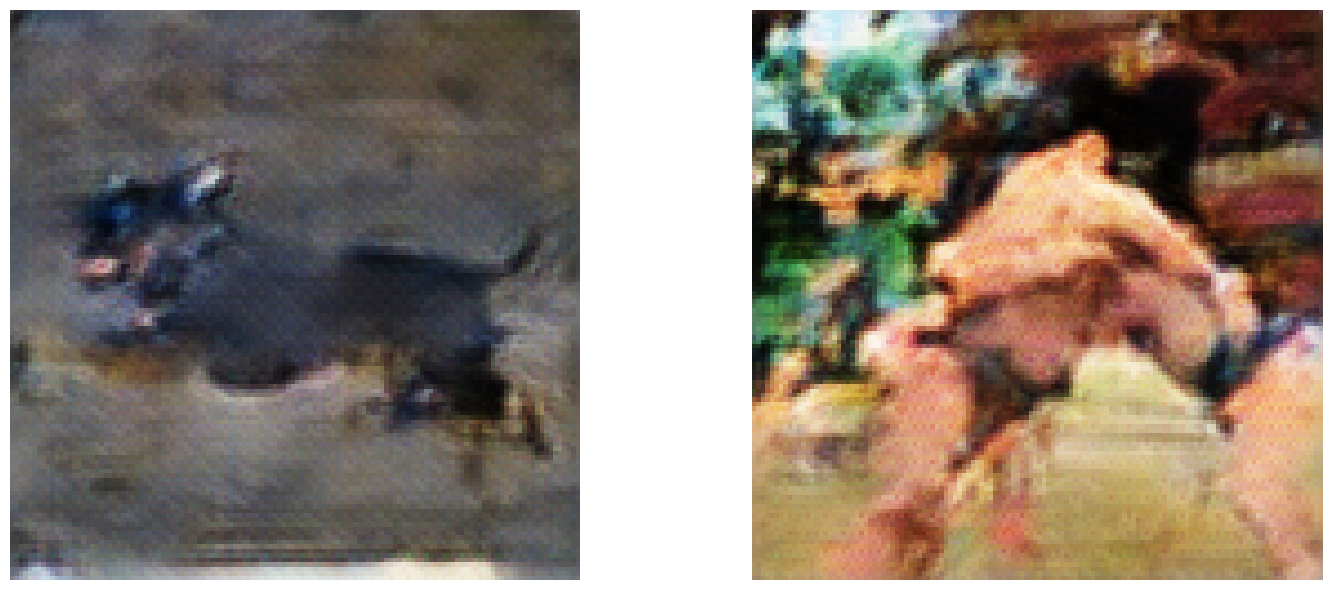

In [ ]:
cfg_weight = 1
with torch.no_grad():
  for x, y in val_loader_prior_3:
    x = {k:v.to(device) for k,v in x.items()}
    y = {k:v.to(device) for k,v in y.items()}
    cond_inp = x
    logits_c = prior_model(cond_inp, training=False)

    uncond_inp = {'text_tokens': None, 'image_tokens': x['image_tokens']}
    logits_u = prior_model(uncond_inp, training=False)
    logits_batch = logits_u + cfg_weight * (logits_c - logits_u)
    logits_batch[:,PRIOR_CONFIG_3['context_length']:,:tokenizer.n_vocab] = torch.tensor(float('-inf'), device=logits_batch.device) # this line ensures that only image tokens are generated

    pred_seq = torch.argmax(logits_batch, dim=-1)
    for i in range(pred_seq.shape[0]):
      print(f"{i} sequence")
      print(f"Input Text Seq: {x['text_tokens'][i]}")
      print(f"Target Text Seq: {y['text_tokens'][i]}")
      # print(f"Predicted Text Seq: {pred_seq[:, :PRIOR_CONFIG_3['context_length']][i]}")
      print(f"Predicted Text Seq: {torch.argmax(logits_c, dim=-1)[:, :PRIOR_CONFIG_3['context_length']][i]}")
      print(f"Input Image Seq: {x['image_tokens'][i][:50]}")
      print(f"Target Image Seq: {y['image_tokens'][i][:50]}")
      print(f"Predicted Image Seq: {pred_seq[:,PRIOR_CONFIG_3['context_length']:][i][:50]}")
      print()
    break

# image reconstruction from autoregressively generated image codes
img_tokens = pred_seq[[4,3],PRIOR_CONFIG_3['context_length']:].reshape(-1, PRIOR_CONFIG_3['grid_size'][0], PRIOR_CONFIG_3['grid_size'][1]) # remove soi token and reshape to 32 * 32 grid expected by vqvae decoder
img_tokens = img_tokens - tokenizer.n_vocab # to get back original image codes
reconst = reconstruct_from_prior(vqvae, img_tokens, device).cpu()

fig, axes = plt.subplots(1, img_tokens.shape[0], figsize=(16, 6))
for i in range(img_tokens.shape[0]):
  axes[i].imshow(torch.permute(reconst[i], (1, 2, 0)))
  axes[i].axis("off")
plt.tight_layout()
plt.show()

above images are not generated by predicting next tokens autoregressively. For each image token, instead of appending predicted token and passing it as input, the original input sequence was fed to the model.

2 cells below is the autoregressive image token prediction and image generation.

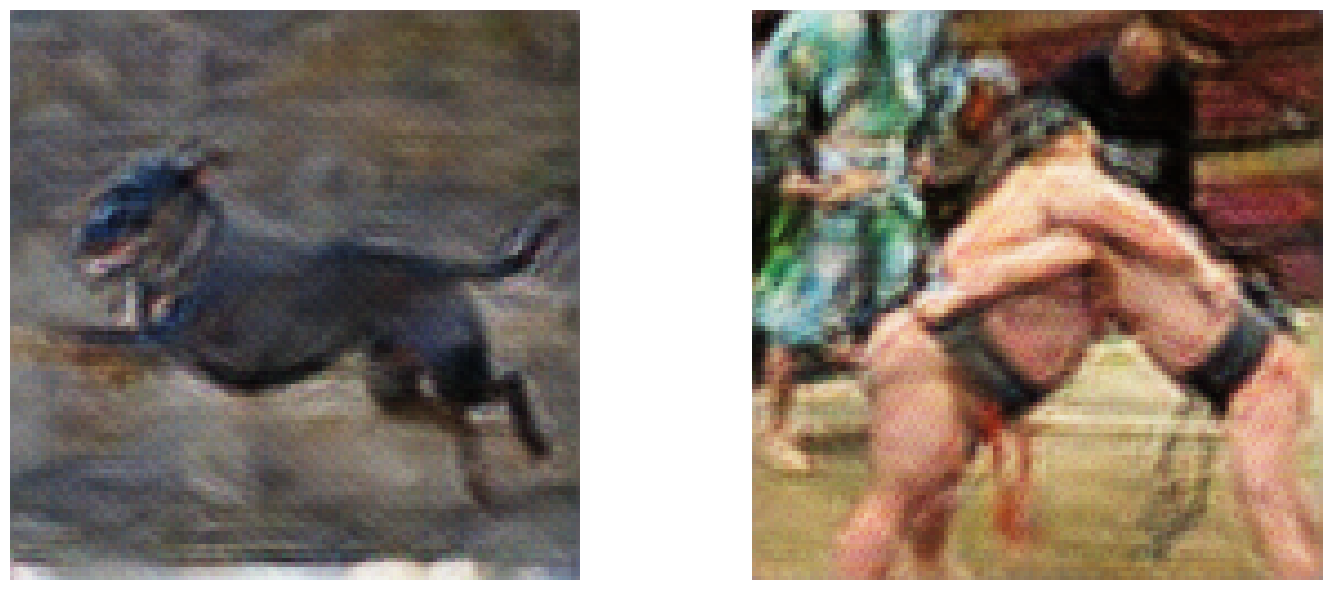

In [ ]:
# image reconstruction from original image codes
orig_img_tokens = torch.cat([x['image_tokens'][[4,3],1:], x['image_tokens'][[4,3],-1].unsqueeze(-1)], dim=-1).reshape(-1, PRIOR_CONFIG_3['grid_size'][0], PRIOR_CONFIG_3['grid_size'][1])
orig_img_tokens = orig_img_tokens - tokenizer.n_vocab # to get back original image codes
reconst_from_orig = reconstruct_from_prior(vqvae, orig_img_tokens, device).cpu()

fig, axes = plt.subplots(1, orig_img_tokens.shape[0], figsize=(16, 6))
for i in range(img_tokens.shape[0]):
  axes[i].imshow(torch.permute(reconst_from_orig[i], (1, 2, 0)))
  axes[i].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
for x, y in val_loader_prior_3:
  for i in range(x['text_tokens'].shape[0]):
    print(tokenizer.decode(x['text_tokens'][i].tolist()))
    print(tokenizer.decode(y['text_tokens'][i].tolist()))
    print()
  break

<|startoftext|>a brown , black and white dog is on a obstacle course .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>
a brown , black and white dog is on a obstacle course .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|startofimage|>

<|startoftext|>a person in the distance hikes among hoodoos with stars visible in the sky .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>
a person in the distance hikes among hoodoos with stars visible in the sky .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|startofimage|>

<|startoftext|>a man holding the hand of another man who has a tattoo on his arm .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>
a man holding the ha

tensor([[50259, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664,
         50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664,
         50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664,
         50664, 50664, 50664, 50664, 50498, 50498, 50498, 50498, 50498, 50498,
         50498, 50498, 50498, 50498, 50498, 50498, 50498, 50498, 50498, 50498],
        [50259, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664,
         50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664,
         50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664, 50664,
         50664, 50664, 50664, 50664, 50498, 50498, 50498, 50498, 50498, 50498,
         50498, 50498, 50498, 50498, 50498, 50498, 50498, 50498, 50498, 50498]],
       device='cuda:0')
3


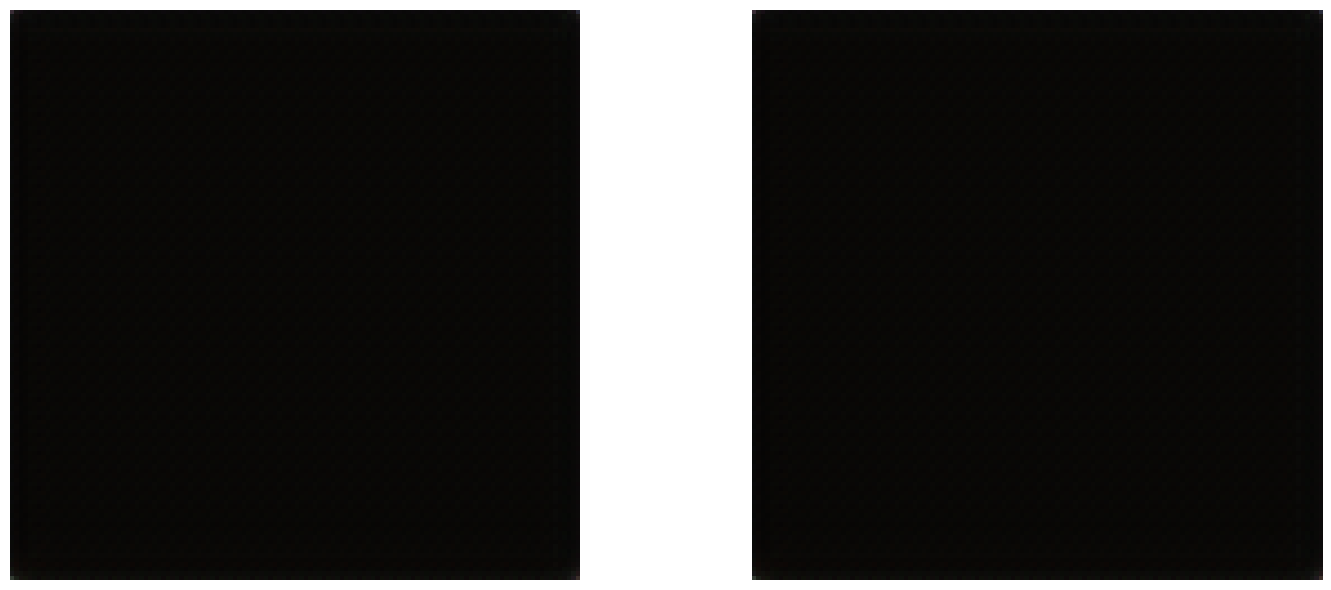

In [ ]:
samples_prompts = [
    'a black dog in the middle of running or leaping .',
    'one very fat sumo wrestler wrestles with a thinner wrestler while an umpire dressed in green watches .'
]

generate_and_render_sample(
                    prior_model,
                    vqvae,
                    tokenizer,
                    PRIOR_CONFIG_3,
                    cfg_weight=1,
                    text_prompts=samples_prompts,
                    device=device,
                    temperature=0
                )

# **Flickr8k - EXP 3**

## **Dataset Loading**

In [ ]:
zip_path = "/content/drive/My Drive/Flickr8k.zip"          # path to zip file
extract_path = "/content/drive/My Drive/Flickr8k"    # folder to extract into

if not os.path.exists(extract_path):
  # create extraction folder if it doesn't exist
  os.makedirs(extract_path, exist_ok=True)

  # extract
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)

  print("Extraction completed!")
else:
  print(f"{extract_path} already exists!")

Extraction completed!


In [ ]:
class Flickr8kDataset(Dataset):
      def __init__(self, image_dir, captions_file, split=0.8, mode="train", transform=None):
          self.transform = transform
          self.image_caption_map = {}

          with open(captions_file, 'r') as f:
              for i, line in enumerate(f):
                  if i == 0:
                      continue
                  line = line.strip()
                  img, caption = line.split(',', 1)
                  caption = caption.strip().strip('"')
                  # collect ALL captions per image into a list
                  self.image_caption_map.setdefault(img, []).append(caption)

          image_files = list(self.image_caption_map.keys())

          np.random.seed(42)
          np.random.shuffle(image_files)

          split_idx = int(len(image_files) * split)
          if mode == "train":
              image_files = image_files[:split_idx]
          elif mode == "val":
              image_files = image_files[split_idx:]
          else:
              raise ValueError("mode must be 'train' or 'val'")

          # load all images into RAM at init time
          print(f"Caching {len(image_files)} images into RAM...")
          self.samples = []
          for img_name in tqdm(image_files):
              img_path = os.path.join(image_dir, img_name)
              with open(img_path, 'rb') as f:
                  img_bytes = f.read()
              captions = self.image_caption_map[img_name]   # list of captions
              self.samples.append((img_bytes, captions))

      def __len__(self):
          return len(self.samples)

      def __getitem__(self, idx):
          img_bytes, captions = self.samples[idx]
          image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
          if self.transform:
              image = self.transform(image)
          return image, captions

In [ ]:
transform = transforms.Compose([
    transforms.Resize(150),           # resize shorter edge to 150
    transforms.CenterCrop(128),       # crop to square
    transforms.ToTensor(),
])

train_dataset_vqvae_4 = Flickr8kDataset(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="train",
    transform=transform
)

val_dataset_vqvae_4 = Flickr8kDataset(
    image_dir=f"{extract_path}/Images",
    captions_file=f"{extract_path}/captions.txt",
    mode="val",
    transform=transform
)

Caching 6472 images into RAM...


100%|██████████| 6472/6472 [00:14<00:00, 452.56it/s]


Caching 1619 images into RAM...


100%|██████████| 1619/1619 [00:03<00:00, 461.53it/s]


In [ ]:
len(train_dataset_vqvae_4), len(val_dataset_vqvae_4)

(6472, 1619)

In [ ]:
train_dataset_vqvae_4[0][0].shape

torch.Size([3, 128, 128])

In [ ]:
train_dataset_vqvae_4[0][0].min(), train_dataset_vqvae_4[0][0].max(), train_dataset_vqvae_4[0][0].unique().numel()

(tensor(0.0039), tensor(0.9569), 244)

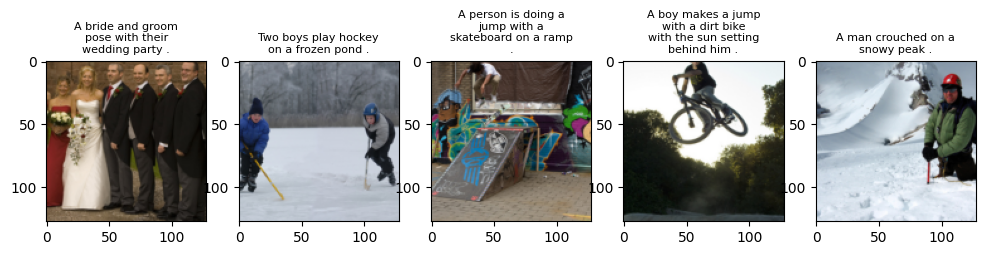

In [ ]:
np.random.seed(123)

random_indices = np.random.choice(len(val_dataset_vqvae_4), 5)

fig, axes = plt.subplots(1, 5, figsize=(12,6))

for i, ax in zip(random_indices, axes):
  img, captions = val_dataset_vqvae_4[i]
  wrapped_caption = "\n".join(textwrap.wrap(captions[0], width=20))
  ax.imshow(img.permute(1,2,0))
  ax.set_title(f"{wrapped_caption}", fontsize=8)

plt.show()

In [ ]:
samples = torch.stack([val_dataset_vqvae_4[int(i)][0] for i in random_indices], dim=0)

## **Image Tokenizer (VQ-VAE)**

Following implementation downsamples and upsamples by factor of 4.

In [8]:
class VQ4(nn.Module):
  def __init__(self, latent_dim, k, normalize_codebook, decay=0.99): # k = number of discrete vectors or size of codebook
    super().__init__()
    self.k = k
    self.latent_dim = latent_dim
    self.normalize_codebook = normalize_codebook
    self.register_buffer("moving_sum", torch.zeros(k, latent_dim))
    self.register_buffer("moving_count", torch.zeros(k))
    self.register_buffer("codebook", torch.zeros(k, latent_dim))
    self.register_buffer("initialized", torch.tensor(False))
    self.register_buffer("decay", torch.tensor(decay))

  def forward(self, z_e, training):
    B, C, H, W = z_e.shape
    ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
    if not self.initialized:
      ze_flatten = ze_permute.reshape(-1, C)
      if ze_flatten.shape[0] < self.k:
        indices = torch.randint(0, ze_flatten.shape[0], (self.k,))
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)
      else:
        indices = torch.randperm(ze_flatten.shape[0])[:self.k]
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)

    if self.normalize_codebook:
      ze_norm = F.normalize(ze_permute, dim=-1)          # (B, H, W, C)
      codebook_norm = F.normalize(self.codebook, dim=-1) # (k, C)

      # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
      cross = ze_norm @ codebook_norm.T # (B, H, W, k)
      z_l2_sq = (ze_norm ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
      e_l2_sq = (codebook_norm ** 2).sum(dim=-1) # (k,)

      discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
      z_q = codebook_norm[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)
    else:
      # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
      cross = ze_permute @ self.codebook.T # (B, H, W, k)
      z_l2_sq = (ze_permute ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
      e_l2_sq = (self.codebook ** 2).sum(dim=-1) # (k,)

      discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
      z_q = self.codebook[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)

    # EMA codebook update
    if training:
      n_t = torch.zeros(self.k, device=z_e.device)
      codes_flatten = discrete_codes.reshape(-1)
      n_t.scatter_add_(0, codes_flatten, torch.ones(codes_flatten.shape, device=z_e.device)) # current code-wise utilization count
      self.moving_count.copy_(self.moving_count * self.decay + n_t * (1 - self.decay))
      ze_flatten = ze_permute.reshape(-1, C)
      current_code_sum = torch.zeros_like(self.moving_sum)
      # for i in range(self.k):
      #   assigned_indices = torch.where(codes_flatten == i)[0]
      #   if assigned_indices.shape[0] > 0:
      #     assigned_ze = ze_flatten[assigned_indices]
      #     m_i = assigned_ze.sum(0)
      #     current_code_sum[i] = m_i
      current_code_sum.scatter_add_(0, codes_flatten.unsqueeze(-1).expand(-1, C), ze_flatten)
      self.moving_sum.copy_(self.moving_sum * self.decay + current_code_sum * (1 - self.decay))
      safe_count = self.moving_count.unsqueeze(-1).clamp(min=1e-6)
      self.codebook.data.copy_(self.moving_sum / safe_count)
      if self.normalize_codebook:
        self.codebook.data.copy_(F.normalize(self.codebook.data, dim=-1))

    return z_q, discrete_codes

In [9]:
class ResidualBlock4(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 1),
        )

    def forward(self, x):
        return x + self.block(x)

class Encoder4(nn.Module):
    def __init__(self, in_channels, hidden, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 4, stride=2, padding=1),
            nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),
            # nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),
            ResidualBlock4(hidden),
            ResidualBlock4(hidden),
            nn.Conv2d(hidden, latent_dim, 1),  # project to codebook dim
        )

    def forward(self, x):
        return self.net(x)

class Decoder4(nn.Module):
    def __init__(self, latent_dim, hidden, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_dim, hidden, 1),  # project back from codebook dim
            ResidualBlock4(hidden),
            ResidualBlock4(hidden),
            # nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),
            nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),
            nn.ConvTranspose2d(hidden, out_channels, 4, stride=2, padding=1),
        )

    def forward(self, x):
        return self.net(x)

In [10]:
class VQVAE4(nn.Module):
  def __init__(self, in_channels, out_channels, latent_dim, hidden, k, normalize_codebook, decay=0.99):
    super().__init__()
    self.encoder = Encoder4(in_channels, hidden, latent_dim)
    self.decoder = Decoder4(latent_dim, hidden, out_channels)
    self.vq_layer = VQ4(latent_dim, k, normalize_codebook, decay=decay)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x, training=False):
    z_e = self.encoder(x)
    z_q, discrete_codes = self.vq_layer(z_e, training)
    decoder_inp = z_e + (z_q - z_e).detach() # straight through estimator, the effective value for the forward pass is z_q only but the gradients flow to z_e
    reconst = self.sigmoid(self.decoder(decoder_inp))

    return reconst, z_e, z_q, discrete_codes

### Training

In [ ]:
def calc_batch_loss(model, x, device, training, percep_loss_fn, lambda_=0.1, beta=0.25):
  x = x.to(device)
  reconst, z_e, z_q, discrete_codes = model(x, training)
  x_scaled = x * 2 - 1
  reconst_scaled = reconst * 2 - 1
  percep_loss = lambda_ * percep_loss_fn(x_scaled, reconst_scaled).mean()
  l_1 = nn.functional.binary_cross_entropy(reconst, x)
  ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
  zq_permute = torch.permute(z_q, (0, 2, 3, 1)) # (B, H, W, C)
  l_3 = (beta * torch.norm(ze_permute - zq_permute.detach(), dim=-1) ** 2).mean()
  loss = l_1 + l_3 + percep_loss

  return loss, l_1, l_3, percep_loss, discrete_codes

In [ ]:
def evaluate(loader, model, device, percep_loss_fn, max_batch, k, lambda_=0.1):
  total_loss = 0
  total_l1_loss, total_l3_loss, total_percep_loss = 0, 0, 0
  all_codes = []
  if max_batch is None:
    max_batch = len(loader)
  elif max_batch <= 0:
    return float("nan")
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        loss, l_1, l_3, percep_loss, discrete_codes = calc_batch_loss(model, x, device, training=False, percep_loss_fn=percep_loss_fn, lambda_=lambda_)
      total_loss += loss.item()
      total_l1_loss += l_1.item()
      total_l3_loss += l_3.item()
      total_percep_loss += percep_loss.item()
      all_codes.append(discrete_codes.reshape(-1))
    else:
      break
  all_codes = torch.cat(all_codes, dim=0)

  return total_loss/max_batch, total_l1_loss/max_batch, total_l3_loss/max_batch, total_percep_loss/max_batch, all_codes.unique().numel() / k

In [ ]:
def reconstruct(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      reconst, _, _, _ = model(x, training=False)
    return reconst.cpu()

In [ ]:
def train_vqvae(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    percep_loss_fn,
    lambda_=0.1,
    epochs=20,
    eval_interval=500,
    k=512,
    samples=None
):
    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    global_step = -1

    # logs
    train_losses, val_losses = [], []
    train_l1_losses, val_l1_losses = [], []
    train_l3_losses, val_l3_losses = [], []
    train_percep_losses, val_percep_losses = [], []
    train_codebook, val_codebook = [], []

    t_start = time.time()
    model.train()

    for epoch in range(epochs):
        for x, _ in train_loader:
            optimizer.zero_grad()

            loss, _, _, _, _ = calc_batch_loss(
                model, x, device, training=True, percep_loss_fn=percep_loss_fn, lambda_=lambda_
            )
            loss.backward()
            optimizer.step()

            global_step += 1

            if global_step % eval_interval == 0:
                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done
                eta_minutes = (elapsed / steps_done) * steps_left / 60

                model.eval()

                train_loss, train_l1, train_l3, train_percep_loss, train_cu = evaluate(
                    train_loader, model, device, percep_loss_fn, max_batch=20, k=k, lambda_=lambda_
                )
                val_loss, val_l1, val_l3, val_percep_loss, val_cu = evaluate(
                    val_loader, model, device, percep_loss_fn, max_batch=None, k=k, lambda_=lambda_
                )

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3={train_l3:.4f}, percep_loss={train_percep_loss:.4f})")
                print(f"\tCodebook: {train_cu:.2f}")
                print(f"\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3={val_l3:.4f}, percep_loss={val_percep_loss:.4f})")
                print(f"\tCodebook: {val_cu:.2f}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

                # store logs
                train_losses.append(train_loss)
                val_losses.append(val_loss)

                train_l1_losses.append(train_l1)
                val_l1_losses.append(val_l1)

                train_l3_losses.append(train_l3)
                val_l3_losses.append(val_l3)

                train_percep_losses.append(train_percep_loss)
                val_percep_losses.append(val_percep_loss)

                train_codebook.append(train_cu)
                val_codebook.append(val_cu)

                # reconstruction viz
                if samples is not None:
                    reconst = reconstruct(model, samples, device)

                    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
                    for i in range(5):
                        axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                        axes[0, i].axis("off")

                        axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                        axes[1, i].axis("off")

                    plt.tight_layout()
                    plt.show()

                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_l1": train_l1_losses,
        "val_l1": val_l1_losses,
        "train_l3": train_l3_losses,
        "val_l3": val_l3_losses,
        "train_percep_loss": train_percep_losses,
        "val_percep_loss": val_percep_losses,
        "train_codebook": train_codebook,
        "val_codebook": val_codebook
    }

In [ ]:
def collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    captions = [item[1] for item in batch]  # list of lists: [[cap1..cap5], ...]
    return images, captions

In [ ]:
train_loader_vqvae_4 = DataLoader(
    train_dataset_vqvae_4,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader_vqvae_4 = DataLoader(
    val_dataset_vqvae_4,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
len(train_loader_vqvae_4), len(val_loader_vqvae_4)

(405, 102)

In [ ]:
for imgs, caps in val_loader_vqvae_4:
  print(imgs.shape)
  print(caps)
  break

torch.Size([16, 3, 128, 128])
[['A brown , black and white dog is on a obstacle course .', 'A dog climbs down a black ramp', 'A dog is running down a black and yellow ramp in an obstacle course .', 'A dog walks down a black ramp .', 'The black and white dog ran down the ramp .'], ['A person in the distance hikes among hoodoos with stars visible in the sky .', 'A person standing on a ridge in the desert .', 'Interesting rock formations in the desert landscape , with stars above .', 'The night sky in the desert .', 'There is a person standing a mountain that has some interesting shapes .'], ['A man holding the hand of another man who has a tattoo on his arm .', 'A man that is standing up is holding the hand of another man that is sitting down .', 'A man wearing a hat inspects the tattooed arm of another man .', "An elderly man is holding and looking at another man 's hand .", "An older gentleman in a brown cap looking at a younger gentleman 's arm ."], ['One very fat sumo wrestler wrestl

In [ ]:
torch.manual_seed(123)

lpips_model = lpips.LPIPS(net='alex').to(device)
lpips_model.eval()
model7 = VQVAE4(in_channels=3, out_channels=3, latent_dim=8, hidden=128, k=512, normalize_codebook=False).to(device)
optimizer7 = torch.optim.Adam(model7.parameters(), lr=1e-4)

logs7 = train_vqvae(
    model=model7,
    train_loader=train_loader_vqvae_4,
    val_loader=val_loader_vqvae_4,
    optimizer=optimizer7,
    device=device,
    percep_loss_fn=lpips_model,
    lambda_=1,
    epochs=8,
    eval_interval=500,
    k=512,
    samples=samples
)

In [ ]:
torch.save(model7.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen_flickr8k_3.pt")

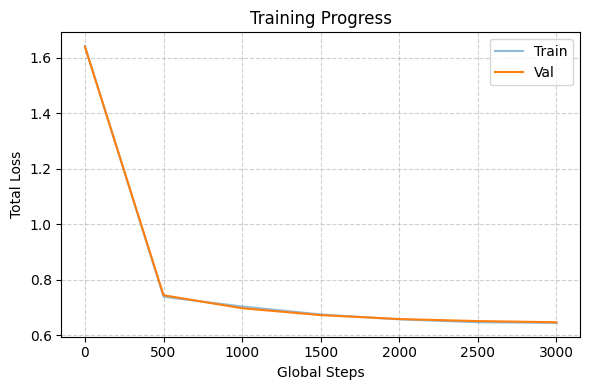

In [ ]:
plot_training_results(logs7["train_loss"], logs7["val_loss"], 500, title="Training Progress", y_title="Total Loss")

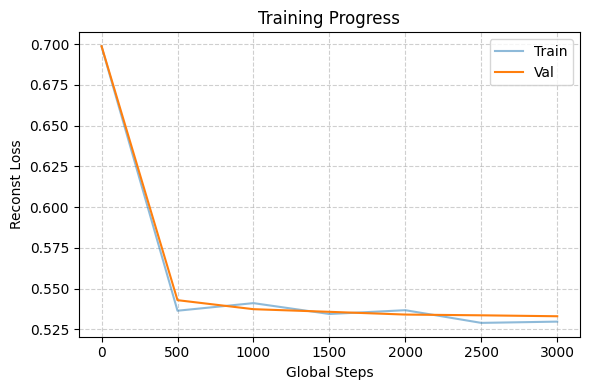

In [ ]:
plot_training_results(logs7["train_l1"], logs7["val_l1"], 500, title="Training Progress", y_title="Reconst Loss")

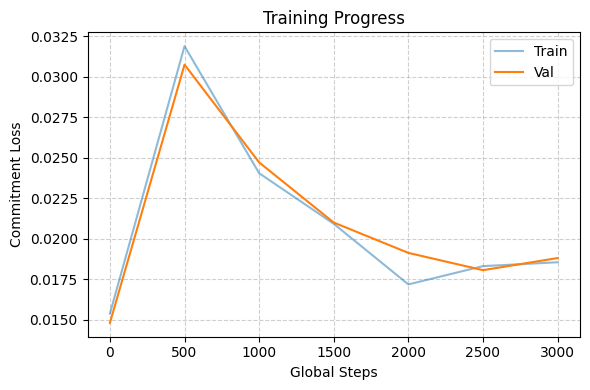

In [ ]:
plot_training_results(logs7["train_l3"], logs7["val_l3"], 500, title="Training Progress", y_title="Commitment Loss")

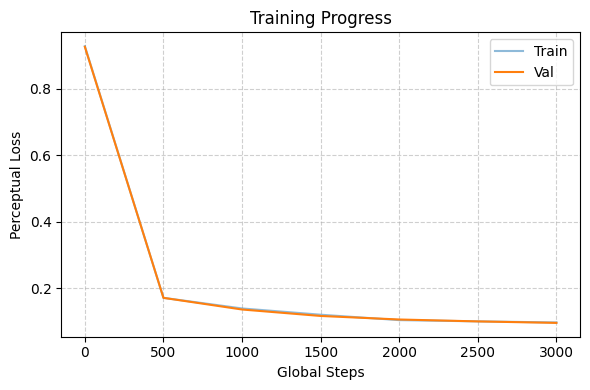

In [ ]:
plot_training_results(logs7["train_percep_loss"], logs7["val_percep_loss"], 500, title="Training Progress", y_title="Perceptual Loss")

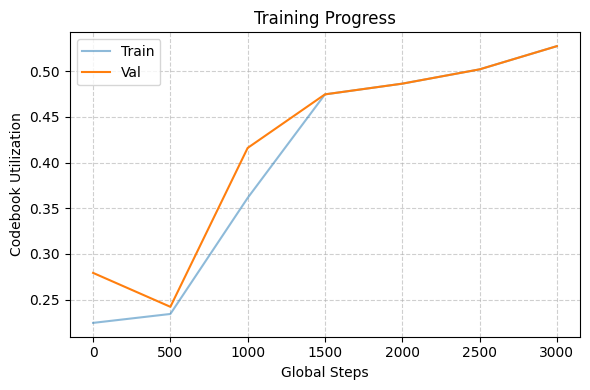

In [ ]:
plot_training_results(logs7["train_codebook"], logs7["val_codebook"], 500, title="Training Progress", y_title="Codebook Utilization")

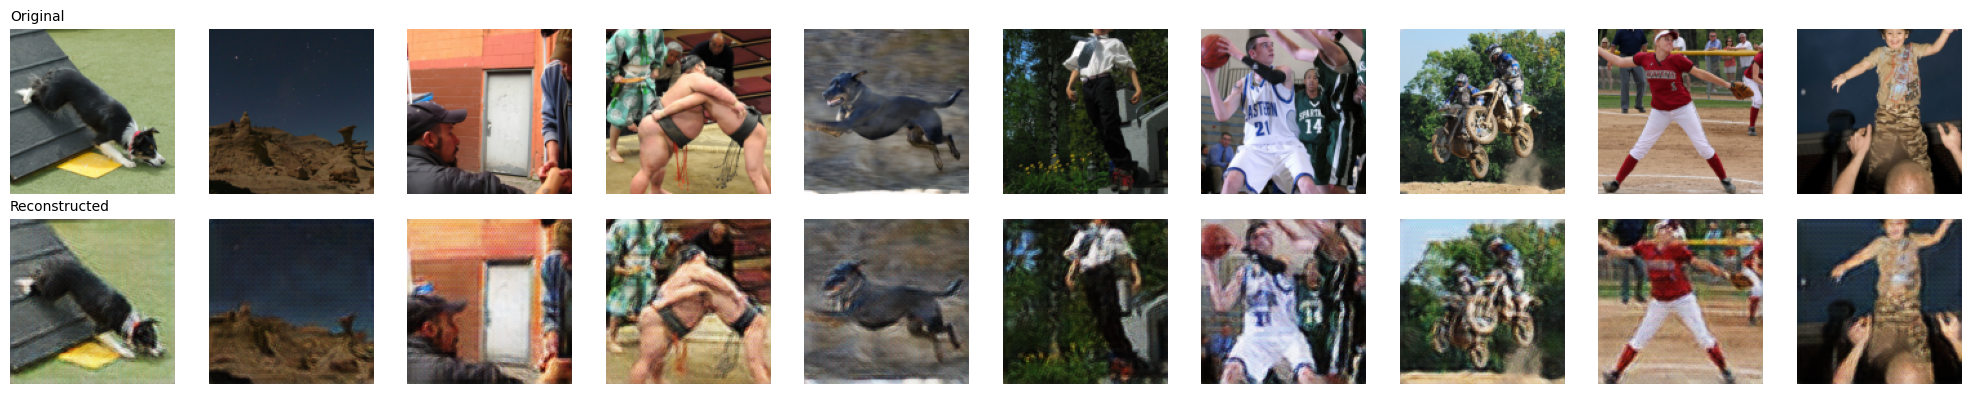

In [ ]:
vqvae = VQVAE4(in_channels=3, out_channels=3, latent_dim=8, hidden=128, k=512, normalize_codebook=False)
vqvae.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen_flickr8k_3.pt"))
vqvae.to(device)

plot_generated_vs_original(vqvae, val_loader_vqvae_4, device=device)

## **Prior Training**

In [ ]:
vqvae = VQVAE4(in_channels=3, out_channels=3, latent_dim=8, hidden=128, k=512, normalize_codebook=False)
vqvae.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen_flickr8k_3.pt", map_location="cpu"))
vqvae.to(device)

VQVAE4(
  (encoder): Encoder4(
    (net): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (2): ResidualBlock4(
        (block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (3): ResidualBlock4(
        (block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (4): Conv2d(128, 8, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (decoder): Decoder4(
    (net): Sequential(
      (0): Conv2d(8, 128, kernel_size=(1, 1), stride=(1, 1))
      (1): ResidualBlock4(
        (block): Sequential(
          (0): ReLU(

In [ ]:
enc = tk.get_encoding("gpt2")

tokenizer = tk.Encoding(
    name="gpt2_custom",
    pat_str=enc._pat_str,
    mergeable_ranks=enc._mergeable_ranks,
    special_tokens={
        **enc._special_tokens,
        "<|startoftext|>": enc.max_token_value + 1,  # new unique ID
        "<|pad|>": enc.max_token_value + 2,  # new unique ID
        "<|startofimage|>": enc.max_token_value + 3  # new unique ID
    }
)

In [ ]:
tokenizer.special_tokens_set

{'<|endoftext|>', '<|pad|>', '<|startofimage|>', '<|startoftext|>'}

In [ ]:
PAD_ID = tokenizer._special_tokens["<|pad|>"]
SOI_ID = tokenizer._special_tokens["<|startofimage|>"]
BOS_ID = tokenizer._special_tokens["<|startoftext|>"]

In [ ]:
tokenizer.n_vocab

50260

In [ ]:
class TokenizedTextImageDataset(Dataset):
    def __init__(self, model, tokenizer, loader, device):
      self.tokenized_images = []
      self.tokenized_text = []
      model.to(device)
      for x, y in tqdm(loader, desc="Generating codes"):
        x = x.to(device)
        B = x.shape[0]
        with torch.no_grad():
          z_e = model.encoder(x)
          z_q, discrete_codes = model.vq_layer(z_e, training=False)
        discrete_codes = discrete_codes.reshape(B, -1).cpu()   # (B, 1024)

        for b in range(B):                 # y[b] is the list of captions for image b
          codes = discrete_codes[b].tolist()
          for caption in y[b]:
            self.tokenized_text.append(tokenizer.encode(caption.lower()))
            self.tokenized_images.append(codes)   # same codes, one row per caption

    def __len__(self):
      return len(self.tokenized_images)

    def __getitem__(self, idx):
      return self.tokenized_images[idx], self.tokenized_text[idx]

In [ ]:
train_dataset_prior_4 = TokenizedTextImageDataset(vqvae, tokenizer, train_loader_vqvae_4, device)
val_dataset_prior_4 = TokenizedTextImageDataset(vqvae, tokenizer, val_loader_vqvae_4, device)

Generating codes: 100%|██████████| 102/102 [00:07<00:00, 13.27it/s]


In [ ]:
torch.save({
    "tokenized_images": train_dataset_prior_4.tokenized_images,
    "tokenized_text": train_dataset_prior_4.tokenized_text
}, "/content/drive/My Drive/GenAI/Data/train_dataset_prior_4.pt")

torch.save({
    "tokenized_images": val_dataset_prior_4.tokenized_images,
    "tokenized_text": val_dataset_prior_4.tokenized_text
}, "/content/drive/My Drive/GenAI/Data/val_dataset_prior_4.pt")

In [ ]:
class LoadTokenizedTextImageDataset(Dataset):
    def __init__(self, tokenized_images, tokenized_text):
        self.tokenized_images = tokenized_images
        self.tokenized_text = tokenized_text

    def __len__(self):
        return len(self.tokenized_images)

    def __getitem__(self, idx):
        return self.tokenized_images[idx], self.tokenized_text[idx]

In [ ]:
train_data = torch.load("/content/drive/My Drive/GenAI/Data/train_dataset_prior_4.pt")

train_dataset_prior_4 = LoadTokenizedTextImageDataset(
    train_data["tokenized_images"],
    train_data["tokenized_text"]
)

val_data = torch.load("/content/drive/My Drive/GenAI/Data/val_dataset_prior_4.pt")

val_dataset_prior_4 = LoadTokenizedTextImageDataset(
    val_data["tokenized_images"],
    val_data["tokenized_text"]
)

In [ ]:
len(train_dataset_prior_4), len(val_dataset_prior_4)

(32360, 8095)

In [ ]:
for name, ds in [("Train", train_dataset_prior_4), ("Val", val_dataset_prior_4)]:
      lengths = [len(text) for img, text in ds]
      print(f"{name}: 99th pct={np.percentile(lengths, 99):.1f}, "
            f"95th pct={np.percentile(lengths, 95):.1f}, max={max(lengths)}")

Train: 99th pct=24.0, 95th pct=20.0, max=43
Val: 99th pct=24.0, 95th pct=20.0, max=35


In [ ]:
def collator(batch, text_vocab_size, max_text_tokens, sot_id=50257, pad_id=50258, soi_id=50259):
  input_text_tokens = []
  input_image_tokens = []
  target_text_tokens = []
  target_image_tokens = []
  for img_tokens, text_tokens in batch:
    text_tokens = [sot_id] + text_tokens
    if len(text_tokens) > max_text_tokens:
      new_text_tokens = text_tokens[:max_text_tokens]
    else:
      new_text_tokens = text_tokens + [pad_id] * (max_text_tokens - len(text_tokens))
    img_tokens = [text_vocab_size+img_code for img_code in img_tokens]
    new_image_tokens = [soi_id] + img_tokens

    input_text_tokens.append(new_text_tokens)
    input_image_tokens.append(new_image_tokens[:-1])

    target_text_tokens.append(new_text_tokens[1:] + [new_image_tokens[0]])
    target_image_tokens.append(new_image_tokens[1:])


  input_text_tokens = torch.tensor(input_text_tokens)
  input_image_tokens = torch.tensor(input_image_tokens)
  target_text_tokens = torch.tensor(target_text_tokens)
  target_image_tokens = torch.tensor(target_image_tokens)
  inputs = {"text_tokens": input_text_tokens, "image_tokens": input_image_tokens}
  targets = {"text_tokens": target_text_tokens, "image_tokens": target_image_tokens}

  return inputs, targets

### Transformer

In [ ]:
PRIOR_CONFIG_4 = {
    'emb_size':1024, # increased emb size to 1024 from 768 for this exp
    'context_length':32, # trying context length of 32 instead of 256
    'text_vocab_size':tokenizer.n_vocab,
    "codebook_size": 512,
    'num_heads':16, # from 12 to 16 for this exp
    'num_layers':6, # reduced layers from 12 to 6 for this exp
    'drop_rate':0.1,
    'grid_size': (32, 32),
    'row_extension': 33, # for 32 x 32 grid, the row extension of 33 will allow to attend the same column from prev row
    'kernel_size': 11, # kernel size of convolution attention mask
    'cfg_drop': 0.1,
    'qkv_bias': False,
}

PRIOR_CONFIG_4["total_vocab_size"] = PRIOR_CONFIG_4["text_vocab_size"] + PRIOR_CONFIG_4["codebook_size"]

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, mask_type, grid_size, row_extension, kernel_size, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)
    # # special raw-col-conv attention mask
    # self.register_buffer(
    #     'mask',
    #     self._create_mask(
    #         mask_type,
    #         context_length,
    #         grid_size=grid_size,
    #         row_extension=row_extension,
    #         kernel_size=kernel_size,
    # ))

    # standard causal mask attention instead of special raw-col-conv attention mask
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length + grid_size[0] * grid_size[1], context_length + grid_size[0] * grid_size[1]), diagonal=1)
    )

  def _create_mask(
      self,
      mask_type,
      text_len,
      grid_size=(32, 32),
      row_extension=32,
      kernel_size=11,
      use_soi=True,
  ):
      H, W = grid_size
      image_len = H * W
      soi_tokens = 1 if use_soi else 0
      total_len = text_len + soi_tokens + image_len
      mask = torch.zeros(
          (total_len, total_len),
          dtype=torch.bool
      )
      # =========================================================
      # TEXT TOKENS
      # Standard causal mask
      # =========================================================
      for i in range(text_len):
          mask[i, : i + 1] = True
      # =========================================================
      # SOI TOKEN
      # =========================================================
      if use_soi:
          soi_idx = text_len
          # SOI attends to all previous text tokens
          mask[soi_idx, : text_len + 1] = True
          image_offset = text_len + 1
      else:
          soi_idx = None
          image_offset = text_len
      # =========================================================
      # IMAGE TOKENS
      # =========================================================
      for img_idx in range(image_len):
          q = image_offset + img_idx
          # -----------------------------------------------------
          # image tokens attend to all text tokens
          # -----------------------------------------------------
          mask[q, :text_len] = True
          # -----------------------------------------------------
          # attend to SOI token
          # -----------------------------------------------------
          if use_soi:
              mask[q, soi_idx] = True
          row = img_idx // W
          col = img_idx % W
          # =====================================================
          # ROW ATTENTION
          # =====================================================
          if mask_type == "row":
              start = max(0, img_idx - row_extension)
              for prev in range(start, img_idx + 1):
                  mask[q, image_offset + prev] = True
          # =====================================================
          # COLUMN ATTENTION
          # =====================================================
          elif mask_type == "column":
              for prev in range(img_idx + 1):
                  prev_row = prev // W
                  prev_col = prev % W
                  same_col = (prev_col == col)
                  within_extent = (
                      row - prev_row
                  ) <= row_extension
                  if same_col and within_extent:
                      mask[q, image_offset + prev] = True
          # =====================================================
          # CONVOLUTION ATTENTION
          # WITH WRAPAROUND BEHAVIOR
          # =====================================================
          elif mask_type == "convolution":
              radius = kernel_size // 2
              for prev in range(img_idx + 1):
                  prev_row = prev // W
                  prev_col = prev % W
                  dr = row - prev_row
                  # horizontal wraparound distance
                  dc = min(
                      abs(col - prev_col),
                      W - abs(col - prev_col)
                  )
                  inside_kernel = (
                      abs(dr) <= radius
                      and dc <= radius
                  )
                  if inside_kernel:
                      mask[q, image_offset + prev] = True
          else:
              raise ValueError(
                  f"Unknown mask type: {mask_type}"
              )
      return ~mask

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    attention_scores = queries @ keys.transpose(2,3)
    attention_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self, emb_size):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_size))
    self.shift = nn.Parameter(torch.zeros(emb_size))

  def forward(self, x):
    mean = x.mean(keepdim=True, dim=-1)
    variance = x.var(keepdim=True, dim=-1, unbiased=False)
    norm_x = (x - mean)/torch.sqrt(variance + self.eps)
    return self.scale * norm_x + self.shift

In [ ]:
class GeLU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
    ))

In [ ]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_size'], 4 * cfg['emb_size']),
        GeLU(),
        nn.Linear(4 * cfg['emb_size'], cfg['emb_size'])
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg, mask_type):
    super().__init__()
    self.mha = MultiHeadAttention(cfg['emb_size'], cfg['emb_size'], cfg['context_length'], cfg['drop_rate'], cfg['num_heads'], mask_type, cfg['grid_size'], cfg['row_extension'], cfg['kernel_size'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.ffn = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [ ]:
class Prior(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['total_vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.null_emb_layer = nn.Embedding(1, cfg['emb_size'])
    self.row_emb_layer = nn.Embedding(cfg['grid_size'][0], cfg['emb_size'])
    self.col_emb_layer = nn.Embedding(cfg['grid_size'][1] + 1, cfg['emb_size']) # the 0th col_emb is for startofimage token only and not for any of the image tokens belonging to the zeroth column in 2d view
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg, self._mask_type(i, cfg['num_layers'])) for i in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['total_vocab_size'], bias=False)
    self.num_rows = cfg['grid_size'][0]
    self.num_cols = cfg['grid_size'][1]
    self.context_length = cfg['context_length']
    self.cfg_drop = cfg['cfg_drop']

  def _mask_type(self, i, num_layers):
    if i==num_layers-1:
      return 'convolution'
    elif (i-1)%4==0:
      return 'column'
    else:
      return 'row'

  def forward(self, input, training=False):
    text_tokens = input.get('text_tokens', None) # text_tokens will be None for unconditional inference
    image_tokens = input.get('image_tokens', None) # soi token belongs to image_tokens seq
    batch_size, num_img_tokens = image_tokens.shape
    null_emb = self.null_emb_layer(torch.tensor(0).to(image_tokens.device))
    if text_tokens is None: # during unconditional inference
      text_token_emb = null_emb.unsqueeze(0).unsqueeze(0).expand(batch_size, self.context_length, -1)
    else:
      text_token_emb = self.token_emb_layer(text_tokens)
    _, num_text_tokens, _ = text_token_emb.shape
    pos_emb = self.pos_emb_layer(
        torch.arange(num_text_tokens, device=image_tokens.device)
    )
    if training:
      drop_ind = torch.rand(batch_size) < self.cfg_drop
      text_token_emb[drop_ind] = null_emb.unsqueeze(0).expand(num_text_tokens, -1)
    text_emb = text_token_emb + pos_emb
    image_token_emb = self.token_emb_layer(image_tokens)
    # row_emb = self.row_emb_layer(
    #     torch.arange((num_img_tokens-1)//self.num_rows, device=image_tokens.device)
    # )
    # cols_to_use = min(num_img_tokens-1, self.num_cols) + 1 # for +1 for soi token
    # col_emb = self.col_emb_layer(
    #     torch.arange(cols_to_use, device=image_tokens.device)
    # )
    # image_token_emb[0] = image_token_emb[0] + row_emb[0] + col_emb[0] # soi separately
    # row_emb_repeat = torch.repeat_interleave(row_emb, self.num_cols, dim=0)[:num_img_tokens-1] # excluded soi since it is already done
    # col_emb_repeat = torch.tile(col_emb[1:], ((num_img_tokens-1) // (cols_to_use - 1) + 1,))[:num_img_tokens-1] # excluded soi since it is already done
    # image_token_emb[1:] = image_token_emb[1:] + row_emb_repeat + col_emb_repeat
    # for each image token (excluding SOI), compute which row it belongs to
    image_token_emb[:,0] = image_token_emb[:,0] + self.row_emb_layer(torch.tensor(0, device=image_tokens.device)) + self.col_emb_layer(torch.tensor(0, device=image_tokens.device)) # soi separately
    img_indices = torch.arange(num_img_tokens - 1, device=image_tokens.device)
    row_indices = img_indices // self.num_cols   # shape (num_img_tokens-1,)
    col_indices = img_indices % self.num_cols    # shape (num_img_tokens-1,)
    row_emb = self.row_emb_layer(row_indices)   # (num_img_tokens-1, emb_size)
    col_emb = self.col_emb_layer(col_indices + 1)  # +1 to skip the SOI col slot
    image_token_emb[:,1:] = image_token_emb[:,1:] + row_emb + col_emb
    x = torch.cat((text_emb, image_token_emb), dim=1)
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits

### Training

In [ ]:
def ce_batch_loss_calc(input_batch, target_batch, model, device, cfg, training=False):
  input_batch = {k:v.to(device) for k,v in input_batch.items()}
  target_batch = {k:v.to(device) for k,v in target_batch.items()}
  logits_batch = model(input_batch, training=training)
  # loss_text = torch.nn.functional.cross_entropy(logits_batch[:, :cfg['context_length'], :].flatten(0, 1), target_batch['text_tokens'].flatten()) / cfg['context_length'] # dividing to normalize wrt text token occurence
  # loss_image = torch.nn.functional.cross_entropy(logits_batch[:, cfg['context_length']:, :].flatten(0, 1), target_batch['image_tokens'].flatten()) / (cfg['grid_size'][0] * cfg['grid_size'][1]) # dividing to normalize wrt image token occurence
  # correct implementation
  loss_text = torch.nn.functional.cross_entropy(logits_batch[:, :cfg['context_length'], :].flatten(0, 1), target_batch['text_tokens'].flatten(), ignore_index=PAD_ID, reduction='mean')
  loss_image = torch.nn.functional.cross_entropy(logits_batch[:, cfg['context_length']:, :].flatten(0, 1), target_batch['image_tokens'].flatten(), reduction='mean')
  loss = 0.125 * loss_text + 0.875 * loss_image

  return loss

In [ ]:
def calc_loss_dataloader(loader, model, device, cfg, num_batches=None):
  total_loss = 0
  if len(loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(loader)
  elif num_batches < 0:
    num_batches = float('nan')
  else:
    num_batches = min(num_batches, len(loader))

  for i, (x, y) in enumerate(loader):
    if i < num_batches:
      loss = ce_batch_loss_calc(x, y, model, device, cfg, training=False)
      total_loss += loss.item()
    else:
      break

  return total_loss/num_batches

In [ ]:
def evaluate_prior(model, train_loader, val_loader, device, cfg, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_dataloader(train_loader, model, device, cfg, eval_iter)
    val_loss = calc_loss_dataloader(val_loader, model, device, cfg, eval_iter)
  model.train()

  return train_loss, val_loss

In [ ]:
def generate(model, tokenizer, inputs, max_gen_tokens, cfg_weight, temperature=0.0, top_k=None, eos_id=None): # cfg_weight -> classifier-free guidance
  B, N = inputs['text_tokens'].shape
  finished = torch.zeros(B, dtype=torch.bool, device=inputs['text_tokens'].device)
  for i in range(max_gen_tokens):
    with torch.no_grad():
      cond_inp = inputs
      logits_c = model(cond_inp, training=False)[:, -1, :]

      uncond_inp = {'text_tokens': None, 'image_tokens': inputs['image_tokens']}
      logits_u = model(uncond_inp, training=False)[:, -1, :]
    logits = logits_u + cfg_weight * (logits_c - logits_u) # classifier free guidance for boosting logits for tokens which are caption or condition relevant

    logits[:,:tokenizer.n_vocab] = torch.tensor(float('-inf'), device=logits.device) # this line ensures that only image tokens are generated

    if top_k is not None:
      top_logits, top_idx = torch.topk(logits, top_k)
      logits = torch.where(
          condition=logits<top_logits[:,-1, None],
          input=torch.tensor(float('-inf'), device=logits.device),
          other=logits
      )

    if temperature > 0:
      scaled_logits = logits / temperature
      probs = torch.softmax(scaled_logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)

    if eos_id is not None:
        finished |= (idx_next.squeeze(-1) == eos_id)
        idx_next[finished] = eos_id

    inputs['image_tokens'] = torch.cat((inputs['image_tokens'], idx_next), dim=1)

    if finished.all():
        break

  return inputs['image_tokens']

In [ ]:
def reconstruct_from_prior(vqvae, img_tokens, device):
  vqvae.eval()
  with torch.no_grad():
    img_tokens = img_tokens.to(device) # (B, H, W)
    codebook_latents = vqvae.vq_layer.codebook[img_tokens].permute(0, 3, 1, 2) # (B, emb_dim, H, W)
    reconst = vqvae.sigmoid(vqvae.decoder(codebook_latents))
  return reconst

In [ ]:
def tokenize_text(text, tokenizer, max_text_tokens):
  tokens = tokenizer.encode(text.lower())
  tokens = [BOS_ID] + tokens
  if len(tokens) > max_text_tokens:
    new_tokens = tokens[:max_text_tokens]
  else:
    new_tokens = tokens + [PAD_ID] * (max_text_tokens - len(tokens))
  return new_tokens

In [ ]:
def generate_and_render_sample(model, vqvae, tokenizer, cfg, cfg_weight, text_prompts, device, temperature=0.7):
  model.eval()
  input_text_tokens = []
  for text in text_prompts:
    text_tokens = tokenize_text(text, tokenizer, cfg['context_length'])
    input_text_tokens.append(text_tokens)
  input_image_tokens = [[SOI_ID] for i in range(len(text_prompts))]
  inputs = {
      'text_tokens': torch.tensor(input_text_tokens, device=device),
      'image_tokens': torch.tensor(input_image_tokens, device=device)
  }
  with torch.no_grad():
    op_tokens = generate(
        model,
        inputs=inputs,
        tokenizer=tokenizer,
        max_gen_tokens=1024,
        cfg_weight=cfg_weight,
        temperature=temperature,
        top_k=25
    )
  print(op_tokens[:,:50])
  print(op_tokens.unique().numel())
  img_tokens = op_tokens[:,1:].reshape(-1, cfg['grid_size'][0], cfg['grid_size'][1]) # remove soi token and reshape to 32 * 32 grid expected by vqvae decoder
  img_tokens = img_tokens - tokenizer.n_vocab # to get back original image codes
  reconst = reconstruct_from_prior(vqvae, img_tokens, device).cpu()

  fig, axes = plt.subplots(1, len(text_prompts), figsize=(16, 6))
  for i in range(len(text_prompts)):
    axes[i].imshow(torch.permute(reconst[i], (1, 2, 0)))
    axes[i].axis("off")
  plt.tight_layout()
  plt.show()

In [ ]:
import time

def train_model_simple(
    model,
    vqvae,
    cfg,
    train_loader,
    val_loader,
    device,
    optimizer,
    tokenizer,
    epochs,
    eval_freq,
    eval_iter,
    text_prompts,
    cfg_weight
):
    train_loss_arr, val_loss_arr, track_tokens_seen, grad_norms_arr = [], [], [], []
    global_step, tokens_seen = -1, 0

    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    t_start = time.time()

    for epoch in range(epochs):
        model.train()

        for x, y in train_loader:
            optimizer.zero_grad()

            train_loss = ce_batch_loss_calc(
                x, y, model, device, cfg, training=True
            )

            train_loss.backward()

            # global grad norm
            total_norm = 0.0

            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.detach().data.norm(2)
                    total_norm += param_norm.item() ** 2

            total_norm = total_norm ** 0.5
            grad_norms_arr.append(total_norm)

            optimizer.step()

            tokens_seen += (
                x['text_tokens'].numel()
                + x['image_tokens'].numel()
            )

            global_step += 1

            if global_step % eval_freq == 0:

                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done

                eta_minutes = (
                    (elapsed / steps_done) * steps_left
                ) / 60

                train_loss, val_loss = evaluate_prior(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    cfg,
                    eval_iter
                )

                train_loss_arr.append(train_loss)
                val_loss_arr.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f}")
                print(f"\tVal Loss:   {val_loss:.4f}")
                print(f"\tTokens Seen: {tokens_seen}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

            if global_step % (eval_freq * 5) == 0: # if eval_freq=100 then generation will happen every 5000 steps
                generate_and_render_sample(
                    model,
                    vqvae,
                    tokenizer,
                    cfg,
                    cfg_weight,
                    text_prompts,
                    device
                )
                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return train_loss_arr, val_loss_arr, track_tokens_seen, grad_norms_arr

In [ ]:
prior_collate_fn = partial(collator, text_vocab_size=tokenizer.n_vocab, max_text_tokens=PRIOR_CONFIG_4['context_length'])

train_loader_prior_4 = DataLoader(train_dataset_prior_4, batch_size=8, shuffle=True, num_workers=0, collate_fn=prior_collate_fn)
val_loader_prior_4 = DataLoader(val_dataset_prior_4, batch_size=8, shuffle=False, num_workers=0, collate_fn=prior_collate_fn)

In [ ]:
torch.manual_seed(123)
model8 = Prior(PRIOR_CONFIG_4)
model8.to(device)
optimizer8 = torch.optim.AdamW(model8.parameters(), lr=0.0004, weight_decay=0.1)
text_prompts = [
                  'a black dog in the middle of running or leaping .',
                  'two dirt bike riders in midair .'
                  # 'a cat that is standing on a toilet and next to a sink'
                  # 'some people are flying kites and one male has a red tie on',
                  # 'a work crew repairs a stop in the town.'
                ]
train_losses8, val_losses8, tokens_seen8, grad_norms_arr8 = train_model_simple(model8, vqvae, PRIOR_CONFIG_4, train_loader_prior_4, val_loader_prior_4, device, optimizer8, tokenizer, epochs=3, eval_freq=100, eval_iter=5, text_prompts=text_prompts, cfg_weight=4)

In [ ]:
torch.save(model8.state_dict(), '/content/drive/My Drive/GenAI/Data/text_to_image_prior_model_flickr8k_3.pt')

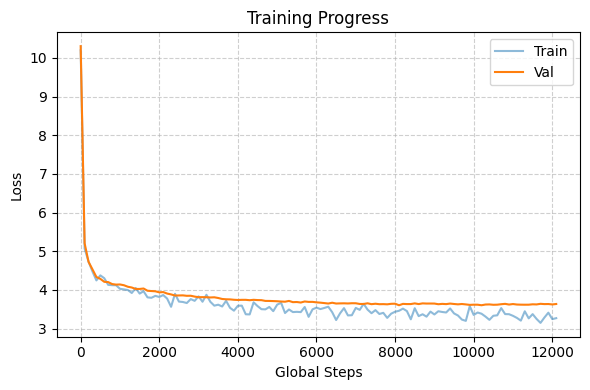

In [ ]:
plot_training_results(train_losses8, val_losses8, 100, title="Training Progress", y_title="Loss")

In [ ]:
all_codes = torch.cat([torch.tensor(train_dataset_prior_4[i][0]) for i in range(len(train_dataset_prior_4))])
counts = torch.bincount(all_codes.flatten().long(), minlength=512)

for code_id, count in enumerate(counts):
    print(f"code {code_id}: {count.item()}")

code 0: 99405
code 1: 115985
code 2: 76360
code 3: 64645
code 4: 39515
code 5: 23080
code 6: 350
code 7: 25
code 8: 486630
code 9: 0
code 10: 120370
code 11: 72335
code 12: 138415
code 13: 50270
code 14: 242480
code 15: 0
code 16: 30375
code 17: 48540
code 18: 145845
code 19: 118210
code 20: 0
code 21: 186925
code 22: 0
code 23: 64975
code 24: 0
code 25: 0
code 26: 176085
code 27: 97895
code 28: 0
code 29: 0
code 30: 299595
code 31: 121405
code 32: 0
code 33: 0
code 34: 0
code 35: 96320
code 36: 0
code 37: 0
code 38: 181500
code 39: 151330
code 40: 283380
code 41: 197020
code 42: 0
code 43: 139860
code 44: 0
code 45: 148150
code 46: 23430
code 47: 125940
code 48: 171740
code 49: 0
code 50: 0
code 51: 0
code 52: 0
code 53: 89890
code 54: 0
code 55: 0
code 56: 0
code 57: 0
code 58: 0
code 59: 0
code 60: 0
code 61: 0
code 62: 0
code 63: 119185
code 64: 0
code 65: 0
code 66: 0
code 67: 0
code 68: 152935
code 69: 0
code 70: 153005
code 71: 0
code 72: 110870
code 73: 125260
code 74: 203115
c

In [ ]:
# Global Code Utilization
print(f"codes used: {(counts > 0).sum().item()} / {512}")
print(f"most common: code {counts.argmax().item()} ({counts.max().item()} times)")

print(f"least used (nonzero): code {counts[counts > 0].argmin().item()} {counts[counts > 0].min().item()} times")

codes used: 274 / 512
most common: code 404 (513600 times)
least used (nonzero): code 7 25 times


In [ ]:
# Per-Image Code Utilization
for i in range(5):
      t = torch.tensor(train_dataset_prior_4[i][0])
      print(t.unique().numel(), "unique of", t.numel())

212 unique of 1024
212 unique of 1024
212 unique of 1024
212 unique of 1024
212 unique of 1024


In [ ]:
p = counts.float()
p = p / p.sum()

entropy = -(p[p > 0] * torch.log2(p[p > 0])).sum()
max_entropy = torch.log2(torch.tensor(len(counts), dtype=torch.float))

print(f"Entropy: {entropy:.3f} bits")
print(f"Maximum: {max_entropy:.3f} bits")
print(f"Normalized: {entropy / max_entropy:.3f}")

Entropy: 7.903 bits
Maximum: 9.000 bits
Normalized: 0.878


In [ ]:
prior_model = Prior(PRIOR_CONFIG_4)
prior_model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/text_to_image_prior_model_flickr8k_3.pt", map_location="cpu"))
prior_model.to(device)

Prior(
  (token_emb_layer): Embedding(50772, 1024)
  (pos_emb_layer): Embedding(32, 1024)
  (null_emb_layer): Embedding(1, 1024)
  (row_emb_layer): Embedding(32, 1024)
  (col_emb_layer): Embedding(33, 1024)
  (dropout_layer): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (mha): MultiHeadAttention(
        (w_query): Linear(in_features=1024, out_features=1024, bias=False)
        (w_key): Linear(in_features=1024, out_features=1024, bias=False)
        (w_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GeLU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )

0 sequence
Input Text Seq: tensor([50257,    64,  7586,   837,  2042,   290,  2330,  3290,   318,   319,
          257, 22007,  1781,   764, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258], device='cuda:0')
Target Text Seq: tensor([   64,  7586,   837,  2042,   290,  2330,  3290,   318,   319,   257,
        22007,  1781,   764, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50259], device='cuda:0')
Predicted Text Seq: tensor([   64,   582,  3290,  2042,  3290,  2330,  3290,   318,  2491,   257,
        40529,  1781,   764,   257,   764,   764,   764,   764,   764,   764,
          764,   764,   764,   764,   764,   764,   764,   764,   764,   764,
          764, 50259], device='cuda:0')
Input Image Seq: tensor([50259, 50697, 50391, 50642, 50409, 50303, 50415, 50452, 50480, 50342,
        50513, 5034

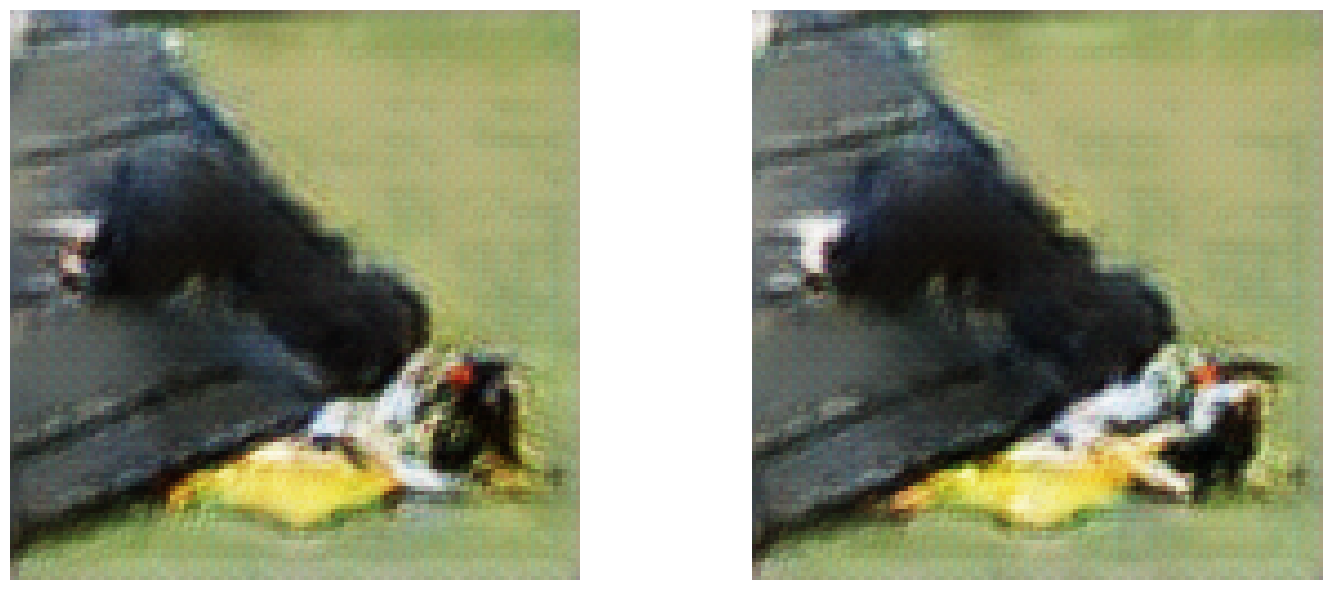

In [ ]:
cfg_weight = 1
with torch.no_grad():
  for x, y in val_loader_prior_4:
    x = {k:v.to(device) for k,v in x.items()}
    y = {k:v.to(device) for k,v in y.items()}
    cond_inp = x
    logits_c = prior_model(cond_inp, training=False)

    uncond_inp = {'text_tokens': None, 'image_tokens': x['image_tokens']}
    logits_u = prior_model(uncond_inp, training=False)
    logits_batch = logits_u + cfg_weight * (logits_c - logits_u)
    logits_batch[:,PRIOR_CONFIG_4['context_length']:,:tokenizer.n_vocab] = torch.tensor(float('-inf'), device=logits_batch.device) # this line ensures that only image tokens are generated

    pred_seq = torch.argmax(logits_batch, dim=-1)
    for i in range(pred_seq.shape[0]):
      print(f"{i} sequence")
      print(f"Input Text Seq: {x['text_tokens'][i]}")
      print(f"Target Text Seq: {y['text_tokens'][i]}")
      # print(f"Predicted Text Seq: {pred_seq[:, :PRIOR_CONFIG_4['context_length']][i]}")
      print(f"Predicted Text Seq: {torch.argmax(logits_c, dim=-1)[:, :PRIOR_CONFIG_4['context_length']][i]}")
      print(f"Input Image Seq: {x['image_tokens'][i][:50]}")
      print(f"Target Image Seq: {y['image_tokens'][i][:50]}")
      print(f"Predicted Image Seq: {pred_seq[:,PRIOR_CONFIG_4['context_length']:][i][:50]}")
      print()
    break

# image reconstruction from autoregressively generated image codes
img_tokens = pred_seq[[4,3],PRIOR_CONFIG_4['context_length']:].reshape(-1, PRIOR_CONFIG_4['grid_size'][0], PRIOR_CONFIG_4['grid_size'][1]) # remove soi token and reshape to 32 * 32 grid expected by vqvae decoder
img_tokens = img_tokens - tokenizer.n_vocab # to get back original image codes
reconst = reconstruct_from_prior(vqvae, img_tokens, device).cpu()

fig, axes = plt.subplots(1, img_tokens.shape[0], figsize=(16, 6))
for i in range(img_tokens.shape[0]):
  axes[i].imshow(torch.permute(reconst[i], (1, 2, 0)))
  axes[i].axis("off")
plt.tight_layout()
plt.show()

above images are not generated by predicting next tokens autoregressively. For each image token, instead of appending predicted token and passing it as input, the original input sequence was fed to the model.

2 cells below is the autoregressive image token prediction and image generation.

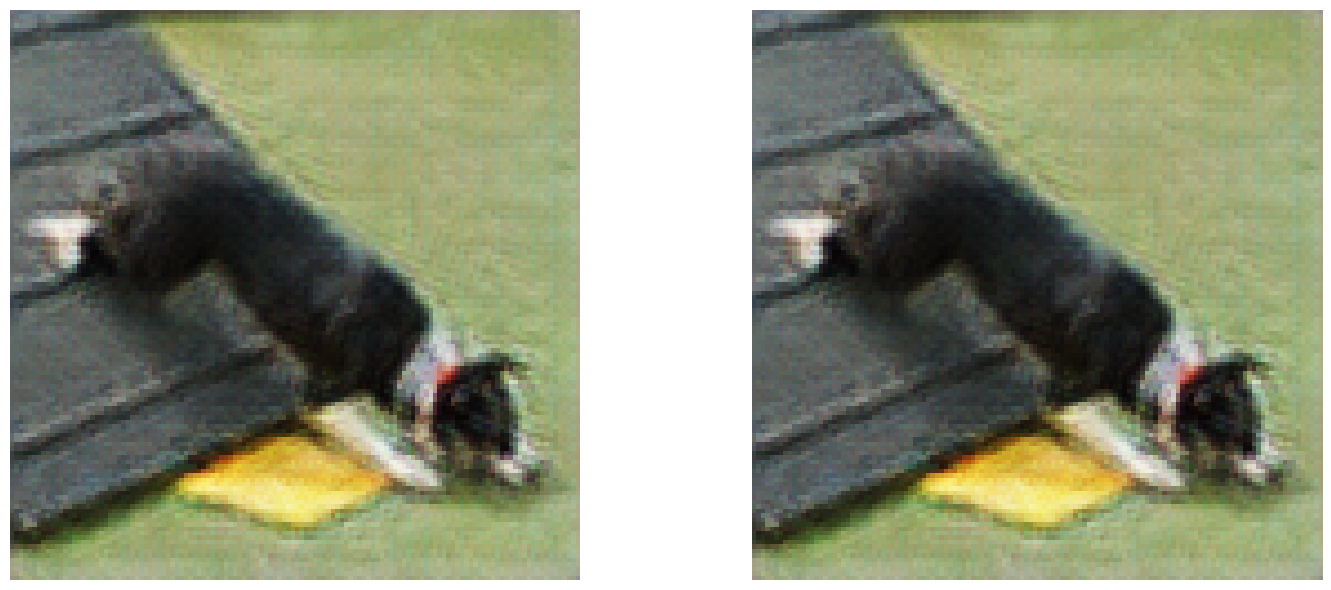

In [ ]:
# image reconstruction from original image codes
orig_img_tokens = torch.cat([x['image_tokens'][[4,3],1:], x['image_tokens'][[4,3],-1].unsqueeze(-1)], dim=-1).reshape(-1, PRIOR_CONFIG_4['grid_size'][0], PRIOR_CONFIG_4['grid_size'][1])
orig_img_tokens = orig_img_tokens - tokenizer.n_vocab # to get back original image codes
reconst_from_orig = reconstruct_from_prior(vqvae, orig_img_tokens, device).cpu()

fig, axes = plt.subplots(1, orig_img_tokens.shape[0], figsize=(16, 6))
for i in range(img_tokens.shape[0]):
  axes[i].imshow(torch.permute(reconst_from_orig[i], (1, 2, 0)))
  axes[i].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
for x, y in val_loader_prior_4:
  for i in range(x['text_tokens'].shape[0]):
    print(tokenizer.decode(x['text_tokens'][i].tolist()))
    print(tokenizer.decode(y['text_tokens'][i].tolist()))
    print()
  break

<|startoftext|>a brown , black and white dog is on a obstacle course .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>
a brown , black and white dog is on a obstacle course .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|startofimage|>

<|startoftext|>a dog climbs down a black ramp<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>
a dog climbs down a black ramp<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|startofimage|>

<|startoftext|>a dog is running down a black and yellow ramp in an obstacle course .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|

tensor([[50259, 50687, 50687, 50333, 50697, 50687, 50687, 50687, 50687, 50333,
         50499, 50697, 50396, 50485, 50420, 50333, 50761, 50420, 50687, 50350,
         50480, 50499, 50568, 50375, 50333, 50513, 50333, 50375, 50672, 50647,
         50454, 50647, 50480, 50762, 50750, 50687, 50458, 50520, 50333, 50418,
         50611, 50611, 50480, 50513, 50627, 50333, 50611, 50687, 50420, 50333],
        [50259, 50642, 50353, 50588, 50687, 50697, 50634, 50611, 50499, 50500,
         50701, 50611, 50687, 50646, 50697, 50734, 50734, 50398, 50701, 50480,
         50375, 50398, 50375, 50398, 50480, 50452, 50438, 50438, 50581, 50452,
         50402, 50669, 50480, 50375, 50396, 50634, 50353, 50341, 50697, 50642,
         50586, 50332, 50642, 50511, 50673, 50734, 50754, 50768, 50750, 50646]],
       device='cuda:0')
136


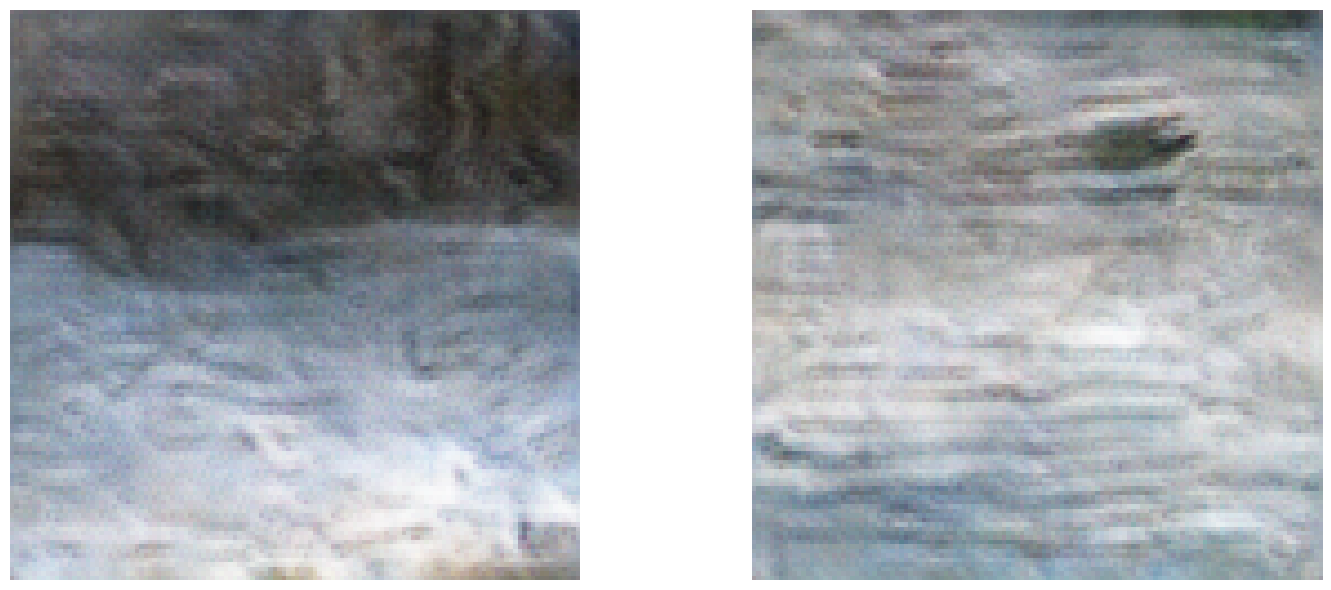

In [ ]:
samples_prompts = [
    'the black and white dog ran down the ramp .',
    'a dog walks down a black ramp .'
]

generate_and_render_sample(
                    prior_model,
                    vqvae,
                    tokenizer,
                    PRIOR_CONFIG_4,
                    cfg_weight=4,
                    text_prompts=samples_prompts,
                    device=device,
                    temperature=2
                )

## **Prior Training - 100 images only**

In [11]:
vqvae = VQVAE4(in_channels=3, out_channels=3, latent_dim=8, hidden=128, k=512, normalize_codebook=False)
vqvae.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_for_image_gen_flickr8k_3.pt", map_location="cpu"))
vqvae.to(device)

VQVAE4(
  (encoder): Encoder4(
    (net): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (2): ResidualBlock4(
        (block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (3): ResidualBlock4(
        (block): Sequential(
          (0): ReLU()
          (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (4): Conv2d(128, 8, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (decoder): Decoder4(
    (net): Sequential(
      (0): Conv2d(8, 128, kernel_size=(1, 1), stride=(1, 1))
      (1): ResidualBlock4(
        (block): Sequential(
          (0): ReLU(

In [12]:
enc = tk.get_encoding("gpt2")

tokenizer = tk.Encoding(
    name="gpt2_custom",
    pat_str=enc._pat_str,
    mergeable_ranks=enc._mergeable_ranks,
    special_tokens={
        **enc._special_tokens,
        "<|startoftext|>": enc.max_token_value + 1,  # new unique ID
        "<|pad|>": enc.max_token_value + 2,  # new unique ID
        "<|startofimage|>": enc.max_token_value + 3  # new unique ID
    }
)

In [13]:
tokenizer.special_tokens_set

{'<|endoftext|>', '<|pad|>', '<|startofimage|>', '<|startoftext|>'}

In [14]:
PAD_ID = tokenizer._special_tokens["<|pad|>"]
SOI_ID = tokenizer._special_tokens["<|startofimage|>"]
BOS_ID = tokenizer._special_tokens["<|startoftext|>"]

In [15]:
tokenizer.n_vocab

50260

In [ ]:
import random

class TokenizedTextImageDataset(Dataset):
    def __init__(self, model, tokenizer, loader, device, num_pairs=100, seed=42):
      pairs = []                      # collect (codes, caption) with ONE caption per image
      model.to(device)
      for x, y in tqdm(loader, desc="Generating codes"):
        x = x.to(device)
        B = x.shape[0]
        with torch.no_grad():
          z_e = model.encoder(x)
          z_q, discrete_codes = model.vq_layer(z_e, training=False)
        discrete_codes = discrete_codes.reshape(B, -1).cpu()   # (B, 1024)

        for b in range(B):
          codes = discrete_codes[b].tolist()
          caption = random.Random(seed + len(pairs)).choice(y[b])  # one caption per image
          pairs.append((codes, caption))

      # shuffle so selection isn't order-biased, then keep only num_pairs distinct images
      random.Random(seed).shuffle(pairs)
      pairs = pairs[:num_pairs]

      self.tokenized_images = [c for c, _ in pairs]
      self.tokenized_text  = [tokenizer.encode(cap.lower()) for _, cap in pairs]

    def __len__(self):
      return len(self.tokenized_images)

    def __getitem__(self, idx):
      return self.tokenized_images[idx], self.tokenized_text[idx]

In [ ]:
train_dataset_prior_4_2 = TokenizedTextImageDataset(vqvae, tokenizer, train_loader_vqvae_4, device)
val_dataset_prior_4_2 = TokenizedTextImageDataset(vqvae, tokenizer, val_loader_vqvae_4, device)

Generating codes: 100%|██████████| 102/102 [00:07<00:00, 13.13it/s]


In [ ]:
torch.save({
    "tokenized_images": train_dataset_prior_4_2.tokenized_images,
    "tokenized_text": train_dataset_prior_4_2.tokenized_text
}, "/content/drive/My Drive/GenAI/Data/train_dataset_prior_4_2.pt")

torch.save({
    "tokenized_images": val_dataset_prior_4_2.tokenized_images,
    "tokenized_text": val_dataset_prior_4_2.tokenized_text
}, "/content/drive/My Drive/GenAI/Data/val_dataset_prior_4_2.pt")

In [16]:
class LoadTokenizedTextImageDataset(Dataset):
    def __init__(self, tokenized_images, tokenized_text):
        self.tokenized_images = tokenized_images
        self.tokenized_text = tokenized_text

    def __len__(self):
        return len(self.tokenized_images)

    def __getitem__(self, idx):
        return self.tokenized_images[idx], self.tokenized_text[idx]

In [17]:
train_data = torch.load("/content/drive/My Drive/GenAI/Data/train_dataset_prior_4_2.pt")

train_dataset_prior_4_2 = LoadTokenizedTextImageDataset(
    train_data["tokenized_images"],
    train_data["tokenized_text"]
)

val_data = torch.load("/content/drive/My Drive/GenAI/Data/val_dataset_prior_4_2.pt")

val_dataset_prior_4_2 = LoadTokenizedTextImageDataset(
    val_data["tokenized_images"],
    val_data["tokenized_text"]
)

In [18]:
len(train_dataset_prior_4_2), len(val_dataset_prior_4_2)

(100, 100)

In [19]:
for name, ds in [("Train", train_dataset_prior_4_2), ("Val", val_dataset_prior_4_2)]:
      lengths = [len(text) for img, text in ds]
      print(f"{name}: 99th pct={np.percentile(lengths, 99):.1f}, "
            f"95th pct={np.percentile(lengths, 95):.1f}, max={max(lengths)}")

Train: 99th pct=25.0, 95th pct=23.0, max=27
Val: 99th pct=22.0, 95th pct=20.0, max=24


In [20]:
def collator(batch, text_vocab_size, max_text_tokens, sot_id=50257, pad_id=50258, soi_id=50259):
  input_text_tokens = []
  input_image_tokens = []
  target_text_tokens = []
  target_image_tokens = []
  for img_tokens, text_tokens in batch:
    text_tokens = [sot_id] + text_tokens
    if len(text_tokens) > max_text_tokens:
      new_text_tokens = text_tokens[:max_text_tokens]
    else:
      new_text_tokens = text_tokens + [pad_id] * (max_text_tokens - len(text_tokens))
    img_tokens = [text_vocab_size+img_code for img_code in img_tokens]
    new_image_tokens = [soi_id] + img_tokens

    input_text_tokens.append(new_text_tokens)
    input_image_tokens.append(new_image_tokens[:-1])

    target_text_tokens.append(new_text_tokens[1:] + [new_image_tokens[0]])
    target_image_tokens.append(new_image_tokens[1:])


  input_text_tokens = torch.tensor(input_text_tokens)
  input_image_tokens = torch.tensor(input_image_tokens)
  target_text_tokens = torch.tensor(target_text_tokens)
  target_image_tokens = torch.tensor(target_image_tokens)
  inputs = {"text_tokens": input_text_tokens, "image_tokens": input_image_tokens}
  targets = {"text_tokens": target_text_tokens, "image_tokens": target_image_tokens}

  return inputs, targets

### Transformer

In [21]:
PRIOR_CONFIG_4_2 = {
    'emb_size':1024, # increased emb size to 1024 from 768 for this exp
    'context_length':32, # trying context length of 32 instead of 256
    'text_vocab_size':tokenizer.n_vocab,
    "codebook_size": 512,
    'num_heads':16, # from 12 to 16 for this exp
    'num_layers':6, # reduced layers from 12 to 6 for this exp
    'drop_rate':0.1,
    'grid_size': (32, 32),
    'row_extension': 33, # for 32 x 32 grid, the row extension of 33 will allow to attend the same column from prev row
    'kernel_size': 11, # kernel size of convolution attention mask
    'cfg_drop': 0.1,
    'qkv_bias': False,
}

PRIOR_CONFIG_4_2["total_vocab_size"] = PRIOR_CONFIG_4_2["text_vocab_size"] + PRIOR_CONFIG_4_2["codebook_size"]

In [22]:
class MultiHeadAttention(nn.Module):
  def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, mask_type, grid_size, row_extension, kernel_size, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)
    # # special raw-col-conv attention mask
    # self.register_buffer(
    #     'mask',
    #     self._create_mask(
    #         mask_type,
    #         context_length,
    #         grid_size=grid_size,
    #         row_extension=row_extension,
    #         kernel_size=kernel_size,
    # ))

    # standard causal mask attention instead of special raw-col-conv attention mask
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length + grid_size[0] * grid_size[1], context_length + grid_size[0] * grid_size[1]), diagonal=1)
    )

  def _create_mask(
      self,
      mask_type,
      text_len,
      grid_size=(32, 32),
      row_extension=32,
      kernel_size=11,
      use_soi=True,
  ):
      H, W = grid_size
      image_len = H * W
      soi_tokens = 1 if use_soi else 0
      total_len = text_len + soi_tokens + image_len
      mask = torch.zeros(
          (total_len, total_len),
          dtype=torch.bool
      )
      # =========================================================
      # TEXT TOKENS
      # Standard causal mask
      # =========================================================
      for i in range(text_len):
          mask[i, : i + 1] = True
      # =========================================================
      # SOI TOKEN
      # =========================================================
      if use_soi:
          soi_idx = text_len
          # SOI attends to all previous text tokens
          mask[soi_idx, : text_len + 1] = True
          image_offset = text_len + 1
      else:
          soi_idx = None
          image_offset = text_len
      # =========================================================
      # IMAGE TOKENS
      # =========================================================
      for img_idx in range(image_len):
          q = image_offset + img_idx
          # -----------------------------------------------------
          # image tokens attend to all text tokens
          # -----------------------------------------------------
          mask[q, :text_len] = True
          # -----------------------------------------------------
          # attend to SOI token
          # -----------------------------------------------------
          if use_soi:
              mask[q, soi_idx] = True
          row = img_idx // W
          col = img_idx % W
          # =====================================================
          # ROW ATTENTION
          # =====================================================
          if mask_type == "row":
              start = max(0, img_idx - row_extension)
              for prev in range(start, img_idx + 1):
                  mask[q, image_offset + prev] = True
          # =====================================================
          # COLUMN ATTENTION
          # =====================================================
          elif mask_type == "column":
              for prev in range(img_idx + 1):
                  prev_row = prev // W
                  prev_col = prev % W
                  same_col = (prev_col == col)
                  within_extent = (
                      row - prev_row
                  ) <= row_extension
                  if same_col and within_extent:
                      mask[q, image_offset + prev] = True
          # =====================================================
          # CONVOLUTION ATTENTION
          # WITH WRAPAROUND BEHAVIOR
          # =====================================================
          elif mask_type == "convolution":
              radius = kernel_size // 2
              for prev in range(img_idx + 1):
                  prev_row = prev // W
                  prev_col = prev % W
                  dr = row - prev_row
                  # horizontal wraparound distance
                  dc = min(
                      abs(col - prev_col),
                      W - abs(col - prev_col)
                  )
                  inside_kernel = (
                      abs(dr) <= radius
                      and dc <= radius
                  )
                  if inside_kernel:
                      mask[q, image_offset + prev] = True
          else:
              raise ValueError(
                  f"Unknown mask type: {mask_type}"
              )
      return ~mask

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    attention_scores = queries @ keys.transpose(2,3)
    attention_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

In [23]:
class LayerNorm(nn.Module):
  def __init__(self, emb_size):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_size))
    self.shift = nn.Parameter(torch.zeros(emb_size))

  def forward(self, x):
    mean = x.mean(keepdim=True, dim=-1)
    variance = x.var(keepdim=True, dim=-1, unbiased=False)
    norm_x = (x - mean)/torch.sqrt(variance + self.eps)
    return self.scale * norm_x + self.shift

In [24]:
class GeLU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
    ))

In [25]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_size'], 4 * cfg['emb_size']),
        GeLU(),
        nn.Linear(4 * cfg['emb_size'], cfg['emb_size'])
    )

  def forward(self, x):
    return self.layers(x)

In [26]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg, mask_type):
    super().__init__()
    self.mha = MultiHeadAttention(cfg['emb_size'], cfg['emb_size'], cfg['context_length'], cfg['drop_rate'], cfg['num_heads'], mask_type, cfg['grid_size'], cfg['row_extension'], cfg['kernel_size'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.ffn = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [27]:
class Prior(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['total_vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.null_emb_layer = nn.Embedding(1, cfg['emb_size'])
    self.row_emb_layer = nn.Embedding(cfg['grid_size'][0], cfg['emb_size'])
    self.col_emb_layer = nn.Embedding(cfg['grid_size'][1] + 1, cfg['emb_size']) # the 0th col_emb is for startofimage token only and not for any of the image tokens belonging to the zeroth column in 2d view
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg, self._mask_type(i, cfg['num_layers'])) for i in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['total_vocab_size'], bias=False)
    self.num_rows = cfg['grid_size'][0]
    self.num_cols = cfg['grid_size'][1]
    self.context_length = cfg['context_length']
    self.cfg_drop = cfg['cfg_drop']

  def _mask_type(self, i, num_layers):
    if i==num_layers-1:
      return 'convolution'
    elif (i-1)%4==0:
      return 'column'
    else:
      return 'row'

  def forward(self, input, training=False):
    text_tokens = input.get('text_tokens', None) # text_tokens will be None for unconditional inference
    image_tokens = input.get('image_tokens', None) # soi token belongs to image_tokens seq
    batch_size, num_img_tokens = image_tokens.shape
    null_emb = self.null_emb_layer(torch.tensor(0).to(image_tokens.device))
    if text_tokens is None: # during unconditional inference
      text_token_emb = null_emb.unsqueeze(0).unsqueeze(0).expand(batch_size, self.context_length, -1)
    else:
      text_token_emb = self.token_emb_layer(text_tokens)
    _, num_text_tokens, _ = text_token_emb.shape
    pos_emb = self.pos_emb_layer(
        torch.arange(num_text_tokens, device=image_tokens.device)
    )
    if training:
      drop_ind = torch.rand(batch_size) < self.cfg_drop
      text_token_emb[drop_ind] = null_emb.unsqueeze(0).expand(num_text_tokens, -1)
    text_emb = text_token_emb + pos_emb
    image_token_emb = self.token_emb_layer(image_tokens)
    # row_emb = self.row_emb_layer(
    #     torch.arange((num_img_tokens-1)//self.num_rows, device=image_tokens.device)
    # )
    # cols_to_use = min(num_img_tokens-1, self.num_cols) + 1 # for +1 for soi token
    # col_emb = self.col_emb_layer(
    #     torch.arange(cols_to_use, device=image_tokens.device)
    # )
    # image_token_emb[0] = image_token_emb[0] + row_emb[0] + col_emb[0] # soi separately
    # row_emb_repeat = torch.repeat_interleave(row_emb, self.num_cols, dim=0)[:num_img_tokens-1] # excluded soi since it is already done
    # col_emb_repeat = torch.tile(col_emb[1:], ((num_img_tokens-1) // (cols_to_use - 1) + 1,))[:num_img_tokens-1] # excluded soi since it is already done
    # image_token_emb[1:] = image_token_emb[1:] + row_emb_repeat + col_emb_repeat
    # for each image token (excluding SOI), compute which row it belongs to
    image_token_emb[:,0] = image_token_emb[:,0] + self.row_emb_layer(torch.tensor(0, device=image_tokens.device)) + self.col_emb_layer(torch.tensor(0, device=image_tokens.device)) # soi separately
    img_indices = torch.arange(num_img_tokens - 1, device=image_tokens.device)
    row_indices = img_indices // self.num_cols   # shape (num_img_tokens-1,)
    col_indices = img_indices % self.num_cols    # shape (num_img_tokens-1,)
    row_emb = self.row_emb_layer(row_indices)   # (num_img_tokens-1, emb_size)
    col_emb = self.col_emb_layer(col_indices + 1)  # +1 to skip the SOI col slot
    image_token_emb[:,1:] = image_token_emb[:,1:] + row_emb + col_emb
    x = torch.cat((text_emb, image_token_emb), dim=1)
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits

### Training

In [28]:
def ce_batch_loss_calc(input_batch, target_batch, model, device, cfg, training=False):
  input_batch = {k:v.to(device) for k,v in input_batch.items()}
  target_batch = {k:v.to(device) for k,v in target_batch.items()}
  logits_batch = model(input_batch, training=training)
  # loss_text = torch.nn.functional.cross_entropy(logits_batch[:, :cfg['context_length'], :].flatten(0, 1), target_batch['text_tokens'].flatten()) / cfg['context_length'] # dividing to normalize wrt text token occurence
  # loss_image = torch.nn.functional.cross_entropy(logits_batch[:, cfg['context_length']:, :].flatten(0, 1), target_batch['image_tokens'].flatten()) / (cfg['grid_size'][0] * cfg['grid_size'][1]) # dividing to normalize wrt image token occurence
  # correct implementation
  loss_text = torch.nn.functional.cross_entropy(logits_batch[:, :cfg['context_length'], :].flatten(0, 1), target_batch['text_tokens'].flatten(), ignore_index=PAD_ID, reduction='mean')
  loss_image = torch.nn.functional.cross_entropy(logits_batch[:, cfg['context_length']:, :].flatten(0, 1), target_batch['image_tokens'].flatten(), reduction='mean')
  loss = 0.125 * loss_text + 0.875 * loss_image

  return loss

In [29]:
def calc_loss_dataloader(loader, model, device, cfg, num_batches=None):
  total_loss = 0
  if len(loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(loader)
  elif num_batches < 0:
    num_batches = float('nan')
  else:
    num_batches = min(num_batches, len(loader))

  for i, (x, y) in enumerate(loader):
    if i < num_batches:
      loss = ce_batch_loss_calc(x, y, model, device, cfg, training=False)
      total_loss += loss.item()
    else:
      break

  return total_loss/num_batches

In [30]:
def evaluate_prior(model, train_loader, val_loader, device, cfg, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_dataloader(train_loader, model, device, cfg, eval_iter)
    val_loss = calc_loss_dataloader(val_loader, model, device, cfg, eval_iter)
  model.train()

  return train_loss, val_loss

In [31]:
def generate(model, tokenizer, inputs, max_gen_tokens, cfg_weight, temperature=0.0, top_k=None, eos_id=None): # cfg_weight -> classifier-free guidance
  B, N = inputs['text_tokens'].shape
  finished = torch.zeros(B, dtype=torch.bool, device=inputs['text_tokens'].device)
  for i in range(max_gen_tokens):
    with torch.no_grad():
      cond_inp = inputs
      logits_c = model(cond_inp, training=False)[:, -1, :]

      uncond_inp = {'text_tokens': None, 'image_tokens': inputs['image_tokens']}
      logits_u = model(uncond_inp, training=False)[:, -1, :]
    logits = logits_u + cfg_weight * (logits_c - logits_u) # classifier free guidance for boosting logits for tokens which are caption or condition relevant

    logits[:,:tokenizer.n_vocab] = torch.tensor(float('-inf'), device=logits.device) # this line ensures that only image tokens are generated

    if top_k is not None:
      top_logits, top_idx = torch.topk(logits, top_k)
      logits = torch.where(
          condition=logits<top_logits[:,-1, None],
          input=torch.tensor(float('-inf'), device=logits.device),
          other=logits
      )

    if temperature > 0:
      scaled_logits = logits / temperature
      probs = torch.softmax(scaled_logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)

    if eos_id is not None:
        finished |= (idx_next.squeeze(-1) == eos_id)
        idx_next[finished] = eos_id

    inputs['image_tokens'] = torch.cat((inputs['image_tokens'], idx_next), dim=1)

    if finished.all():
        break

  return inputs['image_tokens']

In [32]:
def reconstruct_from_prior(vqvae, img_tokens, device):
  vqvae.eval()
  with torch.no_grad():
    img_tokens = img_tokens.to(device) # (B, H, W)
    codebook_latents = vqvae.vq_layer.codebook[img_tokens].permute(0, 3, 1, 2) # (B, emb_dim, H, W)
    reconst = vqvae.sigmoid(vqvae.decoder(codebook_latents))
  return reconst

In [33]:
def tokenize_text(text, tokenizer, max_text_tokens):
  tokens = tokenizer.encode(text.lower())
  tokens = [BOS_ID] + tokens
  if len(tokens) > max_text_tokens:
    new_tokens = tokens[:max_text_tokens]
  else:
    new_tokens = tokens + [PAD_ID] * (max_text_tokens - len(tokens))
  return new_tokens

In [38]:
def generate_and_render_sample(model, vqvae, tokenizer, cfg, cfg_weight, text_prompts, device, temperature=0.7):
  model.eval()
  input_text_tokens = []
  for text in text_prompts:
    text_tokens = tokenize_text(text, tokenizer, cfg['context_length'])
    input_text_tokens.append(text_tokens)
  input_image_tokens = [[SOI_ID] for i in range(len(text_prompts))]
  inputs = {
      'text_tokens': torch.tensor(input_text_tokens, device=device),
      'image_tokens': torch.tensor(input_image_tokens, device=device)
  }
  with torch.no_grad():
    op_tokens = generate(
        model,
        inputs=inputs,
        tokenizer=tokenizer,
        max_gen_tokens=1024,
        cfg_weight=cfg_weight,
        temperature=temperature,
        top_k=25
    )
  print(op_tokens[:,:50])
  print(op_tokens.unique().numel())
  img_tokens = op_tokens[:,1:].reshape(-1, cfg['grid_size'][0], cfg['grid_size'][1]) # remove soi token and reshape to 32 * 32 grid expected by vqvae decoder
  img_tokens = img_tokens - tokenizer.n_vocab # to get back original image codes
  reconst = reconstruct_from_prior(vqvae, img_tokens, device).cpu()

  fig, axes = plt.subplots(1, len(text_prompts), figsize=(16, 6))
  if len(text_prompts) == 1:
    axes = [axes]
  for i in range(len(text_prompts)):
    axes[i].imshow(torch.permute(reconst[i], (1, 2, 0)))
    axes[i].axis("off")
    wrapped_caption = "\n".join(textwrap.wrap(text_prompts[i], width=30))
    axes[i].set_title(wrapped_caption, fontsize=9)
  plt.tight_layout()
  plt.show()

In [35]:
import time

def train_model_simple(
    model,
    vqvae,
    cfg,
    train_loader,
    val_loader,
    device,
    optimizer,
    tokenizer,
    epochs,
    eval_freq,
    eval_iter,
    text_prompts,
    cfg_weight
):
    train_loss_arr, val_loss_arr, track_tokens_seen, grad_norms_arr = [], [], [], []
    global_step, tokens_seen = -1, 0

    total_steps = epochs * len(train_loader)
    print(f"Total steps: {total_steps}")

    t_start = time.time()

    for epoch in range(epochs):
        model.train()

        for x, y in train_loader:
            optimizer.zero_grad()

            train_loss = ce_batch_loss_calc(
                x, y, model, device, cfg, training=True
            )

            train_loss.backward()

            # global grad norm
            total_norm = 0.0

            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.detach().data.norm(2)
                    total_norm += param_norm.item() ** 2

            total_norm = total_norm ** 0.5
            grad_norms_arr.append(total_norm)

            optimizer.step()

            tokens_seen += (
                x['text_tokens'].numel()
                + x['image_tokens'].numel()
            )

            global_step += 1

            if global_step % eval_freq == 0:

                elapsed = time.time() - t_start
                steps_done = global_step + 1
                steps_left = total_steps - steps_done

                eta_minutes = (
                    (elapsed / steps_done) * steps_left
                ) / 60

                train_loss, val_loss = evaluate_prior(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    cfg,
                    eval_iter
                )

                train_loss_arr.append(train_loss)
                val_loss_arr.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"Epoch: {epoch:3d} \t Step: {global_step:5d}")
                print(f"\tTrain Loss: {train_loss:.4f}")
                print(f"\tVal Loss:   {val_loss:.4f}")
                print(f"\tTokens Seen: {tokens_seen}")
                print(f"\tETA: {eta_minutes:.2f} minutes")

            if global_step % (eval_freq * 5) == 0: # if eval_freq=100 then generation will happen every 5000 steps
                generate_and_render_sample(
                    model,
                    vqvae,
                    tokenizer,
                    cfg,
                    cfg_weight,
                    text_prompts,
                    device
                )
                model.train()

    total_time = time.time() - t_start
    print(f"Total training time: {total_time:.1f}s")

    return train_loss_arr, val_loss_arr, track_tokens_seen, grad_norms_arr

In [36]:
prior_collate_fn = partial(collator, text_vocab_size=tokenizer.n_vocab, max_text_tokens=PRIOR_CONFIG_4_2['context_length'])

train_loader_prior_4_2 = DataLoader(train_dataset_prior_4_2, batch_size=8, shuffle=True, num_workers=0, collate_fn=prior_collate_fn)
val_loader_prior_4_2 = DataLoader(val_dataset_prior_4_2, batch_size=8, shuffle=False, num_workers=0, collate_fn=prior_collate_fn)

In [ ]:
torch.manual_seed(123)
model9 = Prior(PRIOR_CONFIG_4_2)
model9.to(device)
optimizer9 = torch.optim.AdamW(model9.parameters(), lr=0.0004, weight_decay=0.1)
text_prompts = [
                  'a black dog in the middle of running or leaping .',
                  'two dirt bike riders in midair .'
                  # 'a cat that is standing on a toilet and next to a sink'
                  # 'some people are flying kites and one male has a red tie on',
                  # 'a work crew repairs a stop in the town.'
                ]
train_losses9, val_losses9, tokens_seen9, grad_norms_arr9 = train_model_simple(model9, vqvae, PRIOR_CONFIG_4_2, train_loader_prior_4_2, val_loader_prior_4_2, device, optimizer9, tokenizer, epochs=50, eval_freq=100, eval_iter=5, text_prompts=text_prompts, cfg_weight=4)

In [ ]:
torch.save(model9.state_dict(), '/content/drive/My Drive/GenAI/Data/text_to_image_prior_model_flickr8k_4.pt')

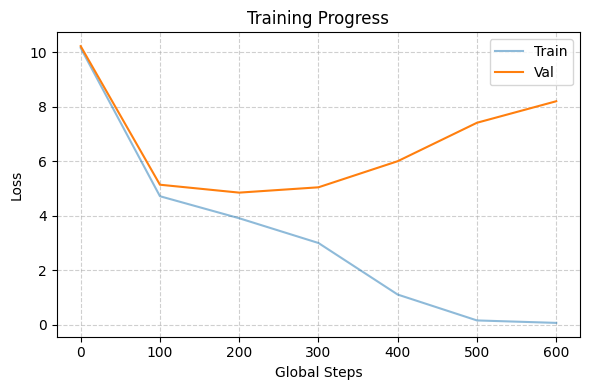

In [ ]:
plot_training_results(train_losses9, val_losses9, 100, title="Training Progress", y_title="Loss")

In [ ]:
all_codes = torch.cat([torch.tensor(train_dataset_prior_4_2[i][0]) for i in range(len(train_dataset_prior_4_2))])
counts = torch.bincount(all_codes.flatten().long(), minlength=512)

for code_id, count in enumerate(counts):
    print(f"code {code_id}: {count.item()}")

code 0: 380
code 1: 363
code 2: 194
code 3: 182
code 4: 118
code 5: 99
code 6: 1
code 7: 0
code 8: 1440
code 9: 0
code 10: 460
code 11: 206
code 12: 450
code 13: 130
code 14: 760
code 15: 0
code 16: 122
code 17: 166
code 18: 473
code 19: 393
code 20: 0
code 21: 568
code 22: 0
code 23: 264
code 24: 0
code 25: 0
code 26: 542
code 27: 320
code 28: 0
code 29: 0
code 30: 904
code 31: 427
code 32: 0
code 33: 0
code 34: 0
code 35: 355
code 36: 0
code 37: 0
code 38: 596
code 39: 468
code 40: 931
code 41: 744
code 42: 0
code 43: 478
code 44: 0
code 45: 528
code 46: 46
code 47: 565
code 48: 430
code 49: 0
code 50: 0
code 51: 0
code 52: 0
code 53: 409
code 54: 0
code 55: 0
code 56: 0
code 57: 0
code 58: 0
code 59: 0
code 60: 0
code 61: 0
code 62: 0
code 63: 470
code 64: 0
code 65: 0
code 66: 0
code 67: 0
code 68: 532
code 69: 0
code 70: 410
code 71: 0
code 72: 434
code 73: 311
code 74: 519
code 75: 325
code 76: 234
code 77: 585
code 78: 0
code 79: 405
code 80: 0
code 81: 678
code 82: 160
code 83:

In [ ]:
# Global Code Utilization
print(f"codes used: {(counts > 0).sum().item()} / {512}")
print(f"most common: code {counts.argmax().item()} ({counts.max().item()} times)")

print(f"least used (nonzero): code {counts[counts > 0].argmin().item()} {counts[counts > 0].min().item()} times")

codes used: 273 / 512
most common: code 8 (1440 times)
least used (nonzero): code 6 1 times


In [ ]:
# Per-Image Code Utilization
for i in range(5):
      t = torch.tensor(train_dataset_prior_4_2[i][0])
      print(t.unique().numel(), "unique of", t.numel())

160 unique of 1024
196 unique of 1024
219 unique of 1024
225 unique of 1024
203 unique of 1024


In [ ]:
p = counts.float()
p = p / p.sum()

entropy = -(p[p > 0] * torch.log2(p[p > 0])).sum()
max_entropy = torch.log2(torch.tensor(len(counts), dtype=torch.float))

print(f"Entropy: {entropy:.3f} bits")
print(f"Maximum: {max_entropy:.3f} bits")
print(f"Normalized: {entropy / max_entropy:.3f}")

Entropy: 7.882 bits
Maximum: 9.000 bits
Normalized: 0.876


In [40]:
prior_model = Prior(PRIOR_CONFIG_4_2)
prior_model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/text_to_image_prior_model_flickr8k_4.pt", map_location="cpu"))
prior_model.to(device)

Prior(
  (token_emb_layer): Embedding(50772, 1024)
  (pos_emb_layer): Embedding(32, 1024)
  (null_emb_layer): Embedding(1, 1024)
  (row_emb_layer): Embedding(32, 1024)
  (col_emb_layer): Embedding(33, 1024)
  (dropout_layer): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (mha): MultiHeadAttention(
        (w_query): Linear(in_features=1024, out_features=1024, bias=False)
        (w_key): Linear(in_features=1024, out_features=1024, bias=False)
        (w_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GeLU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )

0 sequence
Input Text Seq: tensor([50257,    64,  2576,  6296,   319,   734,  7888, 17259,   290, 12566,
        45019,  1973,   257,  7850,   764, 50258, 50258, 50258, 50258, 50258,
        50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258], device='cuda:0')
Target Text Seq: tensor([   64,  2576,  6296,   319,   734,  7888, 17259,   290, 12566, 45019,
         1973,   257,  7850,   764, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258, 50258,
        50258, 50259], device='cuda:0')
Predicted Text Seq: tensor([   64,  2415,   318,   319,   734,  7888, 17259,   290, 12566, 45019,
         1973,   257,  7850,   764, 13538,  1204, 50259, 50259,  7331, 50259,
         6877, 50259, 50259, 50259, 50259, 50259, 50259, 50259, 50259, 50259,
        50259, 50259], device='cuda:0')
Input Image Seq: tensor([50259, 50268, 50718, 50718, 50384, 50384, 50268, 50268, 50268, 50268,
        50268, 5026

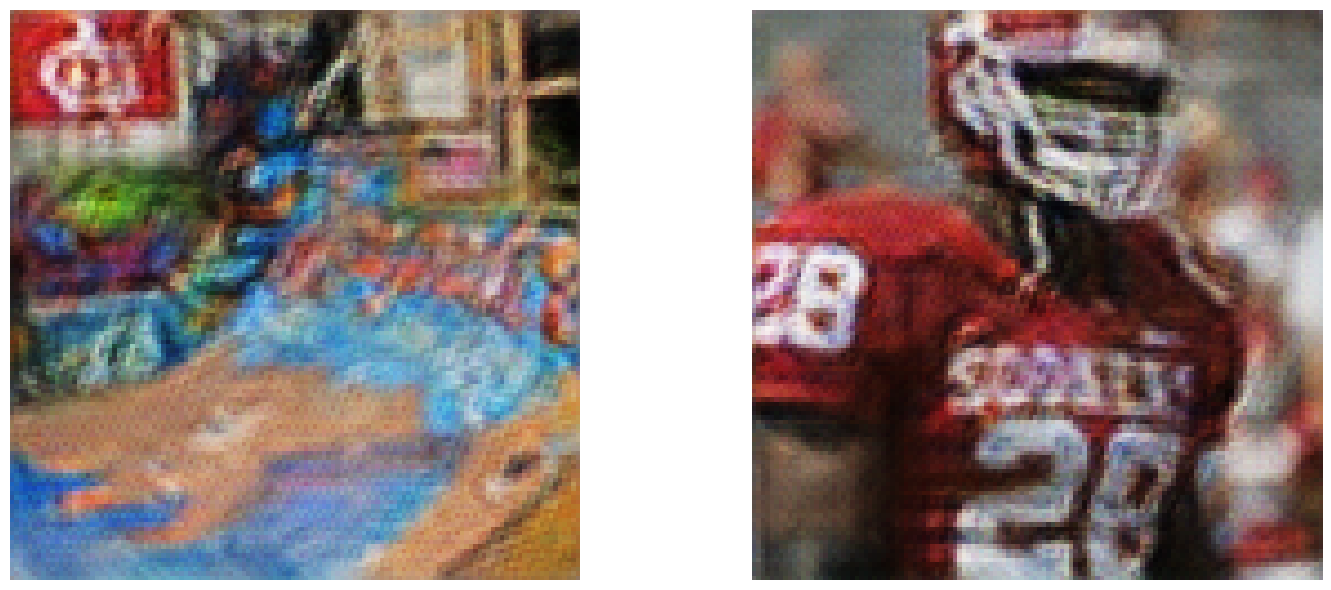

In [ ]:
# generating teacher-forced tokens from training set in this experiment
cfg_weight = 1
with torch.no_grad():
  for x, y in train_loader_prior_4_2:
    x = {k:v.to(device) for k,v in x.items()}
    y = {k:v.to(device) for k,v in y.items()}
    cond_inp = x
    logits_c = prior_model(cond_inp, training=False)

    uncond_inp = {'text_tokens': None, 'image_tokens': x['image_tokens']}
    logits_u = prior_model(uncond_inp, training=False)
    logits_batch = logits_u + cfg_weight * (logits_c - logits_u)
    logits_batch[:,PRIOR_CONFIG_4_2['context_length']:,:tokenizer.n_vocab] = torch.tensor(float('-inf'), device=logits_batch.device) # this line ensures that only image tokens are generated

    pred_seq = torch.argmax(logits_batch, dim=-1)
    for i in range(pred_seq.shape[0]):
      print(f"{i} sequence")
      print(f"Input Text Seq: {x['text_tokens'][i]}")
      print(f"Target Text Seq: {y['text_tokens'][i]}")
      # print(f"Predicted Text Seq: {pred_seq[:, :PRIOR_CONFIG_4_2['context_length']][i]}")
      print(f"Predicted Text Seq: {torch.argmax(logits_c, dim=-1)[:, :PRIOR_CONFIG_4_2['context_length']][i]}")
      print(f"Input Image Seq: {x['image_tokens'][i][:50]}")
      print(f"Target Image Seq: {y['image_tokens'][i][:50]}")
      print(f"Predicted Image Seq: {pred_seq[:,PRIOR_CONFIG_4_2['context_length']:][i][:50]}")
      print()
    break

# image reconstruction from autoregressively generated image codes
img_tokens = pred_seq[[7,6],PRIOR_CONFIG_4_2['context_length']:].reshape(-1, PRIOR_CONFIG_4_2['grid_size'][0], PRIOR_CONFIG_4_2['grid_size'][1]) # remove soi token and reshape to 32 * 32 grid expected by vqvae decoder
img_tokens = img_tokens - tokenizer.n_vocab # to get back original image codes
reconst = reconstruct_from_prior(vqvae, img_tokens, device).cpu()

fig, axes = plt.subplots(1, img_tokens.shape[0], figsize=(16, 6))
for i in range(img_tokens.shape[0]):
  axes[i].imshow(torch.permute(reconst[i], (1, 2, 0)))
  axes[i].axis("off")
plt.tight_layout()
plt.show()

above images are not generated by predicting next tokens autoregressively. For each image token, instead of appending predicted token and passing it as input, the original input sequence was fed to the model.

2 cells below is the autoregressive image token prediction and image generation.

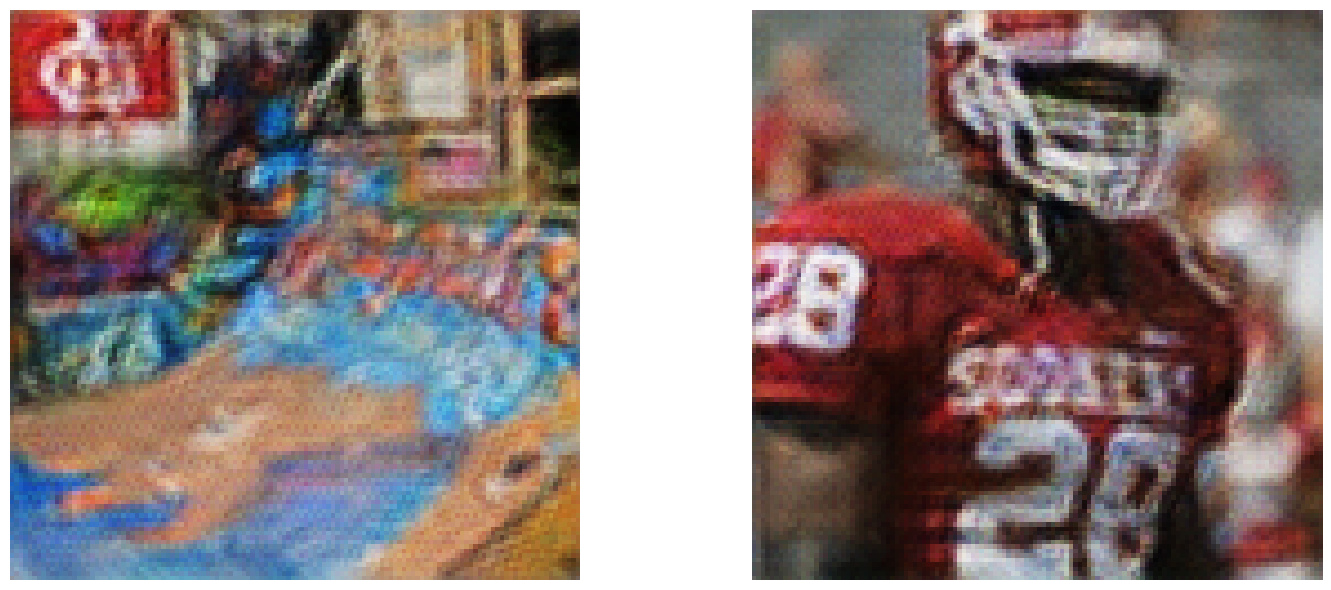

In [ ]:
# image reconstruction from original image codes
orig_img_tokens = torch.cat([x['image_tokens'][[7,6],1:], x['image_tokens'][[4,3],-1].unsqueeze(-1)], dim=-1).reshape(-1, PRIOR_CONFIG_4_2['grid_size'][0], PRIOR_CONFIG_4_2['grid_size'][1])
orig_img_tokens = orig_img_tokens - tokenizer.n_vocab # to get back original image codes
reconst_from_orig = reconstruct_from_prior(vqvae, orig_img_tokens, device).cpu()

fig, axes = plt.subplots(1, orig_img_tokens.shape[0], figsize=(16, 6))
for i in range(img_tokens.shape[0]):
  axes[i].imshow(torch.permute(reconst_from_orig[i], (1, 2, 0)))
  axes[i].axis("off")
plt.tight_layout()
plt.show()

In [45]:
for x, y in train_loader_prior_4_2:
  for i in range(x['text_tokens'].shape[0]):
    print(tokenizer.decode(x['text_tokens'][i].tolist()))
    print(tokenizer.decode(y['text_tokens'][i].tolist()))
    print()
  break

<|startoftext|>three young boys playing hear no evil , speak no evil , see no evil<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>
three young boys playing hear no evil , speak no evil , see no evil<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|startofimage|>

<|startoftext|>a black dog is running through the snow .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|>
a black dog is running through the snow .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|startofimage|>

<|startoftext|>the man wearing a hat and headset is taking a photo .<|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pad|><|pa

tensor([[50259, 50402, 50635, 50303, 50635, 50544, 50273, 50544, 50581, 50742,
         50402, 50415, 50303, 50303, 50303, 50443, 50303, 50413, 50635, 50303,
         50303, 50611, 50299, 50303, 50643, 50643, 50716, 50716, 50737, 50643,
         50643, 50716, 50769, 50307, 50339, 50398, 50581, 50303, 50413, 50684,
         50544, 50635, 50544, 50443, 50748, 50581, 50711, 50411, 50413, 50299],
        [50259, 50390, 50515, 50749, 50515, 50515, 50515, 50390, 50328, 50390,
         50328, 50390, 50390, 50515, 50328, 50313, 50584, 50390, 50515, 50515,
         50313, 50584, 50390, 50515, 50390, 50390, 50390, 50584, 50390, 50584,
         50584, 50295, 50584, 50390, 50344, 50313, 50515, 50463, 50515, 50656,
         50290, 50313, 50584, 50313, 50584, 50515, 50515, 50595, 50515, 50733],
        [50259, 50664, 50664, 50664, 50298, 50664, 50298, 50300, 50382, 50300,
         50664, 50664, 50298, 50274, 50498, 50664, 50382, 50498, 50382, 50382,
         50300, 50382, 50290, 50300, 50300, 50382,

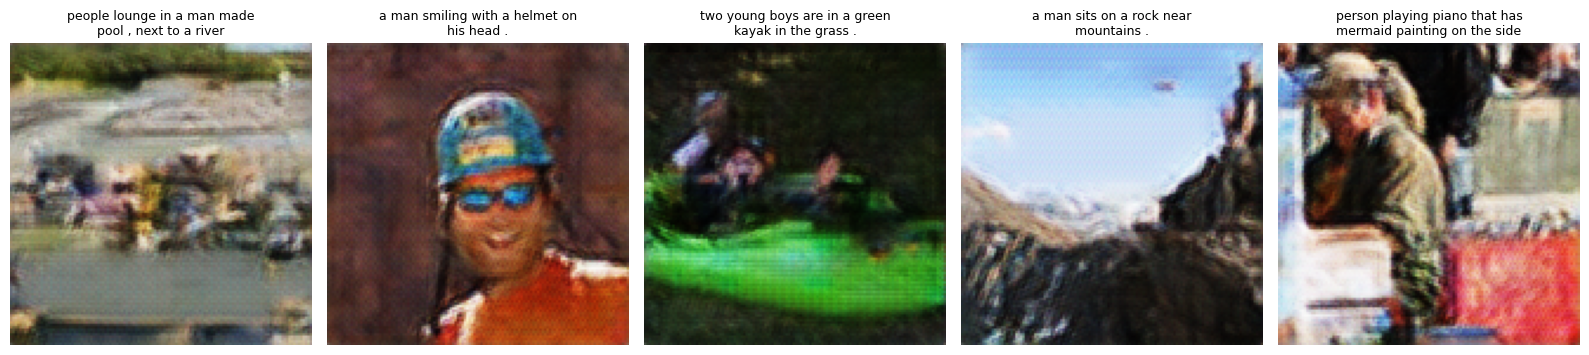

In [46]:
# autoregressive img token generation from training set captions
samples_prompts = [
    'people lounge in a man made pool , next to a river',
    'a man smiling with a helmet on his head .',
    'two young boys are in a green kayak in the grass .',
    'a man sits on a rock near mountains .',
    'person playing piano that has mermaid painting on the side'
]

generate_and_render_sample(
                    prior_model,
                    vqvae,
                    tokenizer,
                    PRIOR_CONFIG_4_2,
                    cfg_weight=4,
                    text_prompts=samples_prompts,
                    device=device,
                    temperature=0
                )

tensor([[50259, 50664, 50664, 50664, 50298, 50664, 50298, 50300, 50382, 50300,
         50664, 50664, 50298, 50274, 50498, 50664, 50382, 50498, 50382, 50382,
         50300, 50382, 50290, 50300, 50300, 50382, 50664, 50300, 50382, 50300,
         50382, 50300, 50533, 50415, 50452, 50382, 50420, 50290, 50452, 50290,
         50300, 50382, 50669, 50686, 50337, 50611, 50513, 50761, 50456, 50339]],
       device='cuda:0')
140


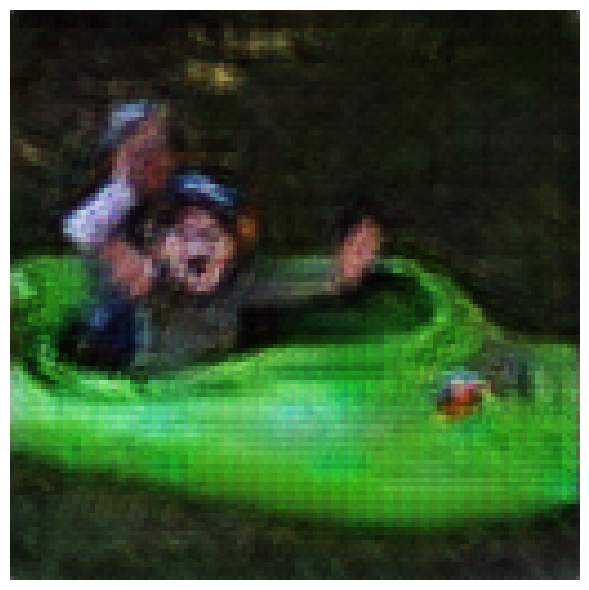

In [ ]:
samples_prompts = [
    'two young boys are in a green kayak in the grass .'
]

generate_and_render_sample(
                    prior_model,
                    vqvae,
                    tokenizer,
                    PRIOR_CONFIG_4_2,
                    cfg_weight=1,
                    text_prompts=samples_prompts,
                    device=device,
                    temperature=0
                )